# Constructing the eICU Analytic Dataset

This notebook creates the analytic dataset required for ICU patient clustering.

The unit of analysis is one ICU stay, identified by `patientunitstayid`.

The notebook :
- Defines the eligible study population
- Extracts $29$ clustering variables
- Uses measurements from the first $24$ hours
- Summarizes repeated measurements
- Merges all variables into one table
- Identifies implausible values
- Examines distributions and missingness
- Applies an initial missing-data strategy
- Transforms highly skewed variables when appropriate
- Standardizes the variables for KMeans

### Import Required Libraries

In [1]:
from pathlib import Path
from collections import Counter
import re
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler


# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 150)

# Plot settings
sns.set_theme(style="whitegrid")

# Hide unimportant warnings
warnings.filterwarnings("ignore")

print("All required libraries were imported successfully.")

All required libraries were imported successfully.


#### Explanation :

This cell imports the libraries used for loading data, processing large eICU tables, creating plots, imputing missing values and standardizing variables.

### Define the Project Folder Structure

In [2]:
CURRENT_DIR = Path.cwd().resolve()

if (CURRENT_DIR / "data").exists() and (CURRENT_DIR / "notebooks").exists():
    ROOT_DIR = CURRENT_DIR

elif CURRENT_DIR.name == "module_2" and CURRENT_DIR.parent.name == "notebooks":
    ROOT_DIR = CURRENT_DIR.parents[1]

elif CURRENT_DIR.name == "notebooks":
    ROOT_DIR = CURRENT_DIR.parent

else:
    raise FileNotFoundError(
        "The project root folder could not be found.\n"
        "Run this notebook from the project root, notebooks folder, "
        "or notebooks/module_2 folder."
    )


# Input folder
PROCESSED_DIR = ROOT_DIR / "data" / "processed"

# Final datasets used by later tasks
DATA_DIR = ROOT_DIR / "data"

# Supporting Task 5 result tables
RESULTS_DIR = ROOT_DIR / "results" / "analytic_dataset"

# Task 5 plots
PLOTS_DIR = ROOT_DIR / "plots" / "analytic_dataset"

DISTRIBUTION_DIR = PLOTS_DIR / "distributions"
MISSINGNESS_DIR = PLOTS_DIR / "missingness"
OUTLIER_DIR = PLOTS_DIR / "outliers"
CORRELATION_DIR = PLOTS_DIR / "correlation"
TRANSFORMATION_DIR = PLOTS_DIR / "transformations"


# Create output folders when they do not already exist
folders_to_create = [
    DATA_DIR,
    RESULTS_DIR,
    PLOTS_DIR,
    DISTRIBUTION_DIR,
    MISSINGNESS_DIR,
    OUTLIER_DIR,
    CORRELATION_DIR,
    TRANSFORMATION_DIR,
]

for folder in folders_to_create:
    folder.mkdir(parents=True, exist_ok=True)


print("=" * 100)
print("PROJECT FOLDER PATHS")
print("=" * 100)
print(f"Current folder       : {CURRENT_DIR}")
print(f"Project root         : {ROOT_DIR}")
print(f"Processed data       : {PROCESSED_DIR}")
print(f"Final datasets       : {DATA_DIR}")
print(f"Task 5 results       : {RESULTS_DIR}")
print(f"Task 5 plots         : {PLOTS_DIR}")
print("=" * 100)

PROJECT FOLDER PATHS
Current folder       : C:\Users\samsa\Documents\Capstone Project\Project\notebooks\module_2
Project root         : C:\Users\samsa\Documents\Capstone Project\Project
Processed data       : C:\Users\samsa\Documents\Capstone Project\Project\data\processed
Final datasets       : C:\Users\samsa\Documents\Capstone Project\Project\data
Task 5 results       : C:\Users\samsa\Documents\Capstone Project\Project\results\analytic_dataset
Task 5 plots         : C:\Users\samsa\Documents\Capstone Project\Project\plots\analytic_dataset


#### Explanation :
This cell applies the required storage structure :
```
root_folder/
├── data/
│   ├── processed/
│   ├── analytic_dataset.csv
│   ├── analytic_dataset_transformed.csv
│   └── clustering_matrix_standardized.csv
├── results/
│   └── analytic_dataset/
└── plots/
    └── analytic_dataset/
```
Only the final datasets required by later tasks are stored in `data/`/ All supporting CSV reports are stored in `results/analytic_dataset/`.

### Define All Output File Paths

In [3]:
# Final datasets used by Tasks 6 and 7
ANALYTIC_DATASET_PATH = DATA_DIR / "analytic_dataset.csv"

TRANSFORMED_DATASET_PATH = (
    DATA_DIR / "analytic_dataset_transformed.csv"
)

STANDARDIZED_MATRIX_PATH = (
    DATA_DIR / "clustering_matrix_standardized.csv"
)


# Supporting files used for auditing and row matching
BEFORE_IMPUTATION_PATH = (
    RESULTS_DIR / "analytic_dataset_before_imputation.csv"
)

ROW_IDS_PATH = (
    RESULTS_DIR / "clustering_row_ids.csv"
)


print("Final dataset paths:")
print(f"1. {ANALYTIC_DATASET_PATH}")
print(f"2. {TRANSFORMED_DATASET_PATH}")
print(f"3. {STANDARDIZED_MATRIX_PATH}")

Final dataset paths:
1. C:\Users\samsa\Documents\Capstone Project\Project\data\analytic_dataset.csv
2. C:\Users\samsa\Documents\Capstone Project\Project\data\analytic_dataset_transformed.csv
3. C:\Users\samsa\Documents\Capstone Project\Project\data\clustering_matrix_standardized.csv


#### Explanation :
Three final datasets are stored directly inside `data/`.
- `analytic_dataset.csv` : cleaned and imputed variables in clinical units
- `analytic_dataset_transformed.csv` : variables after accepted transformations
- `clustering_matrix_standardized.csv` : direct input for later tasks

The pre-imputation dataset and matching ICU identifiers are supporting files so they are stored in `results/analytic_dataset/`.

### Define the Main Analysis Settings

In [4]:
# ICU stay identifier
ID_COLUMN = "patientunitstayid"

# First 24-hour measurement window
WINDOW_START_MINUTES = 0
WINDOW_END_MINUTES = 24 * 60

# Number of rows read at one time from large tables
CHUNK_SIZE = 500_000

# Require at least 15 of the 29 variables to be observed
# before applying imputation.
MINIMUM_OBSERVED_FEATURES = 15

# Missingness warning threshold
MISSINGNESS_WARNING_PERCENT = 50.0

# A variable is considered highly skewed when skewness is above 1
SKEWNESS_THRESHOLD = 1.0

# Threshold used to identify strong correlations
STRONG_CORRELATION_THRESHOLD = 0.80

#### Explanation :
The first-day measurement window is defined as $0$ through $1440$ minutes after ICU admission.

The notebook requires at least $15$ observed variables before imputation. This prevents ICU stays with very little clinical information from entering the clustering analysis.

### Define the $29$ Clustering Variables

In [5]:
FEATURES = [
    # ---------------------------------------------------------
    # Demographics and medical history
    # ---------------------------------------------------------
    "age",
    "sex_female",
    "elixhauser_count",

    # ---------------------------------------------------------
    # Vital signs and neurological status
    # ---------------------------------------------------------
    "heart_rate",
    "respiratory_rate",
    "systolic_blood_pressure",
    "temperature",
    "oxygen_saturation",
    "gcs",

    # ---------------------------------------------------------
    # Inflammatory markers
    # ---------------------------------------------------------
    "wbc",
    "band_count",
    "esr",
    "crp",

    # ---------------------------------------------------------
    # Organ dysfunction markers
    # ---------------------------------------------------------
    "ast",
    "alt",
    "total_bilirubin",
    "bun",
    "creatinine",
    "inr",
    "pao2",
    "platelets",
    "troponin",

    # ---------------------------------------------------------
    # Other laboratory measurements
    # ---------------------------------------------------------
    "glucose",
    "sodium",
    "hemoglobin",
    "chloride",
    "bicarbonate",
    "lactate",
    "albumin",
]


# Continuous variables are imputed using their median.
# Sex is handled separately because it is binary.
CONTINUOUS_FEATURES = [
    feature
    for feature in FEATURES
    if feature != "sex_female"
]


assert len(FEATURES) == 29

print(f"Number of selected clustering variables: {len(FEATURES)}")
print("\nSelected variables:")
print(FEATURES)

Number of selected clustering variables: 29

Selected variables:
['age', 'sex_female', 'elixhauser_count', 'heart_rate', 'respiratory_rate', 'systolic_blood_pressure', 'temperature', 'oxygen_saturation', 'gcs', 'wbc', 'band_count', 'esr', 'crp', 'ast', 'alt', 'total_bilirubin', 'bun', 'creatinine', 'inr', 'pao2', 'platelets', 'troponin', 'glucose', 'sodium', 'hemoglobin', 'chloride', 'bicarbonate', 'lactate', 'albumin']


#### Explanation :
This cell defines the exact $29$ - variable feature set. 

`sex_female` is the numerical representation of sex :
- Female = $1$
- Male = $0$

The ICU stay identifier is not part of the feature list because it must not be used in KMeans.

### Define Broad Plausible Clinical Ranges

In [6]:
PLAUSIBLE_RANGES = {
    # Demographics and medical history
    "age": (18, 100),
    "sex_female": (0, 1),
    "elixhauser_count": (0, 31),

    # Vital signs and neurological status
    "heart_rate": (20, 250),
    "respiratory_rate": (4, 80),
    "systolic_blood_pressure": (30, 300),
    "temperature": (25, 45),
    "oxygen_saturation": (50, 100),
    "gcs": (3, 15),

    # Inflammatory markers
    "wbc": (0.1, 200),
    "band_count": (0, 100),
    "esr": (0, 200),
    "crp": (0, 500),

    # Organ dysfunction markers
    "ast": (1, 10_000),
    "alt": (1, 10_000),
    "total_bilirubin": (0.1, 80),
    "bun": (1, 250),
    "creatinine": (0.1, 30),
    "inr": (0.5, 20),
    "pao2": (20, 700),
    "platelets": (1, 2_000),
    "troponin": (0, 1_000),

    # Other laboratory measurements
    "glucose": (20, 2_000),
    "sodium": (90, 200),
    "hemoglobin": (2, 25),
    "chloride": (50, 150),
    "bicarbonate": (2, 60),
    "lactate": (0.1, 30),
    "albumin": (0.5, 6),
}


plausible_ranges_table = pd.DataFrame(
    [
        {
            "variable": variable,
            "minimum_plausible_value": limits[0],
            "maximum_plausible_value": limits[1],
        }
        for variable, limits in PLAUSIBLE_RANGES.items()
    ]
)

plausible_ranges_table.to_csv(
    RESULTS_DIR / "plausible_value_ranges.csv",
    index=False,
)

plausible_ranges_table

,variable,minimum_plausible_value,maximum_plausible_value
0,age,18.0,100
1,sex_female,0.0,1
2,elixhauser_count,0.0,31
3,heart_rate,20.0,250
4,respiratory_rate,4.0,80
5,systolic_blood_pressure,30.0,300
6,temperature,25.0,45
7,oxygen_saturation,50.0,100
8,gcs,3.0,15
9,wbc,0.1,200


#### Explanation :
These are broad screening ranges rather than strict definitions of normal values. A value outside its range is changed to missing instead of deleting the complete ICU stay.

The number of removed values is recorded later in `implausible_values_summary.csv`.

### Create Helper Functions for Locating and Reading Files

In [7]:
def simplify_name(name):
    """
    Convert a filename or table name to a simplified lowercase form.

    Example
    -------
    vitalPeriodic -> vitalperiodic
    vital_periodic -> vitalperiodic
    """

    return re.sub(
        r"[^a-z0-9]",
        "",
        str(name).lower(),
    )


def find_table_file(folder, table_name):
    """
    Find a CSV file using a case-insensitive and punctuation-insensitive name.
    """

    target_name = simplify_name(table_name)

    matches = [
        file_path
        for file_path in folder.glob("*.csv")
        if simplify_name(file_path.stem) == target_name
    ]

    if len(matches) == 1:
        return matches[0]

    if len(matches) > 1:
        raise FileExistsError(
            f"Multiple files matched the table '{table_name}':\n{matches}"
        )

    raise FileNotFoundError(
        f"Could not find {table_name}.csv inside:\n{folder}"
    )


def get_column_lookup(file_path):
    """
    Read only the CSV header and create a lowercase column lookup.
    """

    columns = pd.read_csv(
        file_path,
        nrows=0,
    ).columns.tolist()

    return {
        column.lower(): column
        for column in columns
    }


def actual_column_names(file_path, requested_columns):
    """
    Return the exact column names present in a CSV file.
    """

    column_lookup = get_column_lookup(file_path)

    missing_columns = [
        column
        for column in requested_columns
        if column.lower() not in column_lookup
    ]

    if missing_columns:
        raise ValueError(
            f"The following columns are missing from {file_path.name}:\n"
            f"{missing_columns}"
        )

    return [
        column_lookup[column.lower()]
        for column in requested_columns
    ]


def read_small_csv(file_path, requested_columns):
    """
    Read selected columns from a smaller CSV table.
    """

    columns = actual_column_names(
        file_path,
        requested_columns,
    )

    dataframe = pd.read_csv(
        file_path,
        usecols=columns,
        low_memory=False,
    )

    dataframe.columns = dataframe.columns.str.lower()

    return dataframe


def read_large_csv_in_chunks(file_path, requested_columns):
    """
    Read selected columns from a large CSV table in manageable chunks.
    """

    columns = actual_column_names(
        file_path,
        requested_columns,
    )

    csv_reader = pd.read_csv(
        file_path,
        usecols=columns,
        chunksize=CHUNK_SIZE,
        low_memory=False,
    )

    for chunk in csv_reader:
        chunk.columns = chunk.columns.str.lower()
        yield chunk

#### Explanation :
The eICU vital, laboratory nad nursing tables can be very large. Chunk reading prevents the notebook from loading the entire table into memory.

The file search also handles capitalization differences such as `patient.csv`, `Patient.csv` or `PATIENT.CSV`

### Locate All Required Processed eICU Tables

In [8]:
required_tables = {
    "patient": "patient",
    "diagnosis": "diagnosis",
    "vital_periodic": "vitalPeriodic",
    "vital_aperiodic": "vitalAperiodic",
    "nurse_charting": "nurseCharting",
    "lab": "lab",
}


TABLE_FILES = {
    key: find_table_file(
        PROCESSED_DIR,
        table_name,
    )
    for key, table_name in required_tables.items()
}


table_file_summary = pd.DataFrame(
    {
        "table_key": list(TABLE_FILES.keys()),
        "file_path": [
            str(file_path)
            for file_path in TABLE_FILES.values()
        ],
    }
)


print("=" * 80)
print("REQUIRED INPUT TABLES")
print("=" * 80)

for table_key, file_path in TABLE_FILES.items():
    print(f"{table_key:<20}: {file_path.name}")

print("=" * 80)

table_file_summary

REQUIRED INPUT TABLES
patient             : patient.csv
diagnosis           : diagnosis.csv
vital_periodic      : vitalPeriodic.csv
vital_aperiodic     : vitalAperiodic.csv
nurse_charting      : nurseCharting.csv
lab                 : lab.csv


,table_key,file_path
0,patient,C:\Users\samsa\Documents\Capstone Project\Proj...
1,diagnosis,C:\Users\samsa\Documents\Capstone Project\Proj...
2,vital_periodic,C:\Users\samsa\Documents\Capstone Project\Proj...
3,vital_aperiodic,C:\Users\samsa\Documents\Capstone Project\Proj...
4,nurse_charting,C:\Users\samsa\Documents\Capstone Project\Proj...
5,lab,C:\Users\samsa\Documents\Capstone Project\Proj...


#### Explanation :
Task 5 requires six processed eICU tables :
```
patient.csv
diagnosis.csv
vitalPeriodic.csv
vitalAperiodic.csv
nurseCharting.csv
lab.csv
```

The notebook stops with a clear error when a required file is missing.

### Create the Variable Dictinary and Aggregation Rules

In [9]:
VARIABLE_DICTIONARY_ROWS = [
    {
        "variable": "age",
        "source_table": "patient",
        "source_column": "age",
        "measurement_window": "Recorded demographic value",
        "aggregation_rule": "One value per ICU stay",
    },
    {
        "variable": "sex_female",
        "source_table": "patient",
        "source_column": "gender",
        "measurement_window": "Recorded demographic value",
        "aggregation_rule": "Female=1, Male=0",
    },
    {
        "variable": "elixhauser_count",
        "source_table": "diagnosis",
        "source_column": "icd9code",
        "measurement_window": "Diagnosis entered during first 24 hours",
        "aggregation_rule": "Count unique Elixhauser categories",
    },
    {
        "variable": "heart_rate",
        "source_table": "vitalPeriodic",
        "source_column": "heartRate",
        "measurement_window": "First 24 hours",
        "aggregation_rule": "Mean of valid measurements",
    },
    {
        "variable": "respiratory_rate",
        "source_table": "vitalPeriodic",
        "source_column": "respiration",
        "measurement_window": "First 24 hours",
        "aggregation_rule": "Mean of valid measurements",
    },
    {
        "variable": "systolic_blood_pressure",
        "source_table": "vitalAperiodic and vitalPeriodic",
        "source_column": (
            "nonInvasiveSystolic and systemicSystolic"
        ),
        "measurement_window": "First 24 hours",
        "aggregation_rule": (
            "Mean non-invasive SBP; systemic SBP used as fallback"
        ),
    },
    {
        "variable": "temperature",
        "source_table": "vitalPeriodic",
        "source_column": "temperature",
        "measurement_window": "First 24 hours",
        "aggregation_rule": (
            "Mean after converting Fahrenheit values to Celsius"
        ),
    },
    {
        "variable": "oxygen_saturation",
        "source_table": "vitalPeriodic",
        "source_column": "saO2",
        "measurement_window": "First 24 hours",
        "aggregation_rule": "Mean of valid measurements",
    },
    {
        "variable": "gcs",
        "source_table": "nurseCharting",
        "source_column": "nursingChartValue",
        "measurement_window": "First 24 hours",
        "aggregation_rule": "Minimum total GCS",
    },
]


LAB_VARIABLES = [
    "wbc",
    "band_count",
    "esr",
    "crp",
    "ast",
    "alt",
    "total_bilirubin",
    "bun",
    "creatinine",
    "inr",
    "pao2",
    "platelets",
    "troponin",
    "glucose",
    "sodium",
    "hemoglobin",
    "chloride",
    "bicarbonate",
    "lactate",
    "albumin",
]


for variable in LAB_VARIABLES:
    VARIABLE_DICTIONARY_ROWS.append(
        {
            "variable": variable,
            "source_table": "lab",
            "source_column": "labResult",
            "measurement_window": "First 24 hours",
            "aggregation_rule": "First valid laboratory result",
        }
    )


variable_dictionary = pd.DataFrame(
    VARIABLE_DICTIONARY_ROWS
)


variable_dictionary.to_csv(
    RESULTS_DIR / "variable_dictionary.csv",
    index=False,
)


aggregation_rules = variable_dictionary[
    [
        "variable",
        "measurement_window",
        "aggregation_rule",
    ]
].copy()


aggregation_rules.to_csv(
    RESULTS_DIR / "aggregation_rules.csv",
    index=False,
)


variable_dictionary

,variable,source_table,source_column,measurement_window,aggregation_rule
0,age,patient,age,Recorded demographic value,One value per ICU stay
1,sex_female,patient,gender,Recorded demographic value,"Female=1, Male=0"
2,elixhauser_count,diagnosis,icd9code,Diagnosis entered during first 24 hours,Count unique Elixhauser categories
3,heart_rate,vitalPeriodic,heartRate,First 24 hours,Mean of valid measurements
4,respiratory_rate,vitalPeriodic,respiration,First 24 hours,Mean of valid measurements
5,systolic_blood_pressure,vitalAperiodic and vitalPeriodic,nonInvasiveSystolic and systemicSystolic,First 24 hours,Mean non-invasive SBP; systemic SBP used as fa...
6,temperature,vitalPeriodic,temperature,First 24 hours,Mean after converting Fahrenheit values to Cel...
7,oxygen_saturation,vitalPeriodic,saO2,First 24 hours,Mean of valid measurements
8,gcs,nurseCharting,nursingChartValue,First 24 hours,Minimum total GCS
9,wbc,lab,labResult,First 24 hours,First valid laboratory result


#### Explanation :

This table documents the source and aggregation method for every variable.

Repeated vital signs use their first-day mean. GCS uses the minimum first-day value because a lower score represents worse neurological function. Laboratory tests use the first valid result during the measurement window.

### Load the Patient Table and Define the Study Population

In [10]:
patient = read_small_csv(
    TABLE_FILES["patient"],
    [
        "patientUnitStayID",
        "age",
        "gender",
        "unitDischargeOffset",
    ],
)


# Convert ICU stay identifier to numeric
patient[ID_COLUMN] = pd.to_numeric(
    patient[ID_COLUMN],
    errors="coerce",
)


# Convert ICU stay duration to numeric
patient["unitdischargeoffset"] = pd.to_numeric(
    patient["unitdischargeoffset"],
    errors="coerce",
)


# Clean the age column.
#
# eICU may record older patients as "> 89".
# These patients are assigned age 90.
age_text = (
    patient["age"]
    .astype("string")
    .str.strip()
)

age_text = age_text.mask(
    age_text.str.contains(
        ">",
        regex=False,
        na=False,
    ),
    "90",
)

patient["age"] = pd.to_numeric(
    age_text,
    errors="coerce",
)


# Encode sex numerically
gender_text = (
    patient["gender"]
    .astype("string")
    .str.strip()
    .str.lower()
)

patient["sex_female"] = gender_text.map(
    {
        "female": 1.0,
        "male": 0.0,
    }
)


patient.head()

,patientunitstayid,gender,age,unitdischargeoffset,sex_female
0,141168,Female,70,3596,1.0
1,141178,Female,52,8,1.0
2,141179,Female,52,2042,1.0
3,141194,Male,68,4813,0.0
4,141196,Male,71,1463,0.0


#### Explanation :
The patient table provides the ICU stay identifier, age, sex and ICU stay duration.

Older patients recorded as `>89` are represented as age `90`. Unknown or unrecognized sex values remain missing and are handled during imputation.

### Create Functions for Recording Cohort Exclusions

In [11]:
cohort_flow_rows = []


def record_start(dataframe, description):
    """
    Record the starting number of ICU stays.
    """

    cohort_flow_rows.append(
        {
            "criterion": description,
            "before_exclusion": len(dataframe),
            "excluded": 0,
            "after_exclusion": len(dataframe),
        }
    )


def apply_exclusion(dataframe, condition, description):
    """
    Apply one inclusion rule and record how many rows were excluded.
    """

    before_count = len(dataframe)

    filtered_dataframe = dataframe.loc[
        condition
    ].copy()

    after_count = len(filtered_dataframe)

    cohort_flow_rows.append(
        {
            "criterion": description,
            "before_exclusion": before_count,
            "excluded": before_count - after_count,
            "after_exclusion": after_count,
        }
    )

    return filtered_dataframe

#### Explanation :
These functions create the required table showing the number of ICU stays before and after each exclusion.

### Apply the Study Inclusion Criteria

In [12]:
record_start(
    patient,
    "All ICU stay records in the patient table",
)


# Keep valid ICU stay identifiers
patient = apply_exclusion(
    patient,
    patient[ID_COLUMN].notna(),
    "Valid ICU stay identifier",
)


patient[ID_COLUMN] = patient[ID_COLUMN].astype("int64")


# Keep one row per ICU stay
patient = apply_exclusion(
    patient,
    ~patient[ID_COLUMN].duplicated(
        keep="first"
    ),
    "Remove duplicate ICU stay identifiers",
)


# Keep patients with known age
patient = apply_exclusion(
    patient,
    patient["age"].notna(),
    "Known patient age",
)


# Keep adult patients
patient = apply_exclusion(
    patient,
    patient["age"] >= 18,
    "Adults aged 18 years or older",
)


# Require at least 24 hours in the ICU
patient = apply_exclusion(
    patient,
    patient["unitdischargeoffset"] >= WINDOW_END_MINUTES,
    "ICU stay lasting at least 24 hours",
)


# Initial cohort table
cohort = patient[
    [
        ID_COLUMN,
        "age",
        "sex_female",
    ]
].reset_index(drop=True)


# Use a set for fast filtering of large tables
eligible_icu_ids = set(
    cohort[ID_COLUMN].tolist()
)


print("=" * 80)
print("INITIAL ELIGIBLE COHORT")
print("=" * 80)
print(f"Eligible ICU stays: {len(cohort):,}")
print(f"Unique ICU stays  : {cohort[ID_COLUMN].nunique():,}")
print("=" * 80)

cohort.head()

INITIAL ELIGIBLE COHORT
Eligible ICU stays: 132,611
Unique ICU stays  : 132,611


,patientunitstayid,age,sex_female
0,141168,70,1.0
1,141179,52,1.0
2,141194,68,0.0
3,141196,71,0.0
4,141203,77,1.0


#### Explanation :
The unit of analysis is one ICU stay.

The primary cohort includes :
- Valid ICU stay identifier
- One row per ICU stay
- Known age
- Age $18$ years or older
- ICU stay lasting at least $24$ hours.

Requiring a complete $24$-hour stay ensures every included ICU stay had the opportunity to contribute measurements across the same window.

### Create a Helper for Implausible Values

In [13]:
# Store the number of values changed to missing
implausible_counts = Counter()


def clean_feature_values(dataframe, feature_ranges):
    """
    Convert variables to numeric form and replace clearly implausible
    values with missing values.
    """

    dataframe = dataframe.copy()

    for feature, limits in feature_ranges.items():

        if feature not in dataframe.columns:
            continue

        dataframe[feature] = pd.to_numeric(
            dataframe[feature],
            errors="coerce",
        )

        minimum_value, maximum_value = limits

        invalid_values = (
            dataframe[feature].notna()
            & ~dataframe[feature].between(
                minimum_value,
                maximum_value,
            )
        )

        implausible_counts[feature] += int(
            invalid_values.sum()
        )

        dataframe.loc[
            invalid_values,
            feature,
        ] = np.nan

    return dataframe

#### Explanation :

This function converts values to numbers and changes impossible values to missing. It does not remove the complete ICU stay.

### Create a Function for First-Day Mean Vital Signs

In [14]:
def extract_mean_vitals(
    file_path,
    source_to_feature,
    offset_column,
):
    """
    Extract first-day vital signs and calculate the mean value
    for each ICU stay.

    Parameters
    ----------
    file_path:
        Path to the eICU vital-sign CSV file.

    source_to_feature:
        Dictionary connecting eICU source columns to analytic variables.

    offset_column:
        Time-offset column measured in minutes from ICU admission.
    """

    requested_columns = [
        ID_COLUMN,
        offset_column,
        *source_to_feature.keys(),
    ]

    feature_names = list(
        dict.fromkeys(
            source_to_feature.values()
        )
    )

    sum_parts = []
    count_parts = []


    for chunk in read_large_csv_in_chunks(
        file_path,
        requested_columns,
    ):

        chunk[ID_COLUMN] = pd.to_numeric(
            chunk[ID_COLUMN],
            errors="coerce",
        )

        offset_name = offset_column.lower()

        chunk[offset_name] = pd.to_numeric(
            chunk[offset_name],
            errors="coerce",
        )


        # Keep eligible ICU stays and measurements from the first 24 hours
        chunk = chunk[
            chunk[ID_COLUMN].isin(
                eligible_icu_ids
            )
            & chunk[offset_name].between(
                WINDOW_START_MINUTES,
                WINDOW_END_MINUTES,
            )
        ].copy()


        if chunk.empty:
            continue


        # Rename source variables to analytic variable names
        rename_map = {
            source.lower(): feature
            for source, feature in source_to_feature.items()
        }

        chunk = chunk.rename(
            columns=rename_map
        )


        # Convert Fahrenheit values to Celsius when necessary
        if "temperature" in chunk.columns:

            chunk["temperature"] = pd.to_numeric(
                chunk["temperature"],
                errors="coerce",
            )

            fahrenheit_values = (
                chunk["temperature"].between(
                    60,
                    120,
                )
            )

            chunk.loc[
                fahrenheit_values,
                "temperature",
            ] = (
                (
                    chunk.loc[
                        fahrenheit_values,
                        "temperature",
                    ]
                    - 32
                )
                * 5
                / 9
            )


        # Apply plausible-value filtering
        selected_ranges = {
            feature: PLAUSIBLE_RANGES[feature]
            for feature in feature_names
        }

        chunk = clean_feature_values(
            chunk,
            selected_ranges,
        )


        # Calculate chunk-level sums and counts
        grouped_sums = (
            chunk.groupby(ID_COLUMN)[feature_names]
            .sum(min_count=1)
        )

        grouped_counts = (
            chunk.groupby(ID_COLUMN)[feature_names]
            .count()
        )


        sum_parts.append(grouped_sums)
        count_parts.append(grouped_counts)


    if not sum_parts:
        return pd.DataFrame(
            columns=[
                ID_COLUMN,
                *feature_names,
            ]
        )


    # Combine all chunks
    total_sums = (
        pd.concat(sum_parts)
        .groupby(level=0)
        .sum(min_count=1)
    )

    total_counts = (
        pd.concat(count_parts)
        .groupby(level=0)
        .sum()
    )


    # Mean = total sum divided by total number of observations
    mean_values = total_sums.divide(
        total_counts.replace(
            0,
            np.nan,
        )
    )


    return mean_values.reset_index()

#### Explanation :

This function reads large vital-sign tables in chunks and calculates the mean measurement for each ICU stay.

Temperature values between $60$ and $120$ are treated as Fahrenheit and converted to Celsius before plausibility filtering.

### Extract Periodic Vital Signs

In [15]:
periodic_vitals = extract_mean_vitals(
    file_path=TABLE_FILES["vital_periodic"],

    source_to_feature={
        "heartRate": "heart_rate",
        "respiration": "respiratory_rate",
        "systemicSystolic": "systolic_blood_pressure",
        "temperature": "temperature",
        "saO2": "oxygen_saturation",
    },

    offset_column="observationOffset",
)


print(
    f"Periodic vital-sign rows created: "
    f"{len(periodic_vitals):,}"
)

periodic_vitals.head()

Periodic vital-sign rows created: 130,405


,patientunitstayid,heart_rate,respiratory_rate,systolic_blood_pressure,temperature,oxygen_saturation
0,141168,125.052830,NaN,NaN,NaN,86.741935
1,141179,92.295139,NaN,NaN,NaN,98.747253
2,141194,86.860627,23.193662,97.573248,NaN,98.589474
3,141196,82.305147,24.114815,NaN,NaN,95.509434
4,141203,91.538194,18.713208,NaN,NaN,98.102473


#### Explanation :
This extracts first-day heart rate, respiratory rate, systemic systolic pressure, temperature and oxygen saturation from `vitalPeriodic.csv`

### Extract Non-Invasive Systolic Blood Pressure

In [16]:
aperiodic_sbp = extract_mean_vitals(
    file_path=TABLE_FILES["vital_aperiodic"],

    source_to_feature={
        "nonInvasiveSystolic": "systolic_blood_pressure",
    },

    offset_column="observationOffset",
)


print(
    f"Aperiodic blood-pressure rows created: "
    f"{len(aperiodic_sbp):,}"
)

aperiodic_sbp.head()

Aperiodic blood-pressure rows created: 127,826


,patientunitstayid,systolic_blood_pressure
0,141168,108.500000
1,141179,111.400000
2,141194,88.896552
3,141196,131.285714
4,141203,103.530769


#### Explanation :
This extracts non-invasive systolic pressure from `vitalAperiodic.csv`

### Combine the Two Blood-Presure Sources

In [17]:
vital_features = periodic_vitals.merge(
    aperiodic_sbp,
    on=ID_COLUMN,
    how="outer",
    suffixes=(
        "_systemic",
        "_noninvasive",
    ),
    validate="one_to_one",
)


# Prefer non-invasive systolic pressure.
# Use systemic systolic pressure only when non-invasive pressure is unavailable.
vital_features["systolic_blood_pressure"] = (
    vital_features[
        "systolic_blood_pressure_noninvasive"
    ].combine_first(
        vital_features[
            "systolic_blood_pressure_systemic"
        ]
    )
)


vital_features = vital_features[
    [
        ID_COLUMN,
        "heart_rate",
        "respiratory_rate",
        "systolic_blood_pressure",
        "temperature",
        "oxygen_saturation",
    ]
]


print(
    f"ICU stays with at least one vital-sign record: "
    f"{len(vital_features):,}"
)

vital_features.head()

ICU stays with at least one vital-sign record: 130,490


,patientunitstayid,heart_rate,respiratory_rate,systolic_blood_pressure,temperature,oxygen_saturation
0,141168,125.052830,NaN,108.500000,NaN,86.741935
1,141179,92.295139,NaN,111.400000,NaN,98.747253
2,141194,86.860627,23.193662,88.896552,NaN,98.589474
3,141196,82.305147,24.114815,131.285714,NaN,95.509434
4,141203,91.538194,18.713208,103.530769,NaN,98.102473


#### Explanation :
Non-invasive systolic pressure is preferred. Systemic systolic pressure acts as a fallback so more ICU stays can be retained.

#### Extract the Minimum First-Day Glasgow Coma Scale Score

In [18]:
def extract_gcs(file_path):
    """
    Extract the minimum valid total GCS score during the first 24 hours.
    """

    requested_columns = [
        ID_COLUMN,
        "nursingChartOffset",
        "nursingChartCellTypeValLabel",
        "nursingChartCellTypeValName",
        "nursingChartValue",
    ]

    gcs_parts = []


    for chunk in read_large_csv_in_chunks(
        file_path,
        requested_columns,
    ):

        chunk[ID_COLUMN] = pd.to_numeric(
            chunk[ID_COLUMN],
            errors="coerce",
        )

        chunk["nursingchartoffset"] = pd.to_numeric(
            chunk["nursingchartoffset"],
            errors="coerce",
        )


        chunk = chunk[
            chunk[ID_COLUMN].isin(
                eligible_icu_ids
            )
            & chunk["nursingchartoffset"].between(
                WINDOW_START_MINUTES,
                WINDOW_END_MINUTES,
            )
        ].copy()


        if chunk.empty:
            continue


        label_text = (
            chunk["nursingchartcelltypevallabel"]
            .astype("string")
            .str.strip()
            .str.lower()
        )

        name_text = (
            chunk["nursingchartcelltypevalname"]
            .astype("string")
            .str.strip()
            .str.lower()
        )


        # Select total GCS rather than individual eye, verbal,
        # or motor components.
        total_gcs_rows = (
            name_text.str.contains(
                r"gcs\s*total|glasgow.*total",
                regex=True,
                na=False,
            )
            |
            (
                label_text.str.contains(
                    "glasgow coma",
                    regex=False,
                    na=False,
                )
                & name_text.eq("value")
            )
        )


        selected = chunk.loc[
            total_gcs_rows,
            [
                ID_COLUMN,
                "nursingchartvalue",
            ],
        ].copy()


        selected["gcs"] = pd.to_numeric(
            selected["nursingchartvalue"],
            errors="coerce",
        )


        selected = clean_feature_values(
            selected,
            {
                "gcs": PLAUSIBLE_RANGES["gcs"],
            },
        )


        minimum_gcs = (
            selected.groupby(ID_COLUMN)["gcs"]
            .min()
        )

        gcs_parts.append(minimum_gcs)


    if not gcs_parts:
        return pd.DataFrame(
            columns=[
                ID_COLUMN,
                "gcs",
            ]
        )


    gcs_features = (
        pd.concat(gcs_parts)
        .groupby(level=0)
        .min()
        .reset_index()
    )


    return gcs_features


gcs_features = extract_gcs(
    TABLE_FILES["nurse_charting"]
)


print(
    f"ICU stays with a valid GCS score: "
    f"{len(gcs_features):,}"
)

gcs_features.head()

ICU stays with a valid GCS score: 100,341


,patientunitstayid,gcs
0,141179,9.0
1,141194,15.0
2,141196,15.0
3,141227,10.0
4,141233,3.0


#### Explanation :
Only total GCS scores are selected. The minimum score is used to represent the worst documented neurological condition during the first $24$ hours.

### Extract ICD-9 Diagnosis Codes

In [19]:
def extract_icd9_codes(file_path):
    """
    Extract and clean ICD-9 diagnosis codes entered during
    the first 24 hours of each eligible ICU stay.
    """

    requested_columns = [
        ID_COLUMN,
        "diagnosisOffset",
        "icd9Code",
    ]

    diagnosis_parts = []


    for chunk in read_large_csv_in_chunks(
        file_path,
        requested_columns,
    ):

        chunk[ID_COLUMN] = pd.to_numeric(
            chunk[ID_COLUMN],
            errors="coerce",
        )

        chunk["diagnosisoffset"] = pd.to_numeric(
            chunk["diagnosisoffset"],
            errors="coerce",
        )


        chunk = chunk[
            chunk[ID_COLUMN].isin(
                eligible_icu_ids
            )
            & chunk["diagnosisoffset"].between(
                WINDOW_START_MINUTES,
                WINDOW_END_MINUTES,
            )
        ].copy()


        if chunk.empty:
            continue


        codes = chunk[
            [
                ID_COLUMN,
                "icd9code",
            ]
        ].dropna().copy()


        # Some rows contain more than one ICD code.
        codes["icd9code"] = (
            codes["icd9code"]
            .astype("string")
        )

        codes["icd_code"] = (
            codes["icd9code"]
            .str.split(
                r"[,;|]",
                regex=True,
            )
        )

        codes = codes.explode(
            "icd_code"
        )


        # Remove decimal points and other punctuation
        codes["icd_code"] = (
            codes["icd_code"]
            .astype("string")
            .str.upper()
            .str.replace(
                r"[^A-Z0-9]",
                "",
                regex=True,
            )
            .str.strip()
        )


        # Keep realistic ICD code lengths
        codes = codes[
            codes["icd_code"]
            .str.len()
            .between(
                3,
                7,
                inclusive="both",
            )
        ]


        diagnosis_parts.append(
            codes[
                [
                    ID_COLUMN,
                    "icd_code",
                ]
            ]
        )


    if not diagnosis_parts:
        return pd.DataFrame(
            columns=[
                ID_COLUMN,
                "icd_code",
            ]
        )


    all_codes = pd.concat(
        diagnosis_parts,
        ignore_index=True,
    )


    # Remove duplicate codes within the same ICU stay
    all_codes = all_codes.drop_duplicates(
        [
            ID_COLUMN,
            "icd_code",
        ]
    )


    return all_codes


icd9_codes = extract_icd9_codes(
    TABLE_FILES["diagnosis"]
)


print(
    f"Unique ICU stay and ICD-9 code combinations: "
    f"{len(icd9_codes):,}"
)

icd9_codes.head()

Unique ICU stay and ICD-9 code combinations: 737,950


,patientunitstayid,icd_code
0,141168,41400
1,141168,I2510
2,141168,49120
3,141168,J449
6,141168,4280


### Explanation :
Diagnosis codes entered during the first 24 hours are cleaned and separated when multiple codes appear in one field.

Duplicate codes within the same ICU stay are removed before calculating the Elixhauser categories.

### Calculate the Elixhauser Comorbidity Count

In [20]:
def calculate_elixhauser_count(icd_codes):
    """
    Map ICD-9 diagnosis codes to Elixhauser comorbidity categories
    and count the number of unique categories for each ICU stay.
    """

    try:
        import polars as pl
        from pycomorb import comorbidity

    except ImportError as error:
        raise ImportError(
            "The Elixhauser calculation requires pycomorb and polars.\n"
            "Run this command in a notebook cell:\n"
            "%pip install pycomorb polars"
        ) from error


    if icd_codes.empty:
        return pd.DataFrame(
            columns=[
                ID_COLUMN,
                "elixhauser_count",
            ]
        )


    # Convert pandas DataFrame to Polars DataFrame
    polars_codes = pl.from_pandas(
        icd_codes[
            [
                ID_COLUMN,
                "icd_code",
            ]
        ]
    )


    # Calculate Elixhauser categories using ICD-9 and Quan mapping
    elixhauser_result = comorbidity(
        score="elixhauser",
        df=polars_codes,
        id_col=ID_COLUMN,
        code_col="icd_code",
        icd_version="icd9",
        implementation="quan",
        return_categories=True,
    )


    # Convert output back to pandas
    if hasattr(
        elixhauser_result,
        "to_pandas",
    ):
        elixhauser_result = (
            elixhauser_result.to_pandas()
        )
    else:
        elixhauser_result = pd.DataFrame(
            elixhauser_result
        )


    # Identify binary category columns
    category_columns = []

    for column in elixhauser_result.columns:

        if column == ID_COLUMN:
            continue

        unique_values = (
            pd.to_numeric(
                elixhauser_result[column],
                errors="coerce",
            )
            .dropna()
            .unique()
        )

        if (
            len(unique_values) > 0
            and set(unique_values).issubset(
                {
                    0,
                    1,
                }
            )
        ):
            category_columns.append(column)


    if not category_columns:
        raise ValueError(
            "No Elixhauser category columns were returned.\n"
            "Review the installed pycomorb version and its output."
        )


    # Count unique Elixhauser categories
    elixhauser_result["elixhauser_count"] = (
        elixhauser_result[category_columns]
        .fillna(0)
        .sum(axis=1)
    )


    # Save category prevalence for review
    category_prevalence = pd.DataFrame(
        {
            "elixhauser_category": category_columns,
            "icu_stay_count": [
                int(
                    elixhauser_result[column]
                    .fillna(0)
                    .sum()
                )
                for column in category_columns
            ],
        }
    ).sort_values(
        "icu_stay_count",
        ascending=False,
    )


    category_prevalence.to_csv(
        RESULTS_DIR / "elixhauser_category_prevalence.csv",
        index=False,
    )


    return elixhauser_result[
        [
            ID_COLUMN,
            "elixhauser_count",
        ]
    ]


elixhauser_features = calculate_elixhauser_count(
    icd9_codes
)


elixhauser_features = clean_feature_values(
    elixhauser_features,
    {
        "elixhauser_count": (
            PLAUSIBLE_RANGES[
                "elixhauser_count"
            ]
        ),
    },
)


print(
    f"ICU stays with Elixhauser counts: "
    f"{len(elixhauser_features):,}"
)

elixhauser_features.head()

ICU stays with Elixhauser counts: 110,752


,patientunitstayid,elixhauser_count
0,1120606,2.0
1,1689366,0.0
2,2246589,0.0
3,2527100,0.0
4,3063214,5.0


#### Explanation :
The Elixhauser count is the number of unique comorbidity categories, not the number of diagnosis rows.

This avoids counting multiple diagnosis codes belonging to the same comorbidity more than once.

### Define Laboratory-Name Aliases

In [21]:
LAB_NAME_ALIASES = {
    "wbc": [
        "wbc x 1000",
        "wbc",
        "white blood cell count",
    ],

    "band_count": [
        "bands",
        "bands %",
        "band count",
        "band neutrophils",
    ],

    "esr": [
        "esr",
        "sed rate",
        "sedimentation rate",
        "erythrocyte sedimentation rate",
    ],

    "crp": [
        "crp",
        "c-reactive protein",
        "c reactive protein",
    ],

    "ast": [
        "ast",
        "ast (sgot)",
        "sgot",
        "aspartate aminotransferase",
    ],

    "alt": [
        "alt",
        "alt (sgpt)",
        "sgpt",
        "alanine aminotransferase",
    ],

    "total_bilirubin": [
        "total bilirubin",
        "bilirubin total",
        "bilirubin - total",
        "bili total",
    ],

    "bun": [
        "bun",
        "blood urea nitrogen",
        "urea nitrogen",
    ],

    "creatinine": [
        "creatinine",
    ],

    "inr": [
        "pt - inr",
        "pt-inr",
        "inr",
    ],

    "pao2": [
        "pao2",
        "po2 - arterial",
        "arterial po2",
        "oxygen partial pressure arterial",
    ],

    "platelets": [
        "platelets x 1000",
        "platelets",
        "platelet count",
    ],

    # Troponin I is preferred to avoid combining different assays.
    "troponin": [
        "troponin i",
        "troponin-i",
        "troponin - i",
        "troponin i quantitative",
    ],

    "glucose": [
        "glucose",
    ],

    "sodium": [
        "sodium",
    ],

    "hemoglobin": [
        "hgb",
        "hemoglobin",
    ],

    "chloride": [
        "chloride",
        "cl",
    ],

    "bicarbonate": [
        "hco3",
        "total co2",
        "bicarbonate",
    ],

    "lactate": [
        "lactate",
        "lactic acid",
    ],

    "albumin": [
        "albumin",
    ],
}

#### Explanation :
The eICU laboratory table uses hospital-specific names. This dictionary maps common names to the $20$ selected laboratory variables.

Troponin I is used rather than combining Troponin I and Troponin T into one raw feature.

### Normalize Laboratory Names

In [22]:
def normalize_lab_name(value):
    """
    Normalize a laboratory name so minor punctuation and spacing
    differences do not affect matching.
    """

    if pd.isna(value):
        return None

    normalized_name = (
        str(value)
        .strip()
        .lower()
    )

    normalized_name = re.sub(
        r"[^a-z0-9]+",
        " ",
        normalized_name,
    )

    normalized_name = re.sub(
        r"\s+",
        " ",
        normalized_name,
    ).strip()

    return normalized_name


LAB_ALIAS_LOOKUP = {
    normalize_lab_name(alias): feature
    for feature, aliases in LAB_NAME_ALIASES.items()
    for alias in aliases
}


laboratory_alias_table = pd.DataFrame(
    [
        {
            "analytic_variable": feature,
            "accepted_lab_name": alias,
            "normalized_lab_name": normalize_lab_name(alias),
        }
        for feature, aliases in LAB_NAME_ALIASES.items()
        for alias in aliases
    ]
)


laboratory_alias_table.to_csv(
    RESULTS_DIR / "laboratory_name_aliases.csv",
    index=False,
)


laboratory_alias_table.head(20)

,analytic_variable,accepted_lab_name,normalized_lab_name
0,wbc,wbc x 1000,wbc x 1000
1,wbc,wbc,wbc
2,wbc,white blood cell count,white blood cell count
3,band_count,bands,bands
4,band_count,bands %,bands
5,band_count,band count,band count
6,band_count,band neutrophils,band neutrophils
7,esr,esr,esr
8,esr,sed rate,sed rate
9,esr,sedimentation rate,sedimentation rate


#### Explanation :
Names such as `Troponin - I`, `troponin - I` and `troponin i` become equivalent after normalization.

The complete alias table is saved so the extraction is transparent and reproducible.

### Extract the First Valid Laboratory Result

In [23]:
def extract_first_labs(file_path):
    """
    Extract the first valid result for each selected laboratory
    variable during the first 24 hours of each ICU stay.
    """

    requested_columns = [
        ID_COLUMN,
        "labResultOffset",
        "labName",
        "labResult",
        "labMeasureNameSystem",
    ]


    first_result_parts = []
    unit_summary_parts = []
    all_lab_name_parts = []


    for chunk in read_large_csv_in_chunks(
        file_path,
        requested_columns,
    ):

        chunk[ID_COLUMN] = pd.to_numeric(
            chunk[ID_COLUMN],
            errors="coerce",
        )

        chunk["labresultoffset"] = pd.to_numeric(
            chunk["labresultoffset"],
            errors="coerce",
        )


        # Keep eligible ICU stays and first-day results
        chunk = chunk[
            chunk[ID_COLUMN].isin(
                eligible_icu_ids
            )
            & chunk["labresultoffset"].between(
                WINDOW_START_MINUTES,
                WINDOW_END_MINUTES,
            )
        ].copy()


        if chunk.empty:
            continue


        # Normalize laboratory names
        chunk["normalized_lab_name"] = (
            chunk["labname"]
            .apply(normalize_lab_name)
        )


        # Record all laboratory names found in the first day
        chunk_name_counts = (
            chunk.groupby(
                "normalized_lab_name",
                dropna=False,
            )
            .size()
            .reset_index(
                name="measurement_count"
            )
        )

        all_lab_name_parts.append(
            chunk_name_counts
        )


        # Map laboratory names to analytic variables
        chunk["feature"] = (
            chunk["normalized_lab_name"]
            .map(LAB_ALIAS_LOOKUP)
        )


        selected = chunk[
            chunk["feature"].notna()
        ].copy()


        if selected.empty:
            continue


        selected["labresult"] = pd.to_numeric(
            selected["labresult"],
            errors="coerce",
        )


        # Save laboratory-unit information
        unit_counts = (
            selected.groupby(
                [
                    "feature",
                    "normalized_lab_name",
                    "labmeasurenamesystem",
                ],
                dropna=False,
            )
            .size()
            .reset_index(
                name="measurement_count"
            )
        )

        unit_summary_parts.append(
            unit_counts
        )


        # Apply variable-specific plausible ranges
        for feature in LAB_VARIABLES:

            feature_rows = (
                selected["feature"] == feature
            )

            minimum_value, maximum_value = (
                PLAUSIBLE_RANGES[feature]
            )

            invalid_values = (
                feature_rows
                & selected["labresult"].notna()
                & ~selected["labresult"].between(
                    minimum_value,
                    maximum_value,
                )
            )

            implausible_counts[feature] += int(
                invalid_values.sum()
            )

            selected.loc[
                invalid_values,
                "labresult",
            ] = np.nan


        # Remove missing results after cleaning
        selected = selected[
            selected["labresult"].notna()
        ].copy()


        # Within the current chunk, keep the earliest result
        selected = (
            selected.sort_values(
                "labresultoffset"
            )
            .drop_duplicates(
                [
                    ID_COLUMN,
                    "feature",
                ],
                keep="first",
            )
        )


        first_result_parts.append(
            selected[
                [
                    ID_COLUMN,
                    "feature",
                    "labresultoffset",
                    "labresult",
                    "normalized_lab_name",
                    "labmeasurenamesystem",
                ]
            ]
        )


    # ---------------------------------------------------------
    # Create a table of all first-day laboratory names
    # ---------------------------------------------------------
    if all_lab_name_parts:

        all_laboratory_names = (
            pd.concat(
                all_lab_name_parts,
                ignore_index=True,
            )
            .groupby(
                "normalized_lab_name",
                dropna=False,
            )["measurement_count"]
            .sum()
            .reset_index()
            .sort_values(
                "measurement_count",
                ascending=False,
            )
        )

    else:
        all_laboratory_names = pd.DataFrame(
            columns=[
                "normalized_lab_name",
                "measurement_count",
            ]
        )


    # Return an empty structure if nothing matched
    if not first_result_parts:

        empty_laboratory_table = pd.DataFrame(
            columns=[
                ID_COLUMN,
                *LAB_VARIABLES,
            ]
        )

        return (
            empty_laboratory_table,
            pd.DataFrame(),
            pd.DataFrame(),
            all_laboratory_names,
        )


    # ---------------------------------------------------------
    # Combine chunk results and keep the true earliest result
    # ---------------------------------------------------------
    laboratory_candidates = pd.concat(
        first_result_parts,
        ignore_index=True,
    )


    first_results = (
        laboratory_candidates
        .sort_values(
            "labresultoffset"
        )
        .drop_duplicates(
            [
                ID_COLUMN,
                "feature",
            ],
            keep="first",
        )
    )


    # Convert long laboratory table to one row per ICU stay
    laboratory_wide = first_results.pivot(
        index=ID_COLUMN,
        columns="feature",
        values="labresult",
    ).reset_index()


    laboratory_wide.columns.name = None


    # Add any requested feature not found in the laboratory table
    for feature in LAB_VARIABLES:

        if feature not in laboratory_wide.columns:
            laboratory_wide[feature] = np.nan


    laboratory_wide = laboratory_wide[
        [
            ID_COLUMN,
            *LAB_VARIABLES,
        ]
    ]


    # Laboratory-name mapping summary
    mapping_summary = (
        first_results.groupby(
            [
                "feature",
                "normalized_lab_name",
            ],
            dropna=False,
        )
        .size()
        .reset_index(
            name="icu_stay_count"
        )
    )


    # Laboratory-unit summary
    unit_summary = (
        pd.concat(
            unit_summary_parts,
            ignore_index=True,
        )
        .groupby(
            [
                "feature",
                "normalized_lab_name",
                "labmeasurenamesystem",
            ],
            dropna=False,
        )["measurement_count"]
        .sum()
        .reset_index()
    )


    return (
        laboratory_wide,
        mapping_summary,
        unit_summary,
        all_laboratory_names,
    )

#### Explanation :
For each laboratory variable, this function selects the first valud result during the first $24$ hours.

It also saves the actual laboratory names and units found in the data. This is especially important for CRP, PaO2 and troponin.

### Run the Laboratory Extraction

In [24]:
(
    laboratory_features,
    laboratory_mapping_summary,
    laboratory_unit_summary,
    all_first_day_laboratory_names,
) = extract_first_labs(
    TABLE_FILES["lab"]
)


laboratory_mapping_summary.to_csv(
    RESULTS_DIR / "laboratory_mapping_summary.csv",
    index=False,
)


laboratory_unit_summary.to_csv(
    RESULTS_DIR / "laboratory_unit_summary.csv",
    index=False,
)


all_first_day_laboratory_names.to_csv(
    RESULTS_DIR / "all_first_day_laboratory_names.csv",
    index=False,
)


print(
    f"ICU stays with at least one selected laboratory result: "
    f"{len(laboratory_features):,}"
)

laboratory_features.head()

ICU stays with at least one selected laboratory result: 127,679


,patientunitstayid,wbc,band_count,esr,crp,ast,alt,total_bilirubin,bun,creatinine,inr,pao2,platelets,troponin,glucose,sodium,hemoglobin,chloride,bicarbonate,lactate,albumin
0,141168,9.8,NaN,NaN,NaN,59.0,40.0,2.6,26.0,1.95,1.7,NaN,209.0,NaN,131.0,139.0,13.0,102.0,26.0,NaN,3.1
1,141179,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.0,0.70,NaN,NaN,NaN,NaN,54.0,146.0,NaN,109.0,22.0,NaN,NaN
2,141194,14.1,NaN,NaN,NaN,24.0,20.0,0.4,31.0,2.51,NaN,NaN,233.0,NaN,165.0,135.0,8.9,105.0,19.0,1.3,2.3
3,141196,26.2,NaN,NaN,NaN,15.0,18.0,0.3,16.0,0.80,NaN,70.0,453.0,NaN,144.0,135.0,10.3,97.0,30.0,NaN,2.5
4,141203,12.7,NaN,NaN,NaN,22.0,15.0,0.5,9.0,0.56,1.3,51.0,557.0,0.02,145.0,145.0,11.3,107.0,25.0,3.5,1.6


#### Explanation :
This runs the laboratory extraction and saves three important audit files :
- Laboratory names mapped to each variable
- Units found for each variable
- All first-day laboratory names

These reports help identify missing aliases or mixed measurement units.

### Create the Laboratory-Unit Review

In [25]:
if not laboratory_unit_summary.empty:

    laboratory_unit_review = (
        laboratory_unit_summary
        .dropna(
            subset=[
                "labmeasurenamesystem",
            ]
        )
        .groupby("feature")[
            "labmeasurenamesystem"
        ]
        .nunique()
        .rename(
            "number_of_recorded_units"
        )
        .reset_index()
    )

    laboratory_unit_review[
        "multiple_units_warning"
    ] = (
        laboratory_unit_review[
            "number_of_recorded_units"
        ]
        > 1
    )

else:
    laboratory_unit_review = pd.DataFrame(
        columns=[
            "feature",
            "number_of_recorded_units",
            "multiple_units_warning",
        ]
    )


laboratory_unit_review.to_csv(
    RESULTS_DIR / "laboratory_unit_review.csv",
    index=False,
)


laboratory_unit_review

,feature,number_of_recorded_units,multiple_units_warning
0,albumin,1,False
1,alt,1,False
2,ast,1,False
3,band_count,1,False
4,bicarbonate,1,False
5,bun,1,False
6,chloride,1,False
7,creatinine,1,False
8,crp,1,False
9,esr,1,False


#### Explanation :
This identifies variables recorded using more than one unit. Variables marked with a warning should be manually reviewed before final clinical interpretation.

### Merge All Extracted Variables

In [26]:
analytic_before_imputation = cohort.copy()


feature_tables = [
    (
        "Vital signs",
        vital_features,
    ),
    (
        "Glasgow Coma Scale",
        gcs_features,
    ),
    (
        "Elixhauser count",
        elixhauser_features,
    ),
    (
        "Laboratory measurements",
        laboratory_features,
    ),
]


for table_name, feature_table in feature_tables:

    duplicate_count = int(
        feature_table[ID_COLUMN]
        .duplicated()
        .sum()
    )

    if duplicate_count > 0:
        raise ValueError(
            f"{table_name} contains "
            f"{duplicate_count} duplicate ICU stay identifiers."
        )


    analytic_before_imputation = (
        analytic_before_imputation.merge(
            feature_table,
            on=ID_COLUMN,
            how="left",
            validate="one_to_one",
        )
    )


# Add any missing feature column
for feature in FEATURES:

    if feature not in analytic_before_imputation.columns:
        analytic_before_imputation[feature] = np.nan


# Keep the identifier and the 29 selected variables
analytic_before_imputation = (
    analytic_before_imputation[
        [
            ID_COLUMN,
            *FEATURES,
        ]
    ].copy()
)


print(
    f"Rows after merging all feature tables: "
    f"{len(analytic_before_imputation):,}"
)

print(
    f"Columns after merging: "
    f"{analytic_before_imputation.shape[1]}"
)

analytic_before_imputation.head()

Rows after merging all feature tables: 132,611
Columns after merging: 30


,patientunitstayid,age,sex_female,elixhauser_count,heart_rate,respiratory_rate,systolic_blood_pressure,temperature,oxygen_saturation,gcs,wbc,band_count,esr,crp,ast,alt,total_bilirubin,bun,creatinine,inr,pao2,platelets,troponin,glucose,sodium,hemoglobin,chloride,bicarbonate,lactate,albumin
0,141168,70,1.0,4.0,125.052830,NaN,108.500000,NaN,86.741935,NaN,9.8,NaN,NaN,NaN,59.0,40.0,2.6,26.0,1.95,1.7,NaN,209.0,NaN,131.0,139.0,13.0,102.0,26.0,NaN,3.1
1,141179,52,1.0,NaN,92.295139,NaN,111.400000,NaN,98.747253,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.0,0.70,NaN,NaN,NaN,NaN,54.0,146.0,NaN,109.0,22.0,NaN,NaN
2,141194,68,0.0,NaN,86.860627,23.193662,88.896552,NaN,98.589474,15.0,14.1,NaN,NaN,NaN,24.0,20.0,0.4,31.0,2.51,NaN,NaN,233.0,NaN,165.0,135.0,8.9,105.0,19.0,1.3,2.3
3,141196,71,0.0,NaN,82.305147,24.114815,131.285714,NaN,95.509434,15.0,26.2,NaN,NaN,NaN,15.0,18.0,0.3,16.0,0.80,NaN,70.0,453.0,NaN,144.0,135.0,10.3,97.0,30.0,NaN,2.5
4,141203,77,1.0,2.0,91.538194,18.713208,103.530769,NaN,98.102473,NaN,12.7,NaN,NaN,NaN,22.0,15.0,0.5,9.0,0.56,1.3,51.0,557.0,0.02,145.0,145.0,11.3,107.0,25.0,3.5,1.6


#### Explanation :
All variables are merged using `patientunitstayid`. The validate="one_to_one" option ensures each feature table has only one row per ICU stay.

The merged table contains $30$ columns :
- One ICU identifier
- $29$ clustering variables

### Examine the number of observed variables per ICU stay

In [27]:
analytic_before_imputation[
    "observed_feature_count"
] = (
    analytic_before_imputation[FEATURES]
    .notna()
    .sum(axis=1)
)


row_completeness_summary = (
    analytic_before_imputation[
        "observed_feature_count"
    ]
    .value_counts()
    .sort_index()
    .rename_axis(
        "observed_feature_count"
    )
    .reset_index(
        name="icu_stay_count"
    )
)


row_completeness_summary[
    "icu_stay_percent"
] = (
    row_completeness_summary[
        "icu_stay_count"
    ]
    / len(analytic_before_imputation)
    * 100
)


row_completeness_summary.to_csv(
    RESULTS_DIR / "row_completeness_summary.csv",
    index=False,
)


row_completeness_summary.head(20)

,observed_feature_count,icu_stay_count,icu_stay_percent
0,1,2,0.001508
1,2,214,0.161374
2,3,121,0.091244
3,4,154,0.116129
4,5,110,0.082949
5,6,478,0.360453
6,7,2090,1.576038
7,8,2702,2.037538
8,9,1385,1.044408
9,10,1284,0.968245


#### Explanation :
This determines how much information is available for each ICU stay before imputation.

### Exclude ICU stays with Insufficient Observed Data

In [28]:
analytic_before_imputation = apply_exclusion(
    analytic_before_imputation,

    analytic_before_imputation[
        "observed_feature_count"
    ]
    >= MINIMUM_OBSERVED_FEATURES,

    (
        f"At least {MINIMUM_OBSERVED_FEATURES} "
        f"of {len(FEATURES)} variables observed"
    ),
)


analytic_before_imputation = (
    analytic_before_imputation
    .drop(
        columns=[
            "observed_feature_count",
        ]
    )
    .reset_index(drop=True)
)


# Save the complete cohort-flow table
cohort_exclusion_summary = pd.DataFrame(
    cohort_flow_rows
)


cohort_exclusion_summary.to_csv(
    RESULTS_DIR / "cohort_exclusion_summary.csv",
    index=False,
)


# Save the pre-imputation analytic table as a supporting result
analytic_before_imputation.to_csv(
    BEFORE_IMPUTATION_PATH,
    index=False,
)


print(
    f"Final ICU stays before imputation: "
    f"{len(analytic_before_imputation):,}"
)

cohort_exclusion_summary

Final ICU stays before imputation: 116,573


,criterion,before_exclusion,excluded,after_exclusion
0,All ICU stay records in the patient table,200859,0,200859
1,Valid ICU stay identifier,200859,0,200859
2,Remove duplicate ICU stay identifiers,200859,0,200859
3,Known patient age,200859,95,200764
4,Adults aged 18 years or older,200764,530,200234
5,ICU stay lasting at least 24 hours,200234,67623,132611
6,At least 15 of 29 variables observed,132611,16038,116573


#### Explanation :
ICU stays must have atleast $15$ of the $29$ variables observed. This is approximately half of the selected feature set.

The required cohort inclusion and exclusion table is saved as :
```
results/analytic_dataset/cohort_exclusion_summary.csv
```

### Create the Implausible-Values Summary

In [29]:
implausible_values_summary = pd.DataFrame(
    {
        "variable": FEATURES,
        "values_changed_to_missing": [
            implausible_counts.get(
                feature,
                0,
            )
            for feature in FEATURES
        ],
    }
).sort_values(
    "values_changed_to_missing",
    ascending=False,
)


implausible_values_summary.to_csv(
    RESULTS_DIR / "implausible_values_summary.csv",
    index=False,
)


implausible_values_summary

,variable,values_changed_to_missing
4,respiratory_rate,306551
7,oxygen_saturation,14486
5,systolic_blood_pressure,7801
3,heart_rate,4829
6,temperature,3667
26,bicarbonate,554
12,crp,214
13,ast,164
9,wbc,89
22,glucose,44


#### Explanation :
This table reports how many values were outside the broad plausible limits and were therefore changed to missing.

### Create a Resuable Descriptive-Statistics Function

In [30]:
def create_descriptive_statistics(
    dataframe,
    features,
):
    """
    Create a detailed descriptive-statistics table.
    """

    descriptive_statistics = (
        dataframe[features]
        .describe(
            percentiles=[
                0.01,
                0.05,
                0.25,
                0.50,
                0.75,
                0.95,
                0.99,
            ]
        )
        .T
    )


    descriptive_statistics["iqr"] = (
        descriptive_statistics["75%"]
        - descriptive_statistics["25%"]
    )


    descriptive_statistics[
        "missing_count"
    ] = (
        dataframe[features]
        .isna()
        .sum()
    )


    descriptive_statistics[
        "missing_percent"
    ] = (
        dataframe[features]
        .isna()
        .mean()
        * 100
    )


    descriptive_statistics[
        "skewness"
    ] = (
        dataframe[features]
        .skew()
    )


    return descriptive_statistics

#### Explanation :
The descriptive table includes the mean, standard deviation, percentiles, median, interquartile range, missingness, and skewness.

### Calculate Descriptive Statistics Before Imputation

In [31]:
descriptive_statistics_before_imputation = (
    create_descriptive_statistics(
        analytic_before_imputation,
        FEATURES,
    )
)


descriptive_statistics_before_imputation.to_csv(
    RESULTS_DIR
    / "descriptive_statistics_before_imputation.csv"
)


descriptive_statistics_before_imputation

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,iqr,missing_count,missing_percent,skewness
age,116573.0,63.924974,16.471941,18.0,21.0,31.0,54.0,66.0,76.0,88.0,90.0,90.0,22.0,0,0.000000,-0.569738
sex_female,116557.0,0.453829,0.497866,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,16,0.013725,0.185477
elixhauser_count,98847.0,1.163313,1.315783,0.0,0.0,0.0,0.0,1.0,2.0,4.0,6.0,11.0,2.0,17726,15.205922,1.575284
heart_rate,115733.0,85.59435,16.439554,24.0,52.867794,60.873936,73.627119,84.399306,96.393617,114.354438,127.04895,172.666667,22.766498,840,0.720579,0.348199
respiratory_rate,107861.0,19.775816,4.783589,4.0,11.673643,13.519164,16.430147,19.008403,22.309028,28.540984,34.344229,80.0,5.878881,8712,7.473429,1.195152
systolic_blood_pressure,115729.0,119.710006,18.992536,36.0,85.0,93.274286,105.507317,117.230769,131.866667,154.374254,169.333333,248.0,26.35935,844,0.724010,0.557104
temperature,13543.0,36.951403,1.127189,26.0,32.842373,34.789632,36.628101,37.119459,37.568794,38.22186,38.986875,43.85,0.940693,103030,88.382387,-2.082232
oxygen_saturation,114836.0,96.869735,2.198185,55.0,90.934266,93.268513,95.581882,97.101626,98.508475,99.774704,99.992471,100.0,2.926593,1737,1.490053,-1.793593
gcs,89321.0,12.05609,3.832196,3.0,3.0,3.0,10.0,14.0,15.0,15.0,15.0,15.0,5.0,27252,23.377626,-1.147059
wbc,112537.0,12.338627,7.703633,0.1,2.0,4.5,7.8,10.8,15.0,24.8,37.7,198.1,7.2,4036,3.462208,4.705391


#### Explanation :
These statistics describe the observed data before any missing values are filled.

### Calculate missingness for each variable

In [32]:
missingness_summary = pd.DataFrame(
    {
        "variable": FEATURES,

        "available_count": [
            analytic_before_imputation[
                feature
            ].notna().sum()
            for feature in FEATURES
        ],

        "missing_count": [
            analytic_before_imputation[
                feature
            ].isna().sum()
            for feature in FEATURES
        ],
    }
)


missingness_summary[
    "missing_percent"
] = (
    missingness_summary[
        "missing_count"
    ]
    / len(analytic_before_imputation)
    * 100
)


missingness_summary[
    "high_missingness_warning"
] = (
    missingness_summary[
        "missing_percent"
    ]
    >= MISSINGNESS_WARNING_PERCENT
)


missingness_summary = (
    missingness_summary
    .sort_values(
        "missing_percent",
        ascending=False,
    )
    .reset_index(drop=True)
)


missingness_summary.to_csv(
    RESULTS_DIR / "missingness_summary.csv",
    index=False,
)


missingness_summary

,variable,available_count,missing_count,missing_percent,high_missingness_warning
0,crp,1799,114774,98.456761,True
1,esr,2310,114263,98.018409,True
2,band_count,9386,107187,91.948393,True
3,temperature,13543,103030,88.382387,True
4,troponin,24668,91905,78.839011,True
5,lactate,34625,81948,70.297582,True
6,pao2,46956,69617,59.719661,True
7,inr,47793,68780,59.001656,True
8,total_bilirubin,54662,61911,53.109211,True
9,alt,55506,61067,52.385201,True


#### Explanation :
This is the required missingness summary. Variables with at least $50\%$ missingness are flagged for careful review.

### Stop When a Selected Variable is Completely Unavailable

In [33]:
completely_missing_variables = (
    missingness_summary.loc[
        missingness_summary[
            "available_count"
        ]
        == 0,
        "variable",
    ]
    .tolist()
)


if completely_missing_variables:

    raise ValueError(
        "The following selected variables were completely missing:\n"
        f"{completely_missing_variables}\n\n"
        "Review these files before continuing:\n"
        "1. results/analytic_dataset/all_first_day_laboratory_names.csv\n"
        "2. results/analytic_dataset/laboratory_mapping_summary.csv\n"
        "3. results/analytic_dataset/laboratory_unit_summary.csv\n\n"
        "Add the correct laboratory aliases and rerun the notebook."
    )


print(
    "All 29 variables have at least one observed value."
)

All 29 variables have at least one observed value.


#### Explanation :
The notebook should not fill an entirely unavailable variable with an artificial value. It stops and requires the source mapping to be reviewed.

#### Plot Missingness by Variables

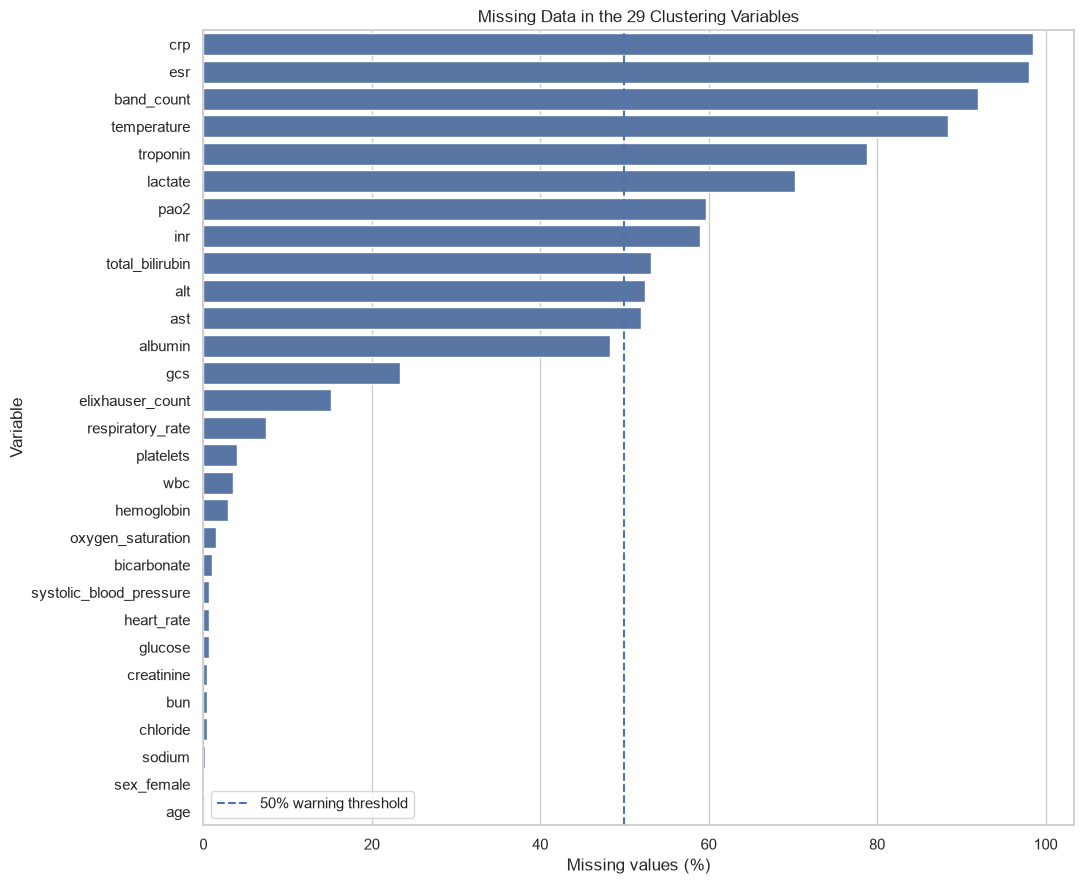

In [34]:
plt.figure(
    figsize=(
        11,
        9,
    )
)


sns.barplot(
    data=missingness_summary,
    x="missing_percent",
    y="variable",
)


plt.axvline(
    MISSINGNESS_WARNING_PERCENT,
    linestyle="--",
    linewidth=1.5,
    label=(
        f"{MISSINGNESS_WARNING_PERCENT:.0f}% warning threshold"
    ),
)


plt.title(
    "Missing Data in the 29 Clustering Variables"
)

plt.xlabel(
    "Missing values (%)"
)

plt.ylabel(
    "Variable"
)

plt.legend()

plt.tight_layout()


plt.savefig(
    MISSINGNESS_DIR / "missingness_percentage.png",
    dpi=300,
    bbox_inches="tight",
)


plt.show()

#### Explanation :
This plot shows which variables have the greatest missingness before imputation.

### Plot the Number of Observed Variables per ICU Stay

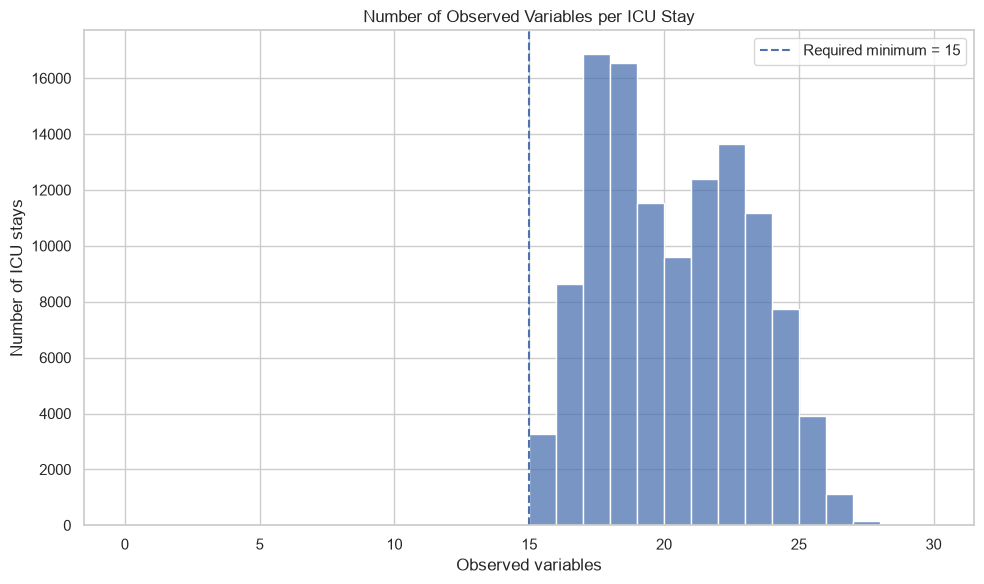

In [35]:
observed_counts_for_plot = (
    analytic_before_imputation[FEATURES]
    .notna()
    .sum(axis=1)
)


plt.figure(
    figsize=(
        10,
        6,
    )
)


sns.histplot(
    observed_counts_for_plot,
    bins=range(
        0,
        len(FEATURES) + 2,
    ),
)


plt.axvline(
    MINIMUM_OBSERVED_FEATURES,
    linestyle="--",
    linewidth=1.5,
    label=(
        f"Required minimum = "
        f"{MINIMUM_OBSERVED_FEATURES}"
    ),
)


plt.title(
    "Number of Observed Variables per ICU Stay"
)

plt.xlabel(
    "Observed variables"
)

plt.ylabel(
    "Number of ICU stays"
)

plt.legend()

plt.tight_layout()


plt.savefig(
    MISSINGNESS_DIR
    / "observed_features_per_icu_stay.png",
    dpi=300,
    bbox_inches="tight",
)


plt.show()

#### Explanation :
This plot shows how complete each ICU stay is before imputation.

### Create an Individual Histogram for Every Variable

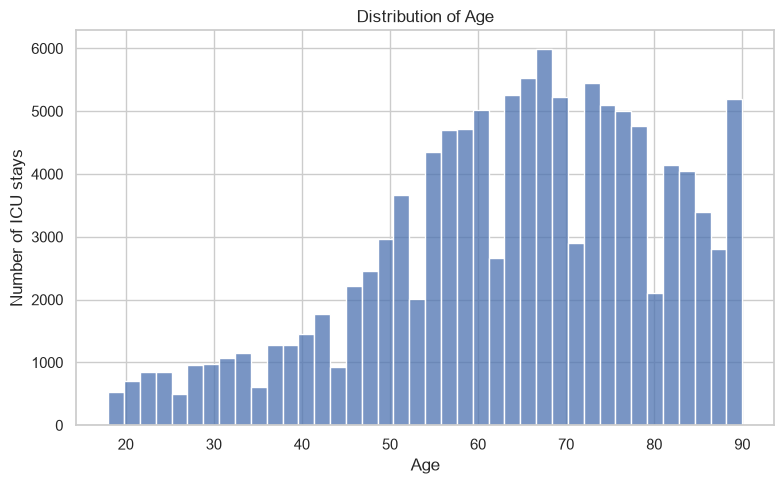

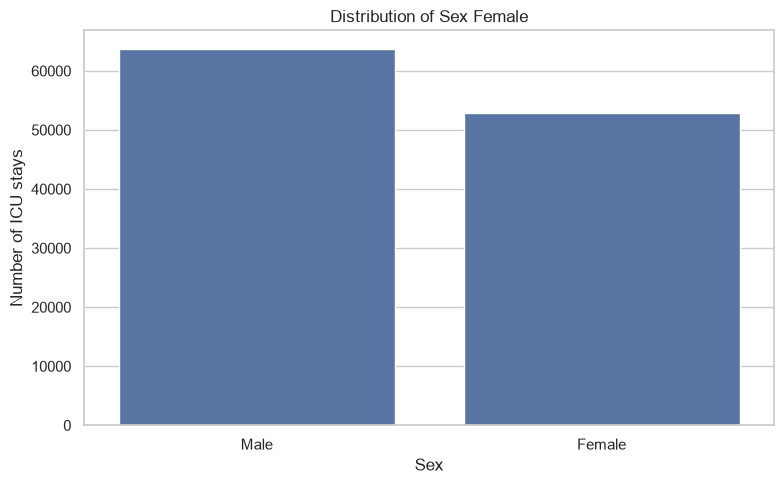

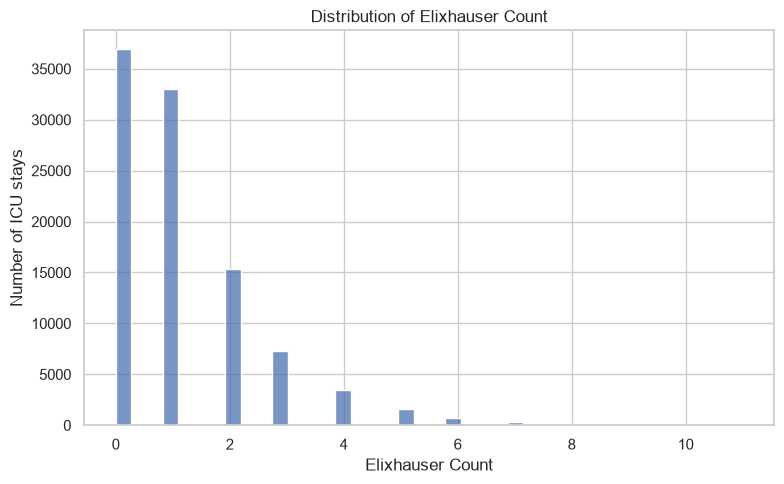

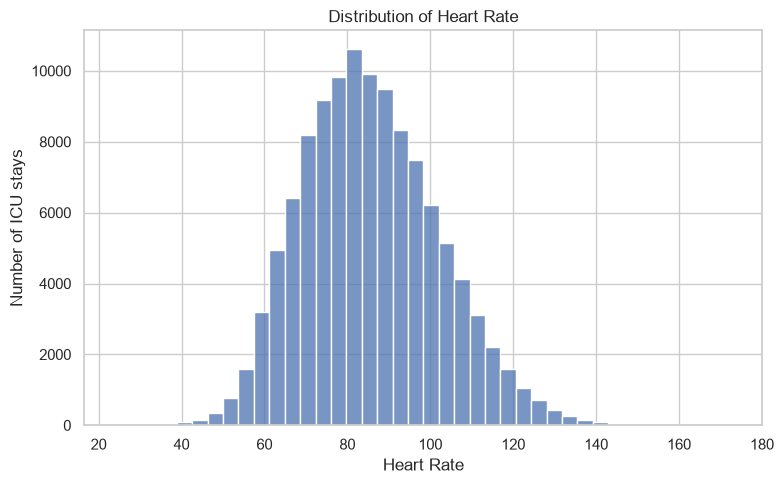

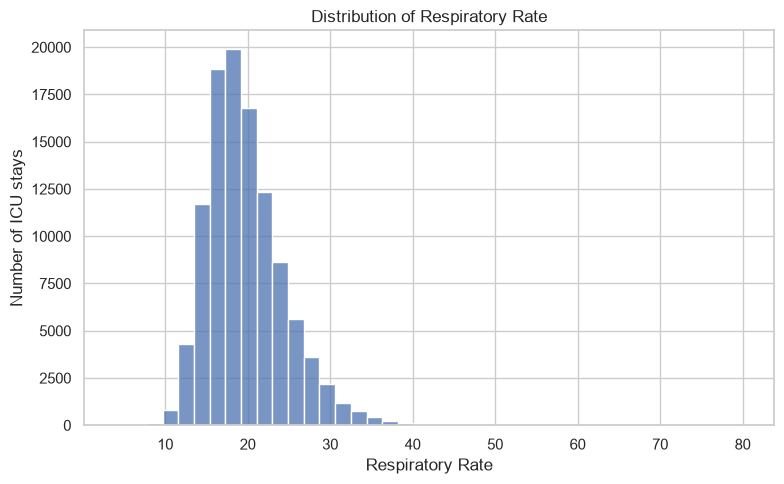

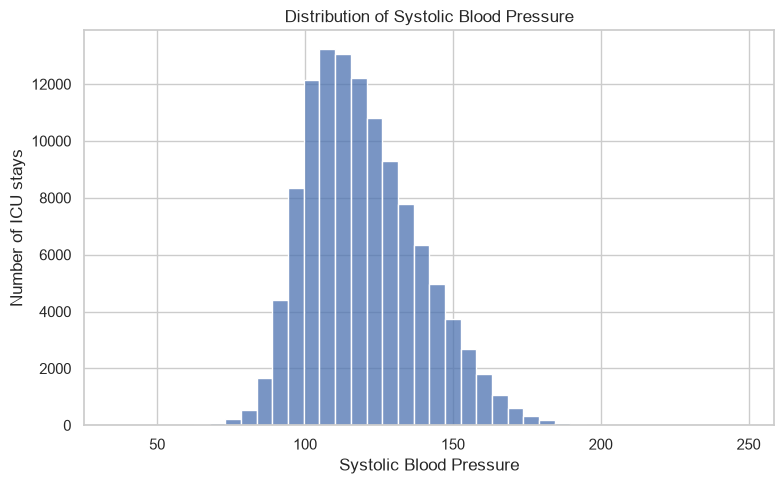

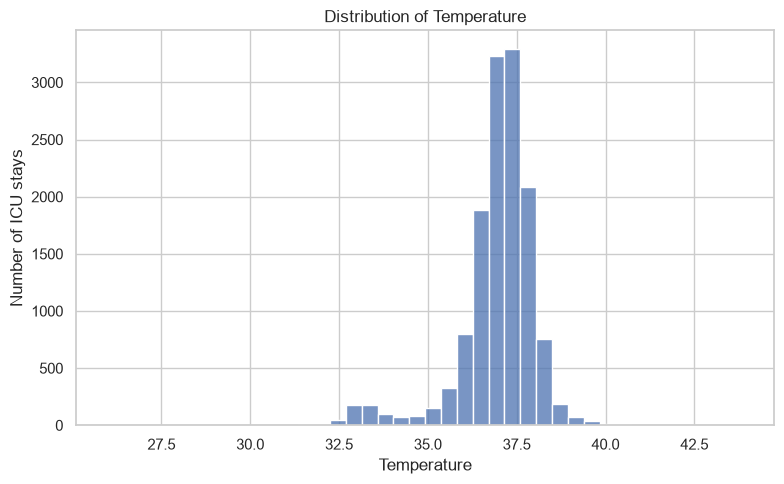

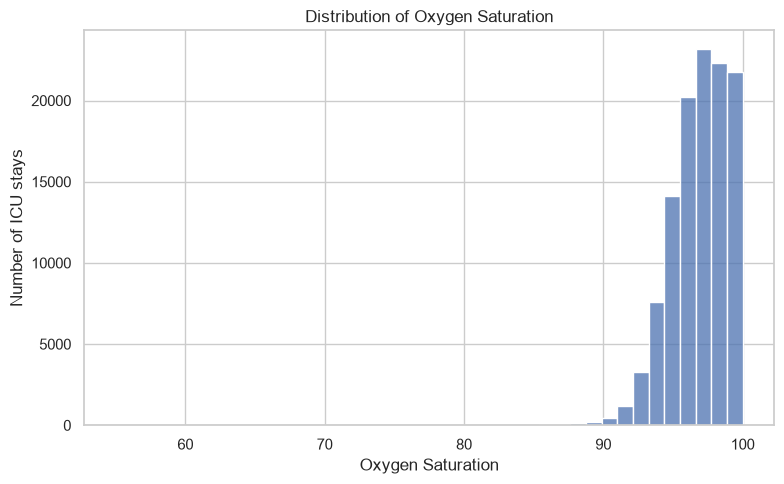

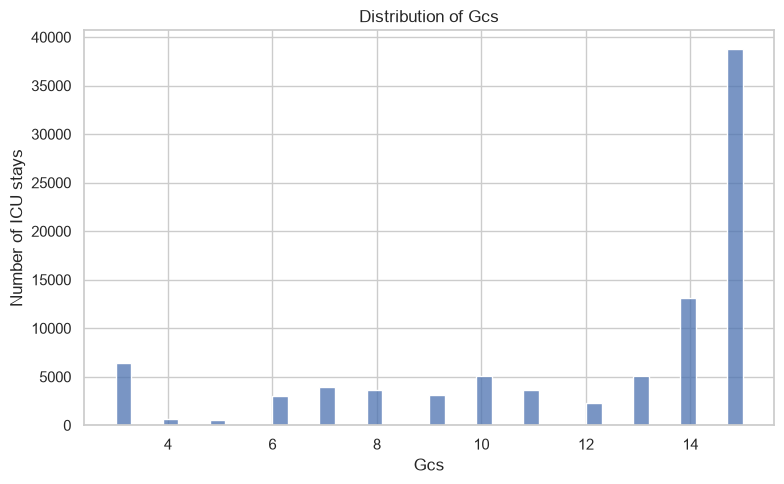

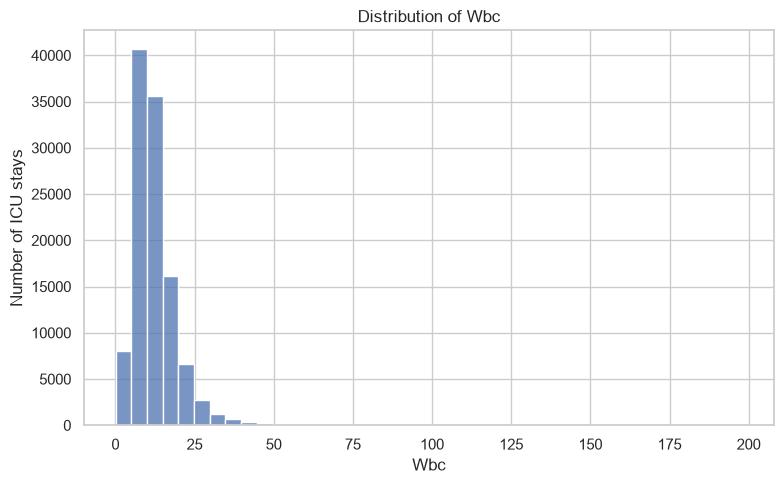

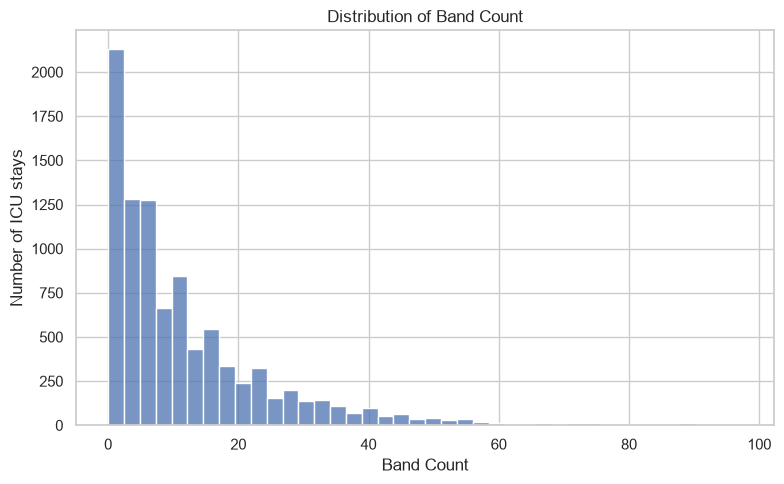

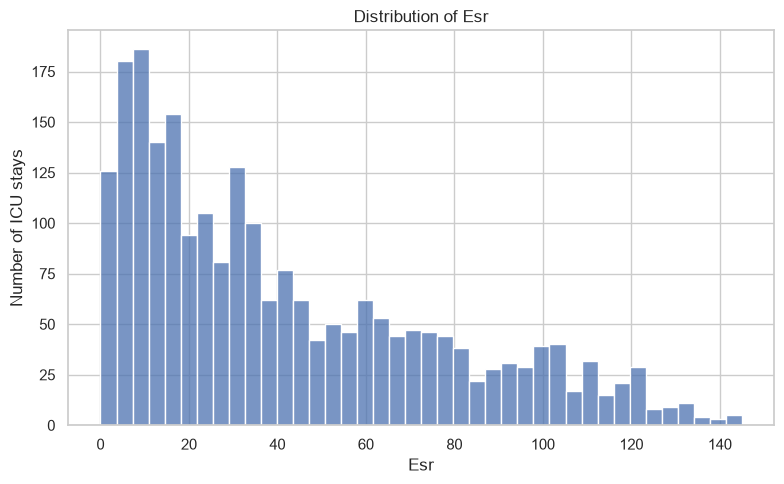

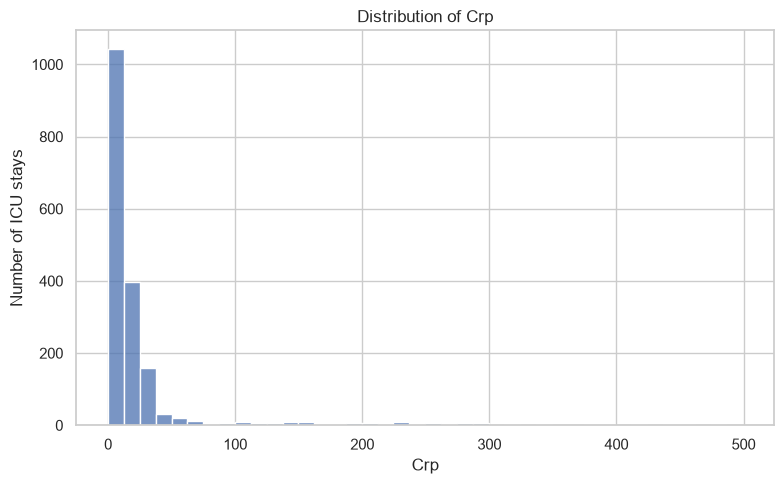

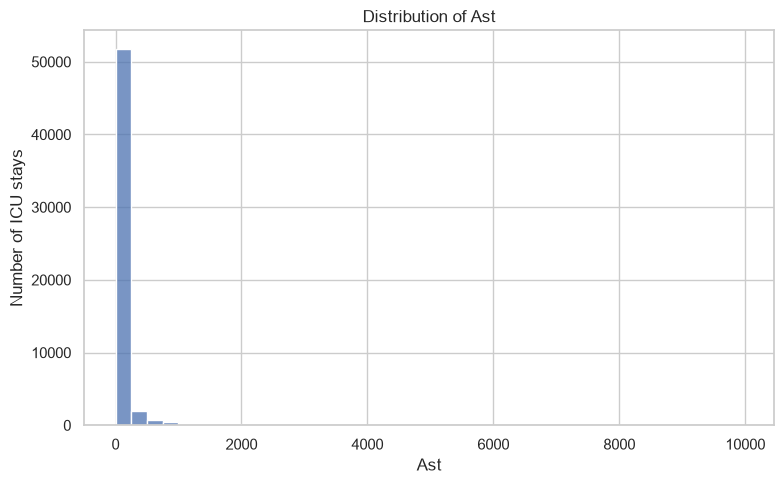

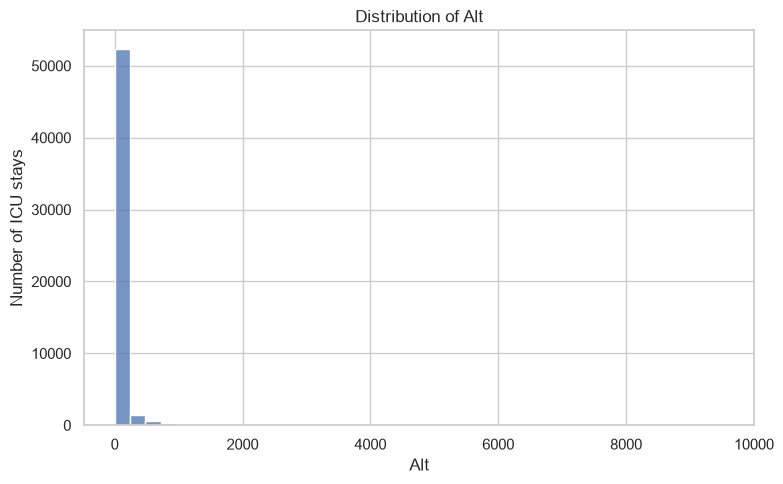

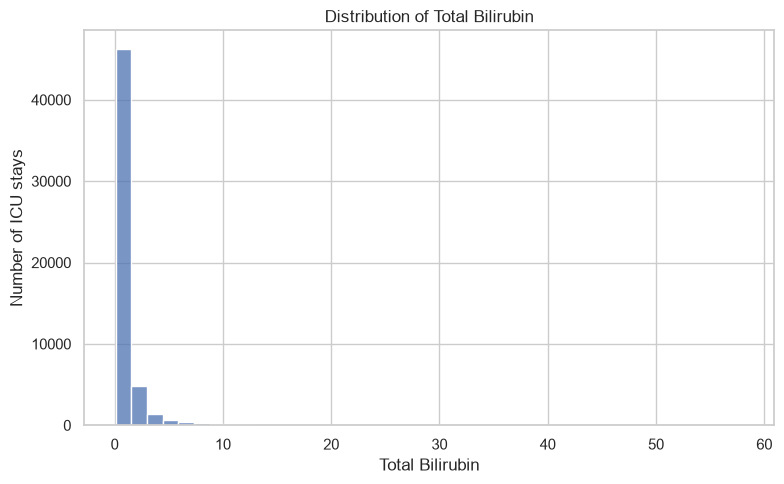

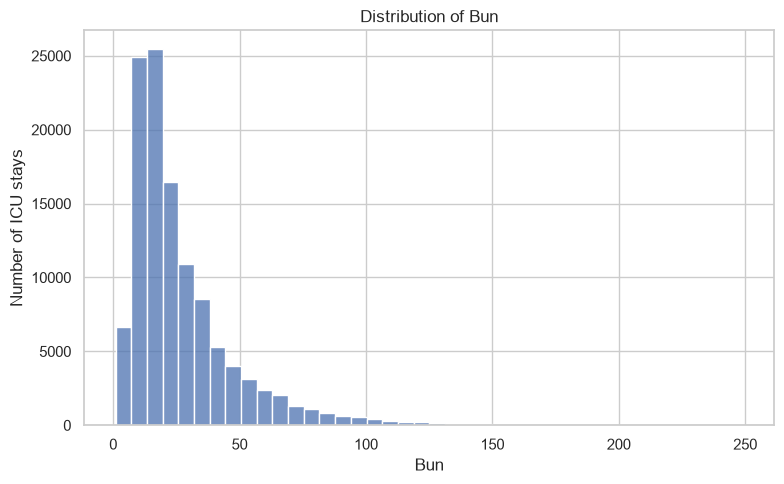

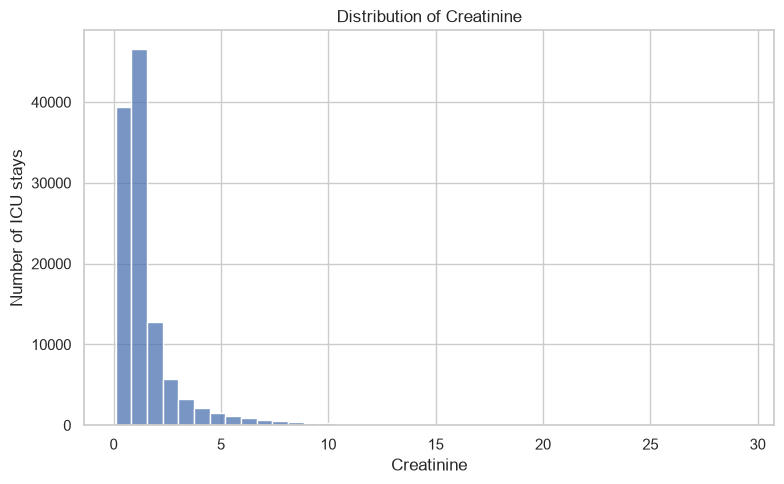

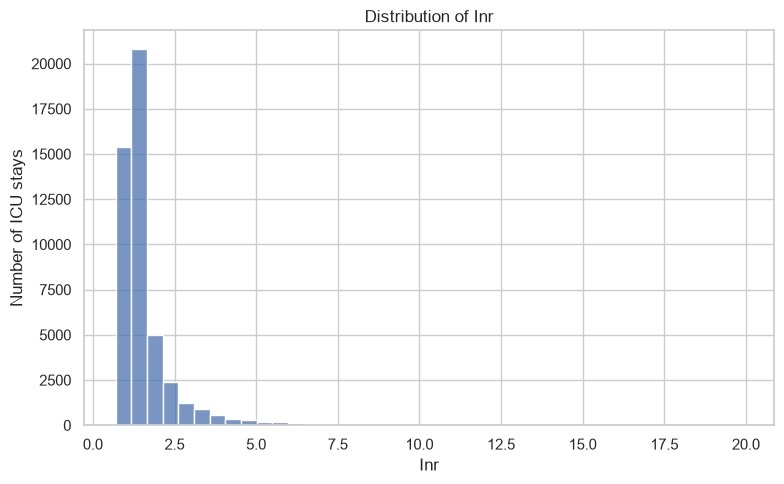

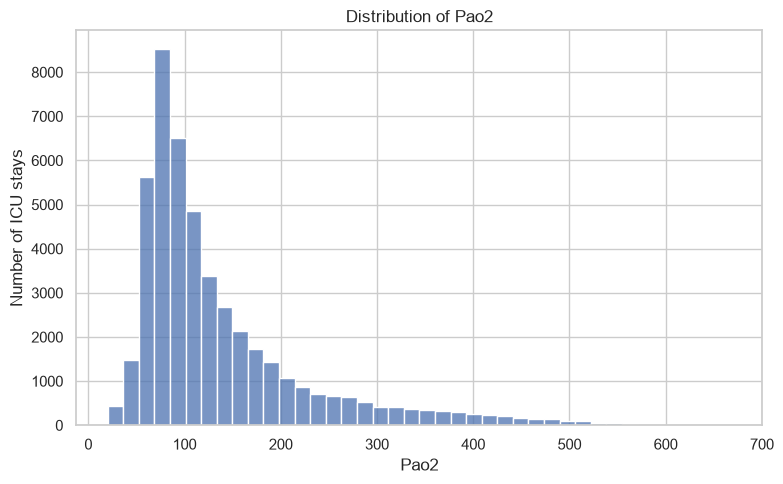

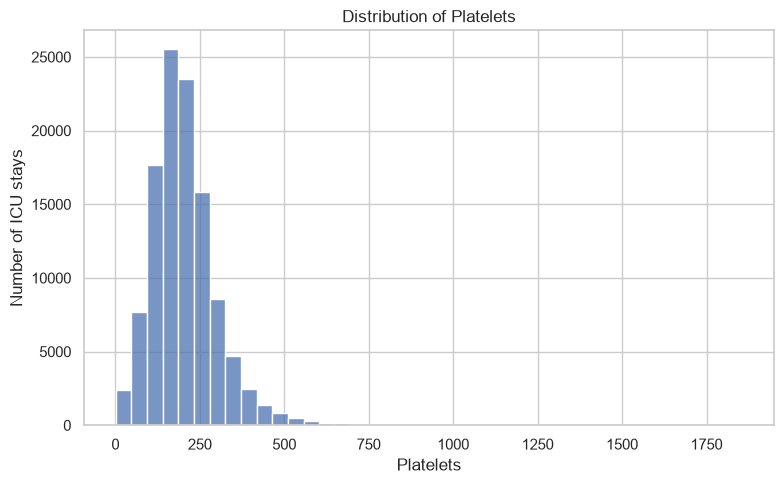

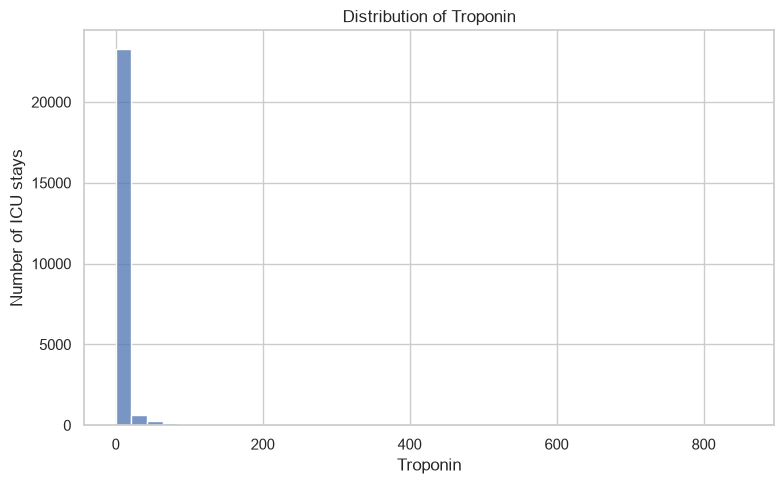

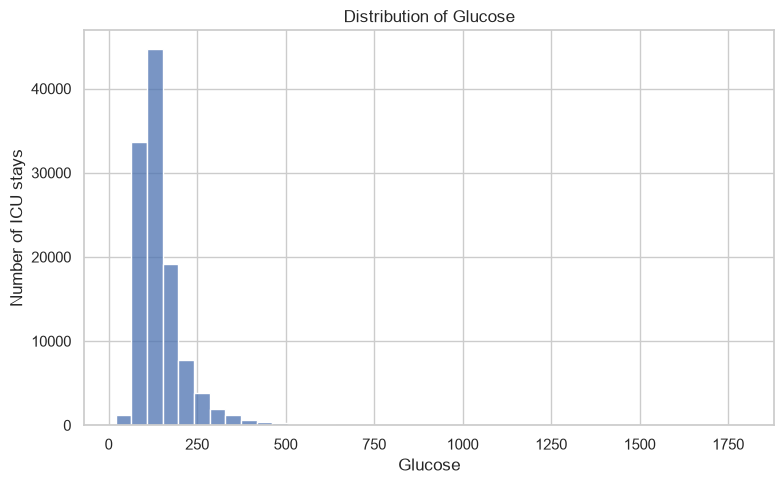

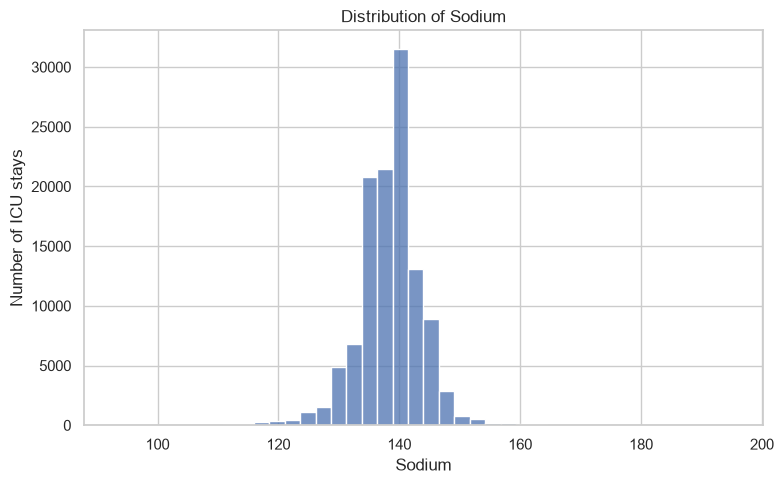

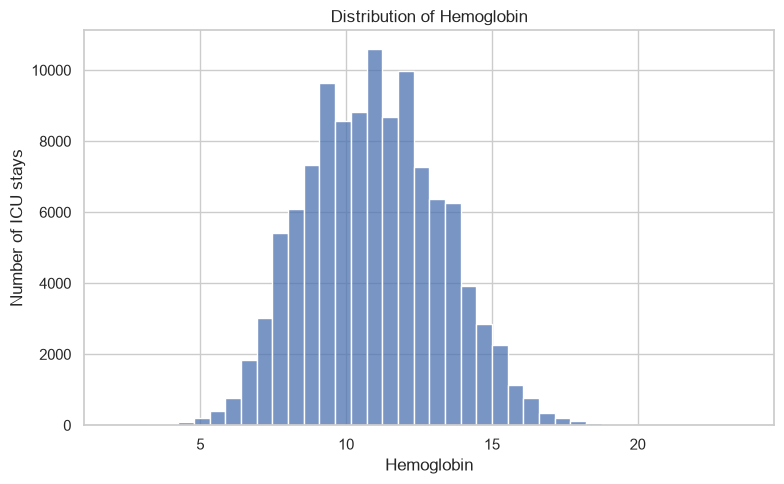

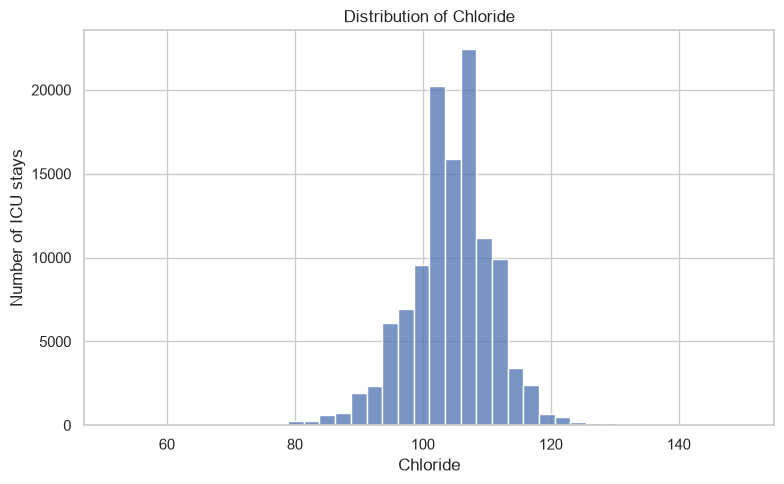

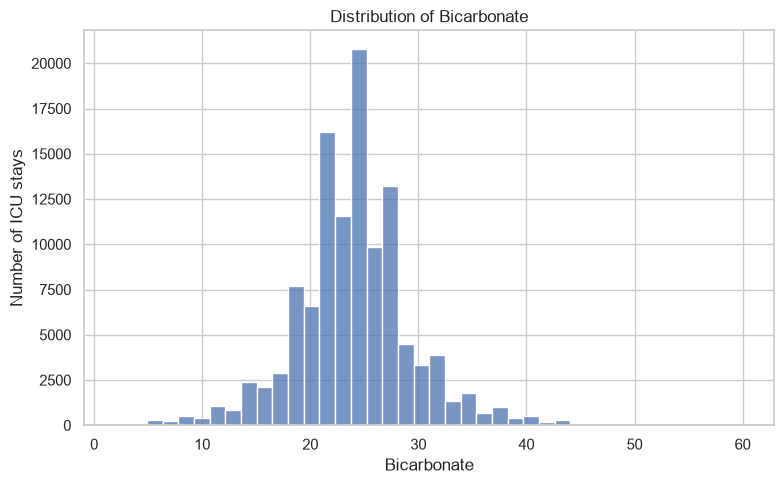

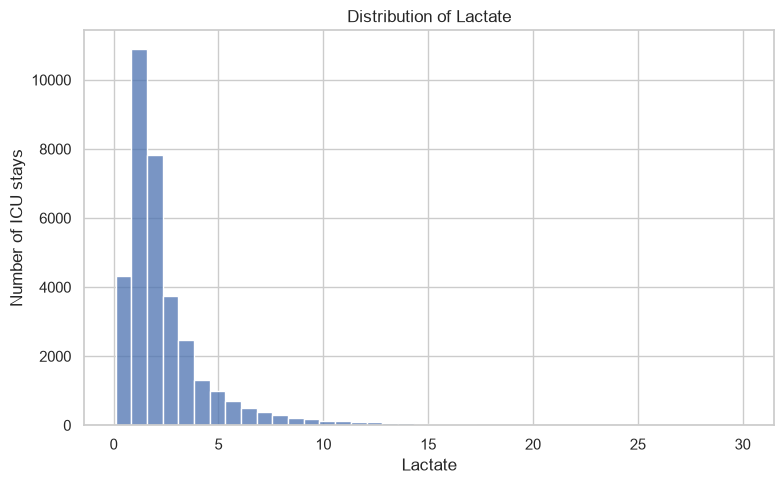

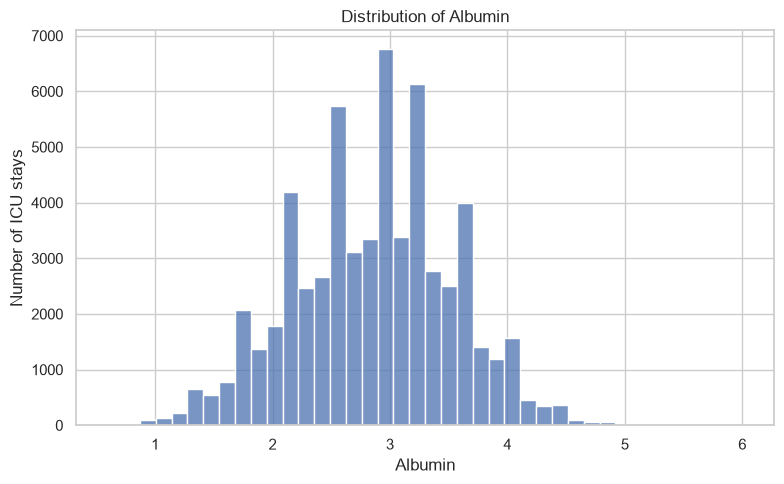

In [36]:
for feature in FEATURES:

    plt.figure(
        figsize=(
            8,
            5,
        )
    )


    if feature == "sex_female":

        sex_counts = (
            analytic_before_imputation[
                feature
            ]
            .map(
                {
                    0.0: "Male",
                    1.0: "Female",
                }
            )
            .value_counts()
            .reset_index()
        )

        sex_counts.columns = [
            "sex",
            "count",
        ]

        sns.barplot(
            data=sex_counts,
            x="sex",
            y="count",
        )

        plt.xlabel(
            "Sex"
        )

    else:

        sns.histplot(
            analytic_before_imputation[
                feature
            ].dropna(),
            bins=40,
        )

        plt.xlabel(
            feature.replace(
                "_",
                " ",
            ).title()
        )


    plt.title(
        f"Distribution of "
        f"{feature.replace('_', ' ').title()}"
    )

    plt.ylabel(
        "Number of ICU stays"
    )

    plt.tight_layout()


    plt.savefig(
        DISTRIBUTION_DIR
        / f"{feature}_histogram.png",
        dpi=300,
        bbox_inches="tight",
    )


    plt.show()

#### Explanation :
This notebook creates one distribution plot for each of the $29$ variables.
Sex is shown as a bar chart because it is categorical

### Create One Combined Distribution Figure

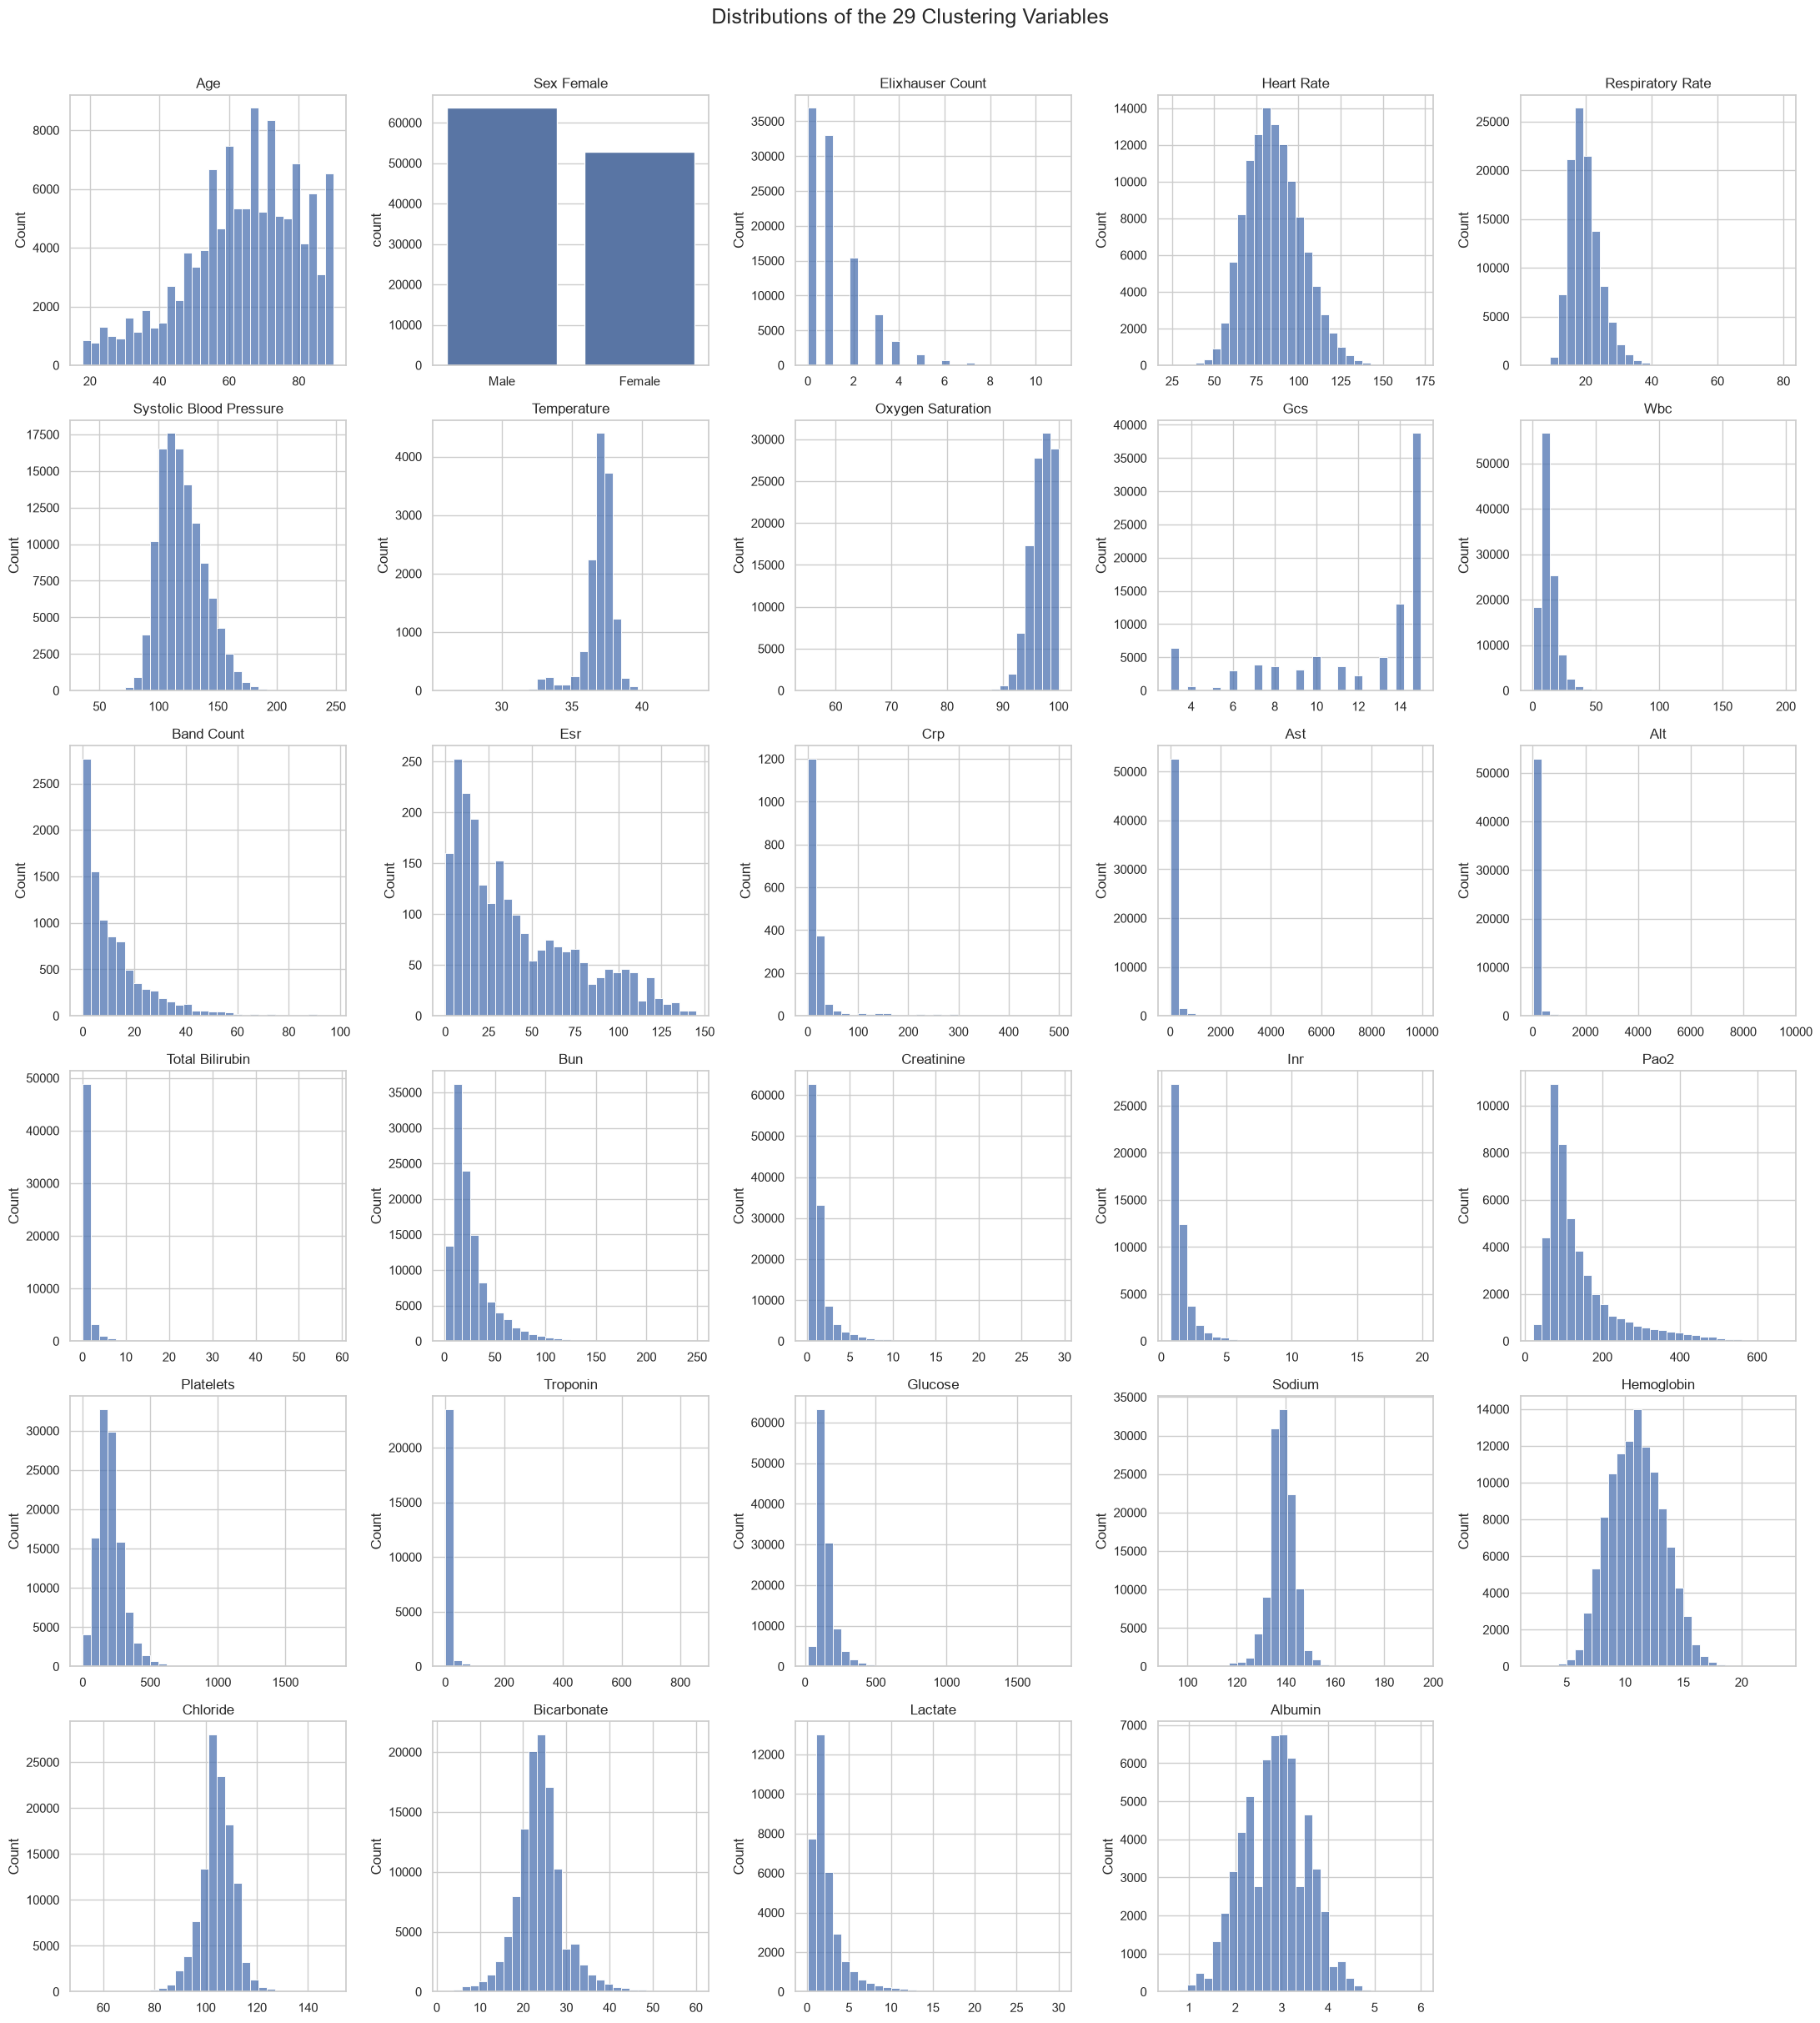

In [37]:
figure, axes = plt.subplots(
    6,
    5,
    figsize=(
        22,
        24,
    ),
)


axes = axes.flatten()


for index, feature in enumerate(FEATURES):

    if feature == "sex_female":

        sns.countplot(
            x=analytic_before_imputation[
                feature
            ],
            ax=axes[index],
        )

        axes[index].set_xticks(
            [
                0,
                1,
            ]
        )

        axes[index].set_xticklabels(
            [
                "Male",
                "Female",
            ]
        )

    else:

        sns.histplot(
            analytic_before_imputation[
                feature
            ].dropna(),
            bins=30,
            ax=axes[index],
        )


    axes[index].set_title(
        feature.replace(
            "_",
            " ",
        ).title()
    )

    axes[index].set_xlabel("")


for index in range(
    len(FEATURES),
    len(axes),
):
    axes[index].axis("off")


figure.suptitle(
    "Distributions of the 29 Clustering Variables",
    fontsize=18,
    y=1.01,
)


figure.tight_layout()


figure.savefig(
    DISTRIBUTION_DIR
    / "all_variable_distributions.png",
    dpi=300,
    bbox_inches="tight",
)


plt.show()

#### Explanation :
This combined figure provides a quick overview of all $29$ variable distributions.

### Create Box Plots for Outlier Examination

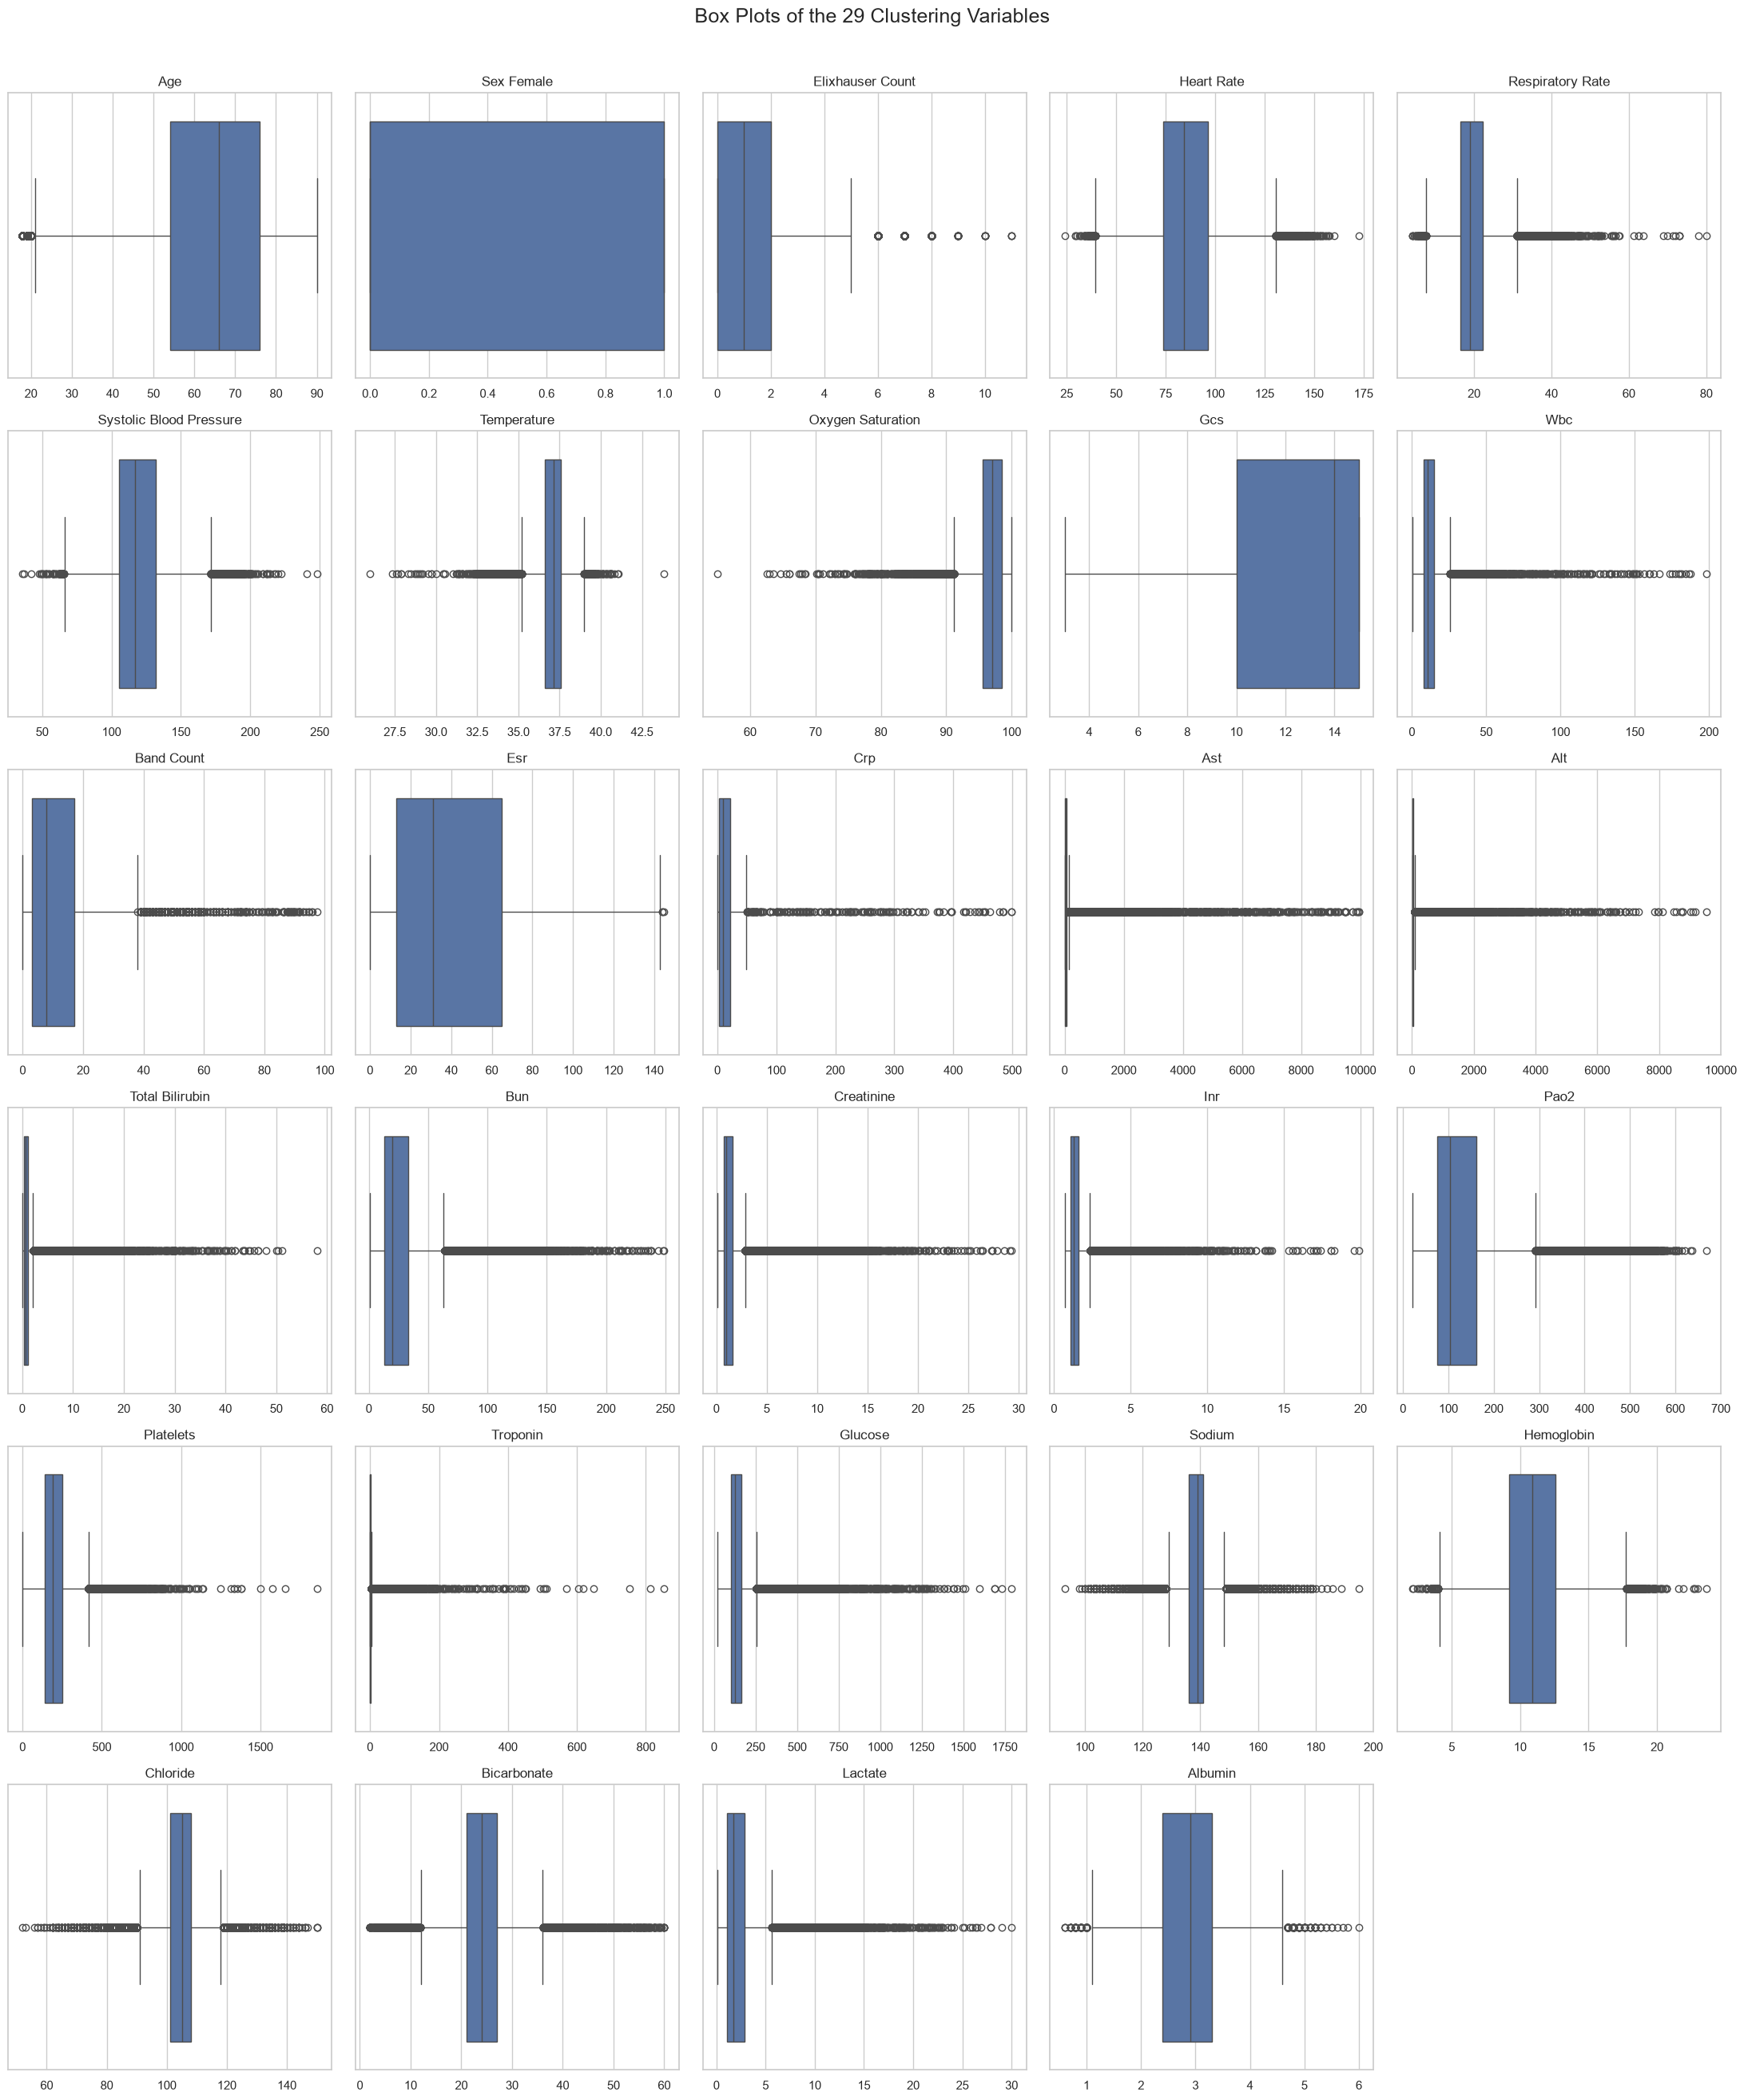

In [38]:
figure, axes = plt.subplots(
    6,
    5,
    figsize=(
        22,
        26,
    ),
)


axes = axes.flatten()


for index, feature in enumerate(FEATURES):

    sns.boxplot(
        x=analytic_before_imputation[
            feature
        ],
        ax=axes[index],
    )

    axes[index].set_title(
        feature.replace(
            "_",
            " ",
        ).title()
    )

    axes[index].set_xlabel("")


for index in range(
    len(FEATURES),
    len(axes),
):
    axes[index].axis("off")


figure.suptitle(
    "Box Plots of the 29 Clustering Variables",
    fontsize=18,
    y=1.01,
)


figure.tight_layout()


figure.savefig(
    OUTLIER_DIR / "variable_boxplots.png",
    dpi=300,
    bbox_inches="tight",
)


plt.show()

#### Explanation :

Box Plots make the remaining extremen values easier to identify after the broad plausibility filtering.

### Apply the Initial Missing-Data Strategy

In [39]:
analytic_dataset = (
    analytic_before_imputation.copy()
)


# ---------------------------------------------------------
# Continuous variables: median imputation
# ---------------------------------------------------------
continuous_imputer = SimpleImputer(
    strategy="median"
)


analytic_dataset[
    CONTINUOUS_FEATURES
] = continuous_imputer.fit_transform(
    analytic_dataset[
        CONTINUOUS_FEATURES
    ]
)


# ---------------------------------------------------------
# Binary sex variable: most frequent category
# ---------------------------------------------------------
sex_imputer = SimpleImputer(
    strategy="most_frequent"
)


analytic_dataset[
    [
        "sex_female",
    ]
] = sex_imputer.fit_transform(
    analytic_dataset[
        [
            "sex_female",
        ]
    ]
)


print(
    "Initial missing-data imputation was completed."
)

Initial missing-data imputation was completed.


#### Explanation :
The initial missing-data strategy uses :
- Median imputation for continuous variables
- Most frequent category for sex

The median is less sensitive to extreme values than the mean. This is an initial strategy alternative imputation methods can be evaluated later in sensitivity analyses.

### Save the Imputation Summary

In [40]:
continuous_imputation_summary = pd.DataFrame(
    {
        "variable": CONTINUOUS_FEATURES,
        "imputation_method": "median",
        "imputation_value": (
            continuous_imputer.statistics_
        ),
    }
)


sex_imputation_summary = pd.DataFrame(
    {
        "variable": [
            "sex_female",
        ],
        "imputation_method": [
            "most frequent category",
        ],
        "imputation_value": [
            sex_imputer.statistics_[0],
        ],
    }
)


imputation_summary = pd.concat(
    [
        continuous_imputation_summary,
        sex_imputation_summary,
    ],
    ignore_index=True,
)


imputation_summary.to_csv(
    RESULTS_DIR / "imputation_summary.csv",
    index=False,
)


imputation_summary

,variable,imputation_method,imputation_value
0,age,median,66.000000
1,elixhauser_count,median,1.000000
2,heart_rate,median,84.399306
3,respiratory_rate,median,19.008403
4,systolic_blood_pressure,median,117.230769
5,temperature,median,37.119459
6,oxygen_saturation,median,97.101626
7,gcs,median,14.000000
8,wbc,median,10.800000
9,band_count,median,7.800000


#### Explanation :
This table records the exact value used to fill missing data for every variable.

### Confirm that Imputation is Complete

In [41]:
remaining_missing_values = (
    analytic_dataset[FEATURES]
    .isna()
    .sum()
    .sum()
)


if remaining_missing_values > 0:

    missing_after_imputation = (
        analytic_dataset[FEATURES]
        .isna()
        .sum()
    )

    missing_after_imputation = (
        missing_after_imputation[
            missing_after_imputation > 0
        ]
    )

    raise ValueError(
        "Missing values remain after imputation:\n"
        f"{missing_after_imputation}"
    )


print(
    "No missing values remain in the 29 clustering variables."
)

No missing values remain in the 29 clustering variables.


#### Explanation :
This cell ensures that no missing values remain.

### Save the Clinically Interpretable Analytic Dataset

In [42]:
analytic_dataset = analytic_dataset[
    [
        ID_COLUMN,
        *FEATURES,
    ]
]


analytic_dataset.to_csv(
    ANALYTIC_DATASET_PATH,
    index=False,
)


print(
    f"Analytic dataset saved to:\n"
    f"{ANALYTIC_DATASET_PATH}"
)

print(
    f"\nDataset shape: "
    f"{analytic_dataset.shape}"
)

analytic_dataset.head()

Analytic dataset saved to:
C:\Users\samsa\Documents\Capstone Project\Project\data\analytic_dataset.csv

Dataset shape: (116573, 30)


,patientunitstayid,age,sex_female,elixhauser_count,heart_rate,respiratory_rate,systolic_blood_pressure,temperature,oxygen_saturation,gcs,wbc,band_count,esr,crp,ast,alt,total_bilirubin,bun,creatinine,inr,pao2,platelets,troponin,glucose,sodium,hemoglobin,chloride,bicarbonate,lactate,albumin
0,141168,70.0,1.0,4.0,125.052830,19.008403,108.500000,37.119459,86.741935,14.0,9.8,7.8,31.0,9.1,59.0,40.0,2.60,26.0,1.95,1.7,103.0,209.0,0.19,131.0,139.0,13.0,102.0,26.0,1.7,3.1
1,141194,68.0,0.0,1.0,86.860627,23.193662,88.896552,37.119459,98.589474,15.0,14.1,7.8,31.0,9.1,24.0,20.0,0.40,31.0,2.51,1.3,103.0,233.0,0.19,165.0,135.0,8.9,105.0,19.0,1.3,2.3
2,141196,71.0,0.0,1.0,82.305147,24.114815,131.285714,37.119459,95.509434,15.0,26.2,7.8,31.0,9.1,15.0,18.0,0.30,16.0,0.80,1.3,70.0,453.0,0.19,144.0,135.0,10.3,97.0,30.0,1.7,2.5
3,141203,77.0,1.0,2.0,91.538194,18.713208,103.530769,37.119459,98.102473,14.0,12.7,7.8,31.0,9.1,22.0,15.0,0.50,9.0,0.56,1.3,51.0,557.0,0.02,145.0,145.0,11.3,107.0,25.0,3.5,1.6
4,141227,82.0,0.0,0.0,108.975610,34.344948,114.753846,37.119459,94.737037,10.0,42.7,10.0,31.0,9.1,32.0,27.0,0.64,30.0,1.60,1.3,65.0,198.0,0.50,145.0,133.0,8.2,101.0,16.0,1.4,2.9


#### Explanation :
`analytic_dataset.csv` contains the ICU identifier and $29$ cleaned and imputed variables in clinically interpretable units.

### Calculate Descriptive Statistics after Imputation

In [43]:
descriptive_statistics_after_imputation = (
    create_descriptive_statistics(
        analytic_dataset,
        FEATURES,
    )
)


descriptive_statistics_after_imputation.to_csv(
    RESULTS_DIR
    / "descriptive_statistics_after_imputation.csv"
)


descriptive_statistics_after_imputation

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,iqr,missing_count,missing_percent,skewness
age,116573.0,63.924974,16.471941,18.0,21.000000,31.000000,54.000000,66.000000,76.000000,88.000000,90.000000,90.000000,22.000000,0,0.0,-0.569738
sex_female,116573.0,0.453767,0.497860,0.0,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0,0.0,0.185729
elixhauser_count,116573.0,1.138480,1.213039,0.0,0.000000,0.000000,0.000000,1.000000,1.000000,4.000000,5.000000,11.000000,1.000000,0,0.0,1.765766
heart_rate,116573.0,85.585738,16.380528,24.0,52.902365,60.905792,73.708029,84.399306,96.282230,114.305869,127.022215,172.666667,22.574201,0,0.0,0.351015
respiratory_rate,116573.0,19.718464,4.605791,4.0,11.762313,13.633803,16.647687,19.008403,21.954704,28.261246,34.076687,80.000000,5.307017,0,0.0,1.275917
systolic_blood_pressure,116573.0,119.692056,18.924824,36.0,85.029067,93.315823,105.592233,117.230769,131.739130,154.299104,169.283478,248.000000,26.146897,0,0.0,0.561857
temperature,116573.0,37.099935,0.387941,26.0,35.806739,36.996208,37.119459,37.119459,37.119459,37.236544,38.016626,43.850000,0.000000,0,0.0,-7.065620
oxygen_saturation,116573.0,96.873190,2.181927,55.0,90.956023,93.284035,95.607407,97.101626,98.485915,99.770035,99.992143,100.000000,2.878508,0,0.0,-1.811391
gcs,116573.0,12.510530,3.453897,3.0,3.000000,3.000000,11.000000,14.000000,15.000000,15.000000,15.000000,15.000000,4.000000,0,0.0,-1.555800
wbc,116573.0,12.285356,7.574325,0.1,2.100000,4.500000,7.900000,10.800000,14.800000,24.600000,37.400000,198.100000,6.900000,0,0.0,4.799927


#### Explanation :
This table shows how the variable distributions changed after filling missing values.

### Calculate the Spearman Correlation Matrix

In [44]:
correlation_matrix = (
    analytic_dataset[FEATURES]
    .corr(
        method="spearman"
    )
)


correlation_matrix.to_csv(
    RESULTS_DIR / "correlation_matrix.csv"
)


correlation_matrix.round(3)

,age,sex_female,elixhauser_count,heart_rate,respiratory_rate,systolic_blood_pressure,temperature,oxygen_saturation,gcs,wbc,band_count,esr,crp,ast,alt,total_bilirubin,bun,creatinine,inr,pao2,platelets,troponin,glucose,sodium,hemoglobin,chloride,bicarbonate,lactate,albumin
age,1.000,0.056,0.046,-0.165,0.079,0.028,-0.029,-0.076,-0.005,-0.015,0.008,0.003,0.006,-0.055,-0.084,0.008,0.316,0.174,0.078,-0.013,-0.072,-0.005,0.028,0.056,-0.125,0.013,0.074,0.013,-0.067
sex_female,0.056,1.000,0.013,0.047,0.029,0.001,-0.001,0.032,0.003,0.008,-0.002,0.001,-0.007,-0.043,-0.057,-0.102,-0.077,-0.174,-0.015,-0.000,0.119,-0.018,0.002,0.034,-0.139,0.019,-0.019,-0.018,-0.034
elixhauser_count,0.046,0.013,1.000,0.030,0.020,0.012,-0.016,-0.020,0.037,-0.049,-0.002,0.004,0.005,0.007,0.007,0.043,0.113,0.119,0.045,-0.028,-0.052,-0.059,0.026,-0.061,-0.045,-0.084,0.047,-0.002,0.010
heart_rate,-0.165,0.047,0.030,1.000,0.273,-0.133,0.087,-0.068,-0.075,0.171,0.032,0.021,0.025,0.081,0.054,0.061,0.021,-0.008,0.081,-0.036,0.049,-0.033,0.103,-0.031,-0.084,-0.018,-0.141,0.088,-0.136
respiratory_rate,0.079,0.029,0.020,0.273,1.000,-0.006,0.048,-0.201,0.034,0.088,0.024,0.019,0.015,0.047,0.032,0.044,0.104,0.063,0.071,-0.112,0.039,-0.000,0.040,-0.030,-0.021,-0.059,-0.039,0.068,-0.064
systolic_blood_pressure,0.028,0.001,0.012,-0.133,-0.006,1.000,0.015,-0.024,0.073,-0.079,-0.049,-0.013,-0.016,-0.096,-0.033,-0.080,-0.097,-0.066,-0.143,-0.011,0.109,-0.023,0.057,0.039,0.152,-0.069,0.143,-0.060,0.174
temperature,-0.029,-0.001,-0.016,0.087,0.048,0.015,1.000,-0.016,-0.004,0.006,0.009,-0.005,0.011,-0.012,-0.014,-0.001,-0.038,-0.034,-0.011,-0.016,0.014,-0.001,-0.003,0.009,0.017,0.008,0.013,-0.004,0.008
oxygen_saturation,-0.076,0.032,-0.020,-0.068,-0.201,-0.024,-0.016,1.000,-0.200,0.004,-0.004,-0.003,-0.009,0.001,-0.020,-0.015,-0.020,0.003,-0.017,0.260,-0.025,0.025,0.008,0.056,-0.152,0.145,-0.144,0.005,-0.034
gcs,-0.005,0.003,0.037,-0.075,0.034,0.073,-0.004,-0.200,1.000,-0.123,-0.021,0.003,0.002,-0.104,-0.056,-0.037,-0.050,-0.040,-0.024,-0.104,0.048,0.004,-0.075,-0.154,0.023,-0.123,0.092,-0.082,0.074
wbc,-0.015,0.008,-0.049,0.171,0.088,-0.079,0.006,0.004,-0.123,1.000,-0.005,0.014,0.021,0.079,0.057,0.012,0.089,0.069,0.036,0.023,0.277,0.046,0.202,-0.020,0.060,0.025,-0.153,0.078,-0.071


#### Explanation :
Spearman correlation is used because many clinical variables are non-normal or skewed.

### Create the Correlation Heatmap

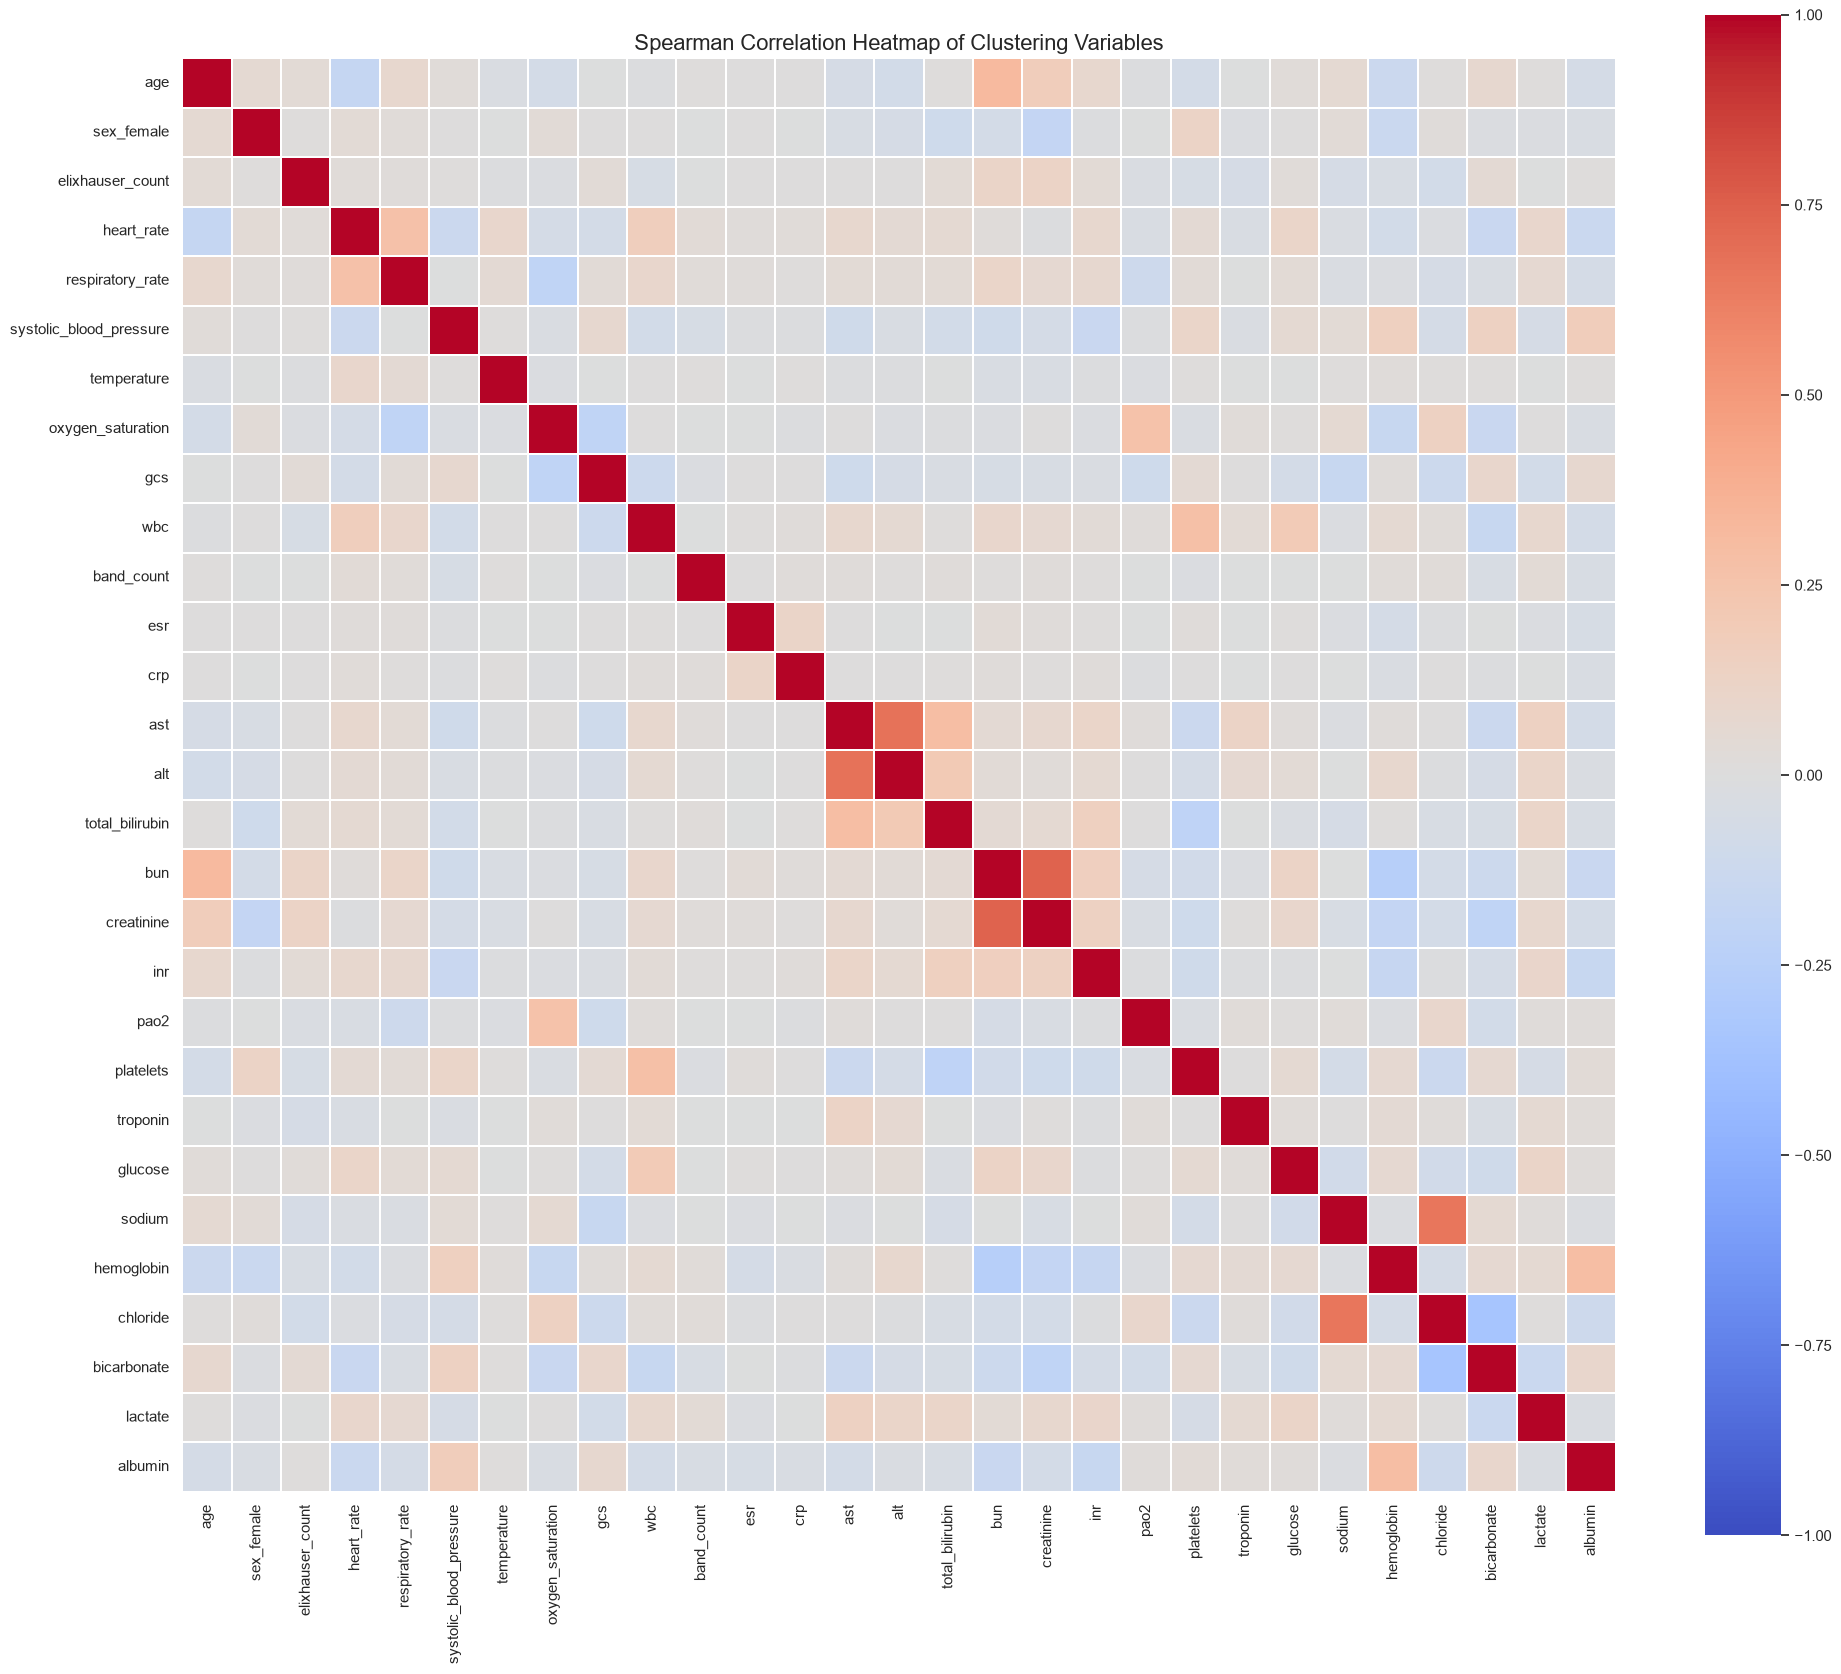

In [45]:
plt.figure(
    figsize=(
        20,
        17,
    )
)


sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.2,
)


plt.title(
    "Spearman Correlation Heatmap of Clustering Variables",
    fontsize=16,
)


plt.tight_layout()


plt.savefig(
    CORRELATION_DIR / "correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight",
)


plt.show()

#### Explanation :
The heatmap identifies variables that may contain similar information and could receive excessive influence in Euclidean-distance calculations.

### Identify Highly Correlated Variables Pairs

In [46]:
upper_triangle = correlation_matrix.where(
    np.triu(
        np.ones(
            correlation_matrix.shape
        ),
        k=1,
    ).astype(bool)
)


strong_pair_rows = []


for column in upper_triangle.columns:

    for row in upper_triangle.index:

        correlation_value = upper_triangle.loc[
            row,
            column,
        ]

        if (
            pd.notna(correlation_value)
            and abs(correlation_value)
            >= STRONG_CORRELATION_THRESHOLD
        ):

            strong_pair_rows.append(
                {
                    "variable_1": row,
                    "variable_2": column,
                    "correlation": correlation_value,
                    "absolute_correlation": abs(
                        correlation_value
                    ),
                }
            )


strong_correlation_pairs = pd.DataFrame(
    strong_pair_rows,
    columns=[
        "variable_1",
        "variable_2",
        "correlation",
        "absolute_correlation",
    ],
)


if not strong_correlation_pairs.empty:

    strong_correlation_pairs = (
        strong_correlation_pairs
        .sort_values(
            "absolute_correlation",
            ascending=False,
        )
    )


strong_correlation_pairs.to_csv(
    RESULTS_DIR / "strong_correlation_pairs.csv",
    index=False,
)


strong_correlation_pairs

,variable_1,variable_2,correlation,absolute_correlation


#### Explanation :
Variable pairs with an absolute Spearman correlation of atleast $0.80$ are listed for review.

The notebook does not automatically remove them because clinical importance should also be considered.

### Examine Skewness and Apply Appropriate Transformations

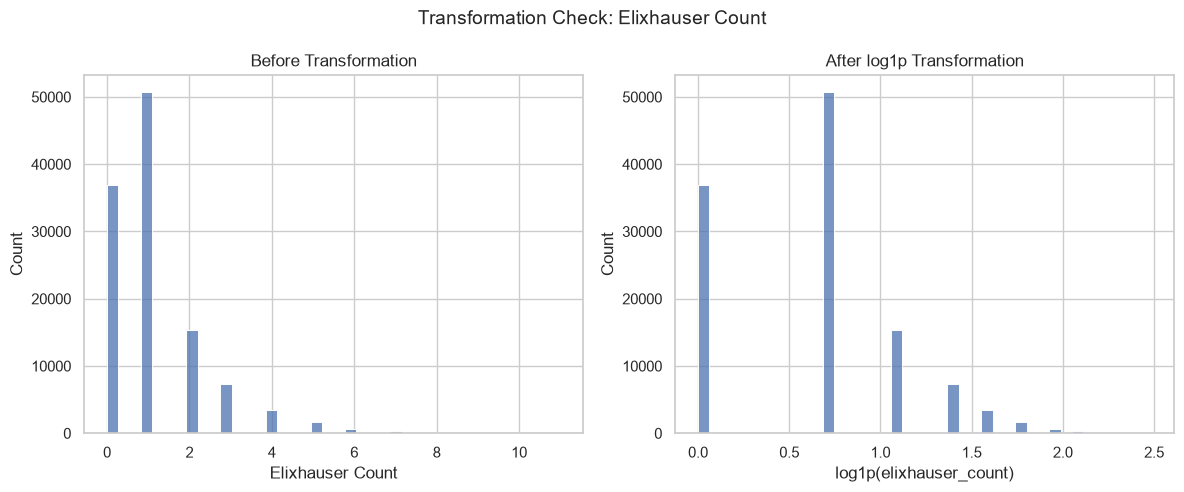

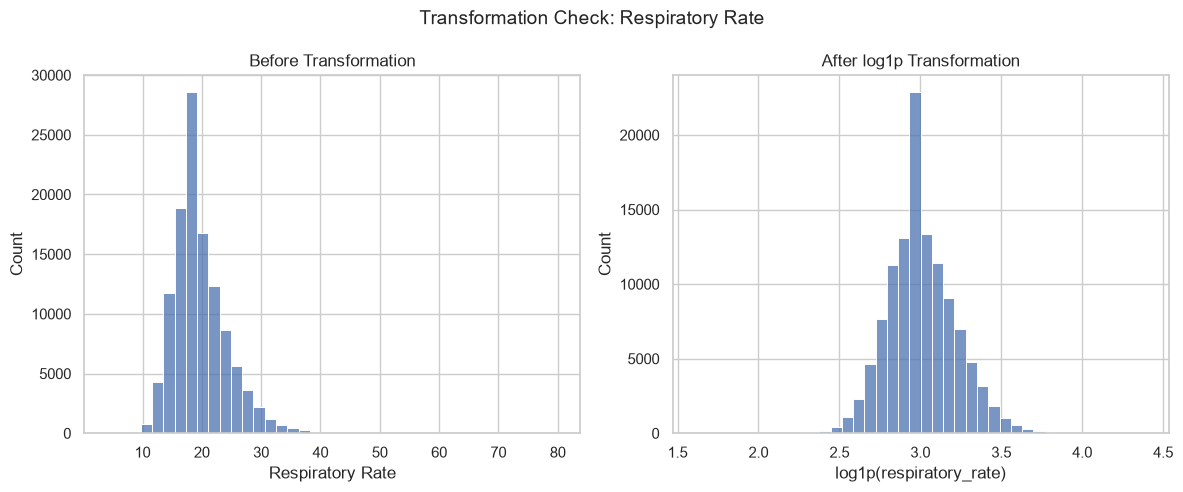

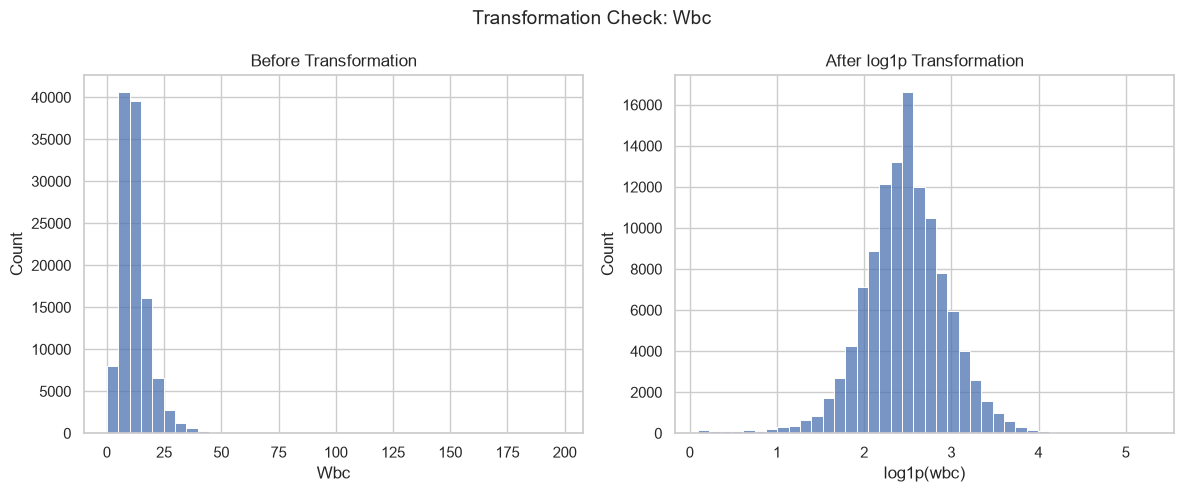

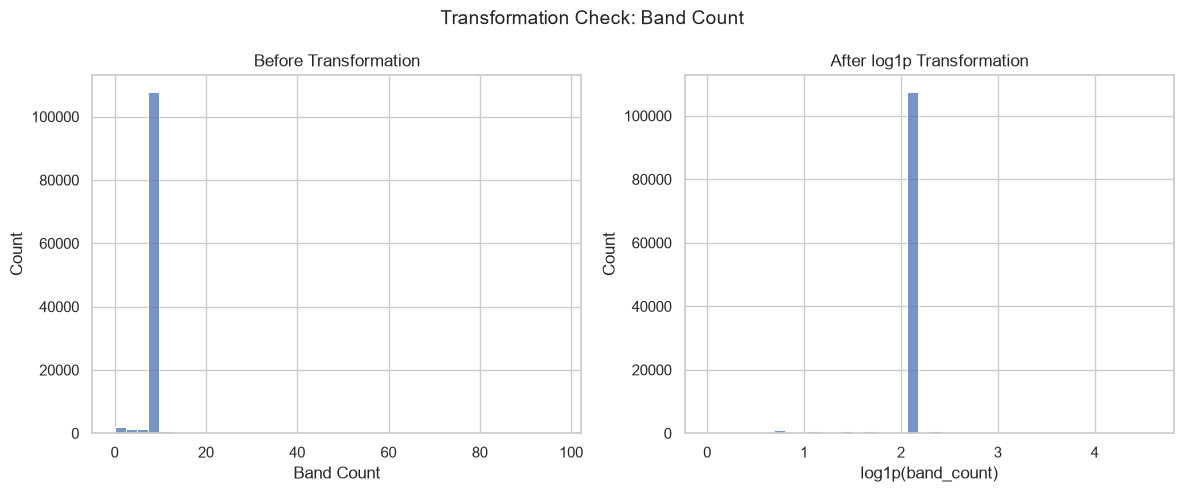

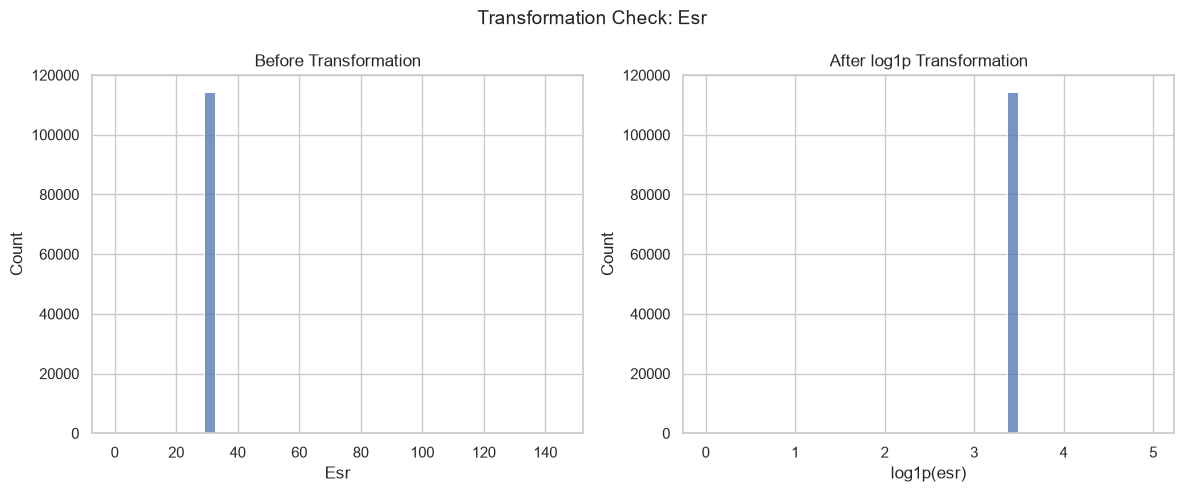

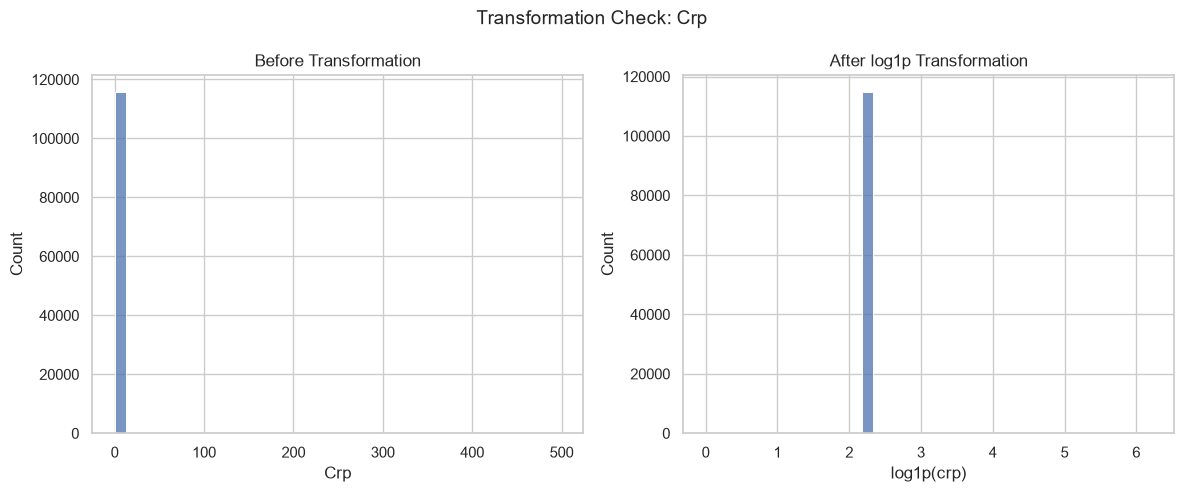

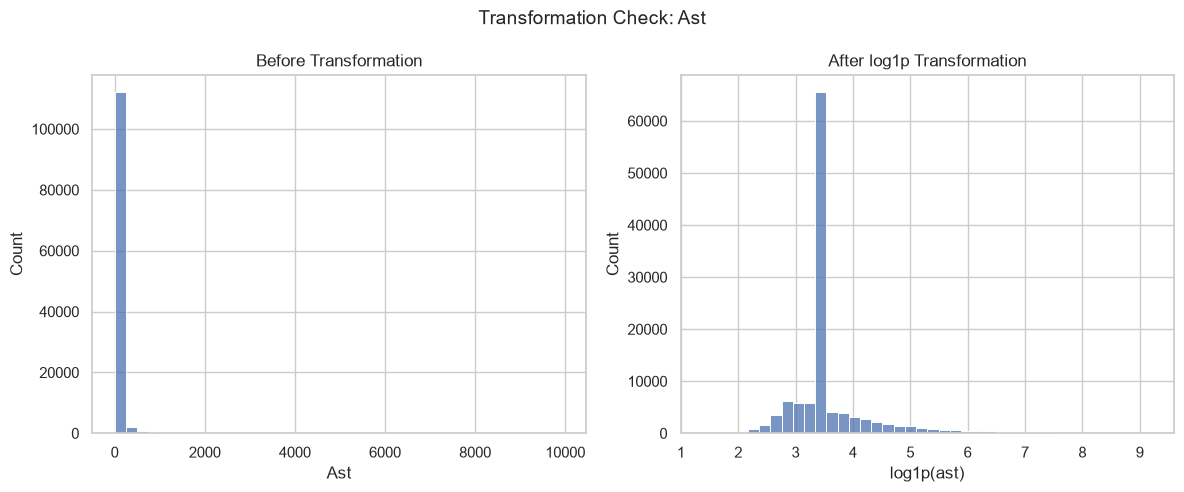

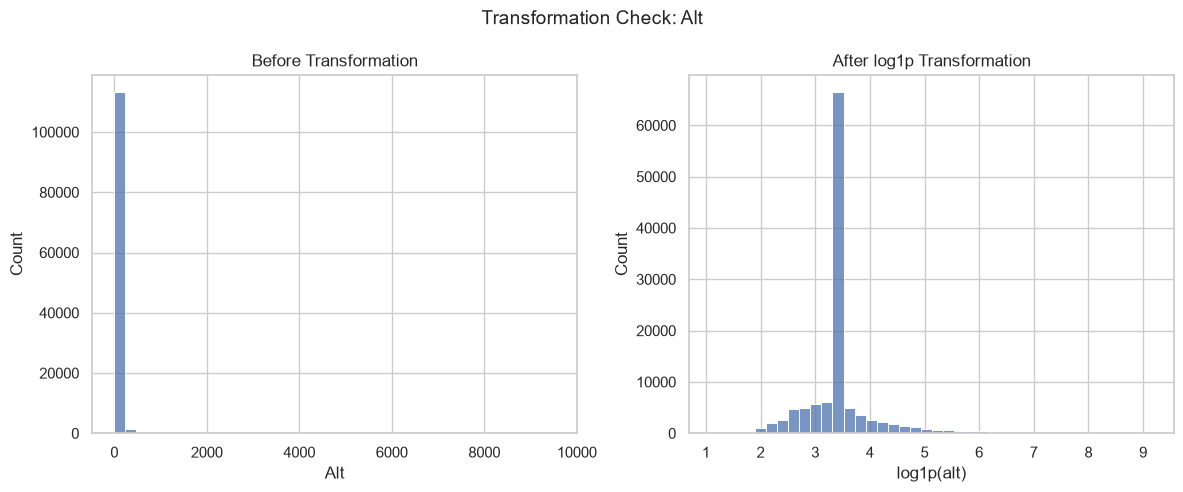

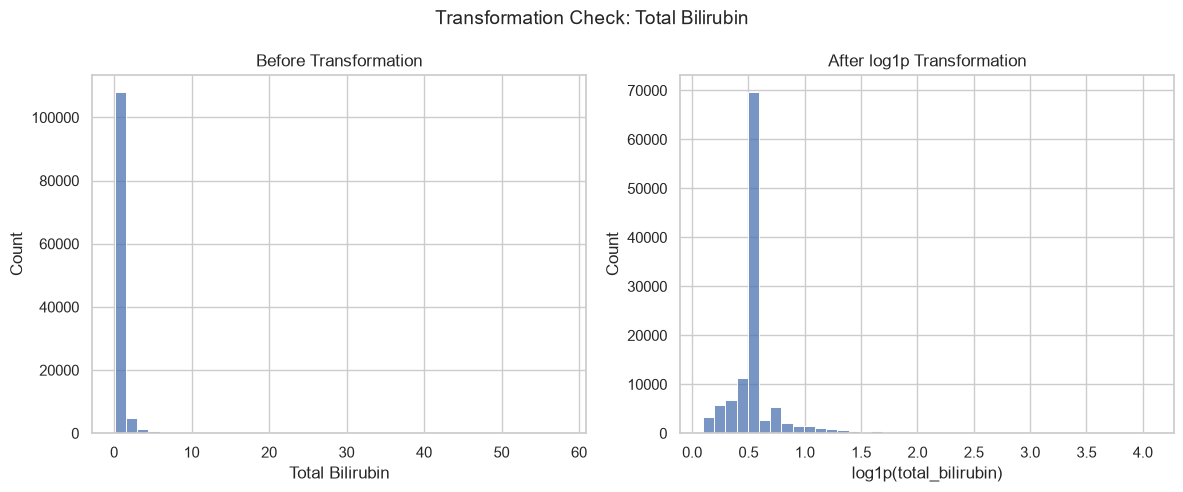

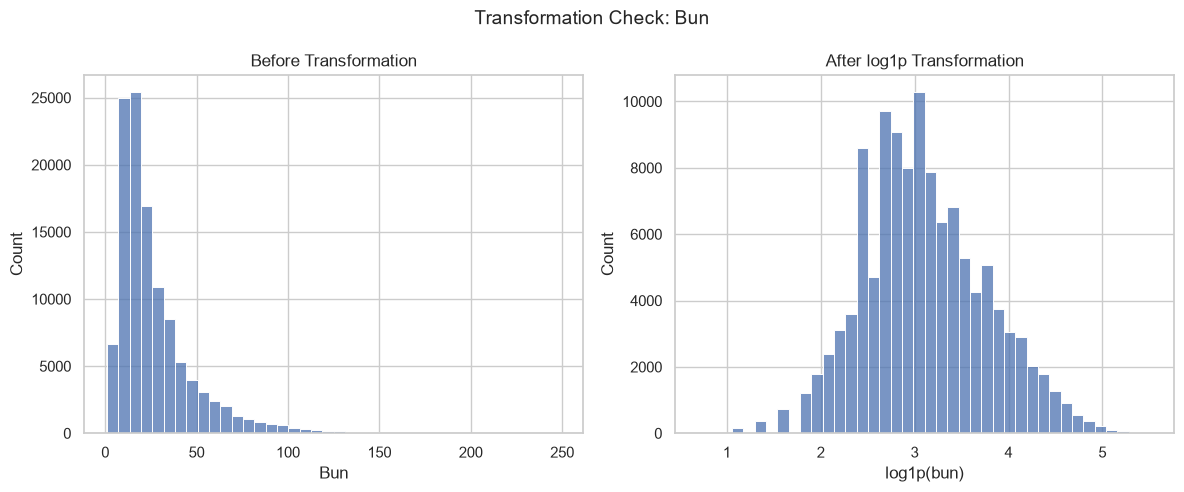

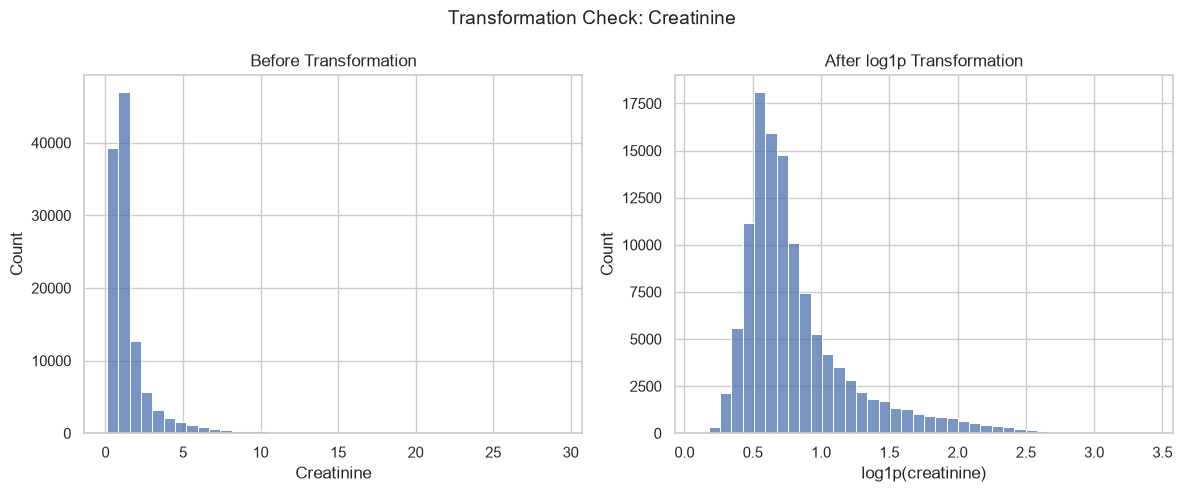

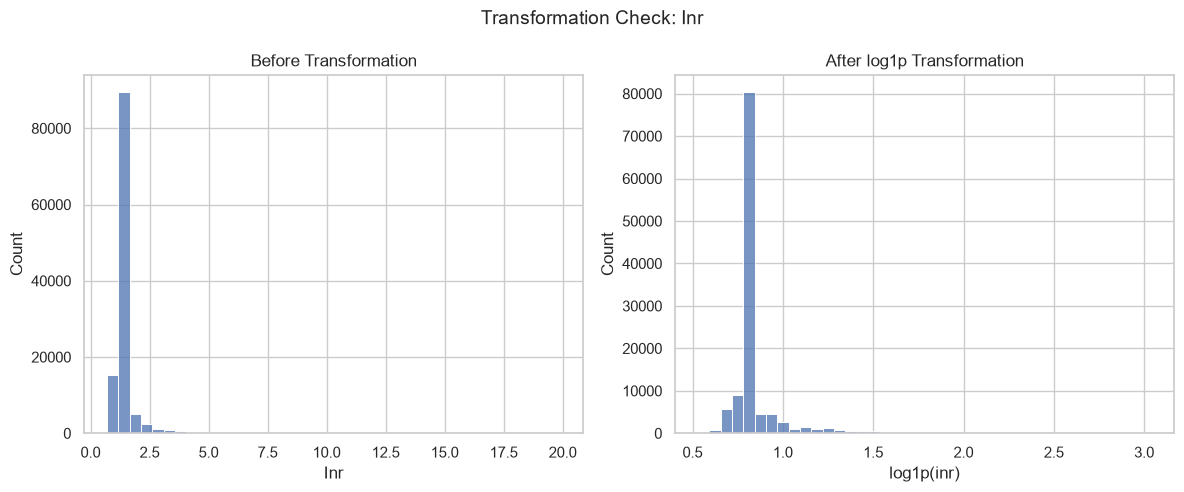

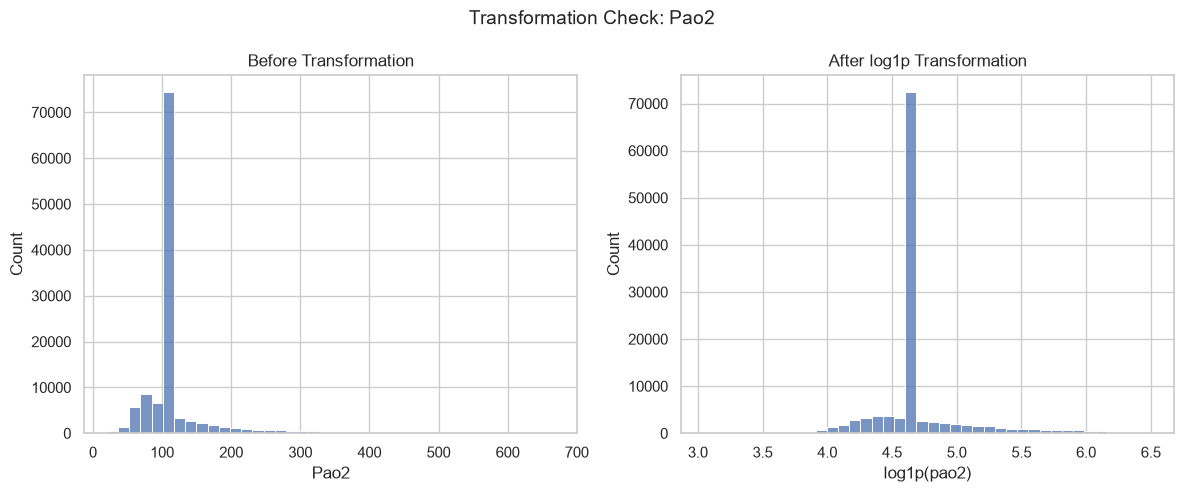

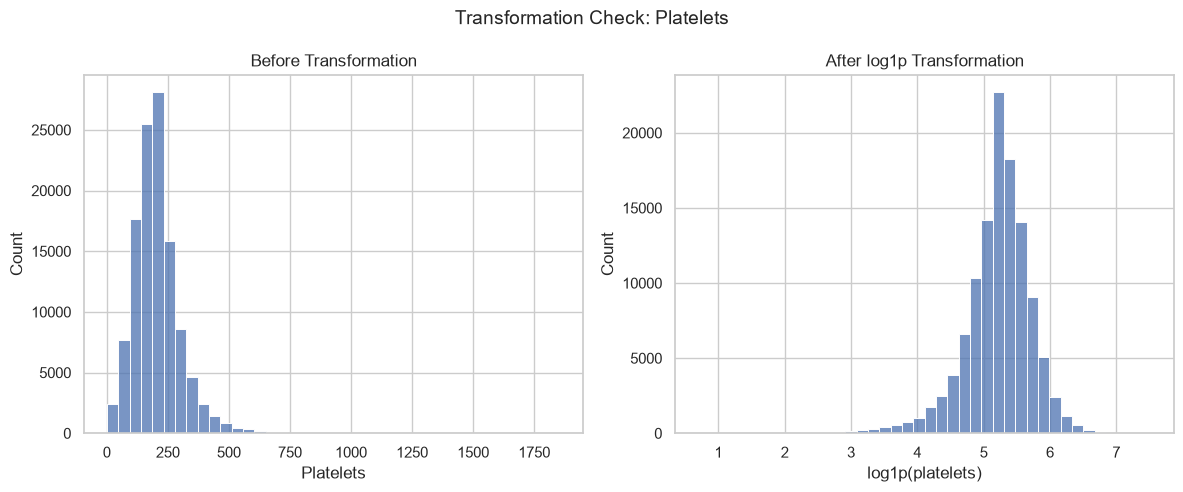

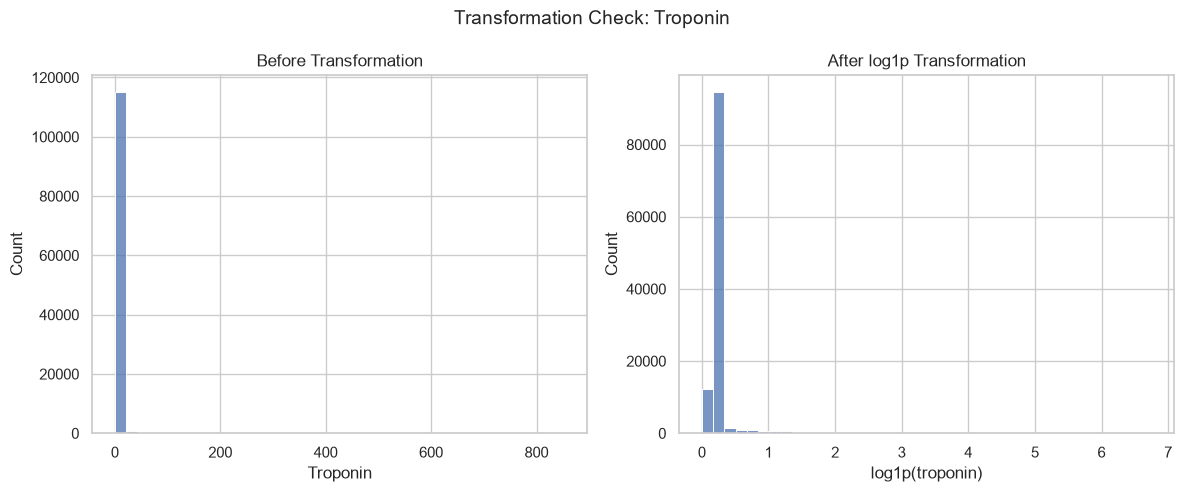

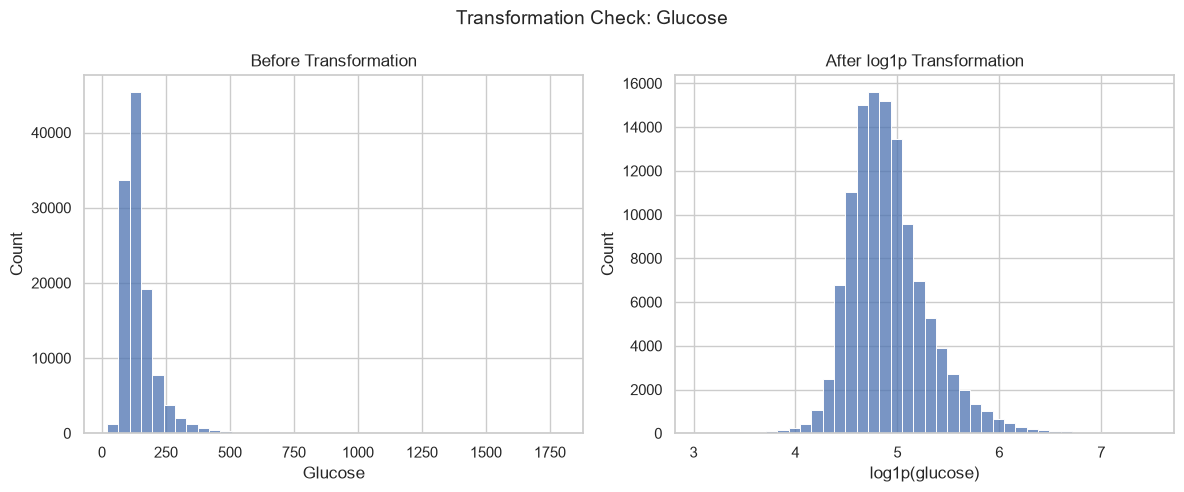

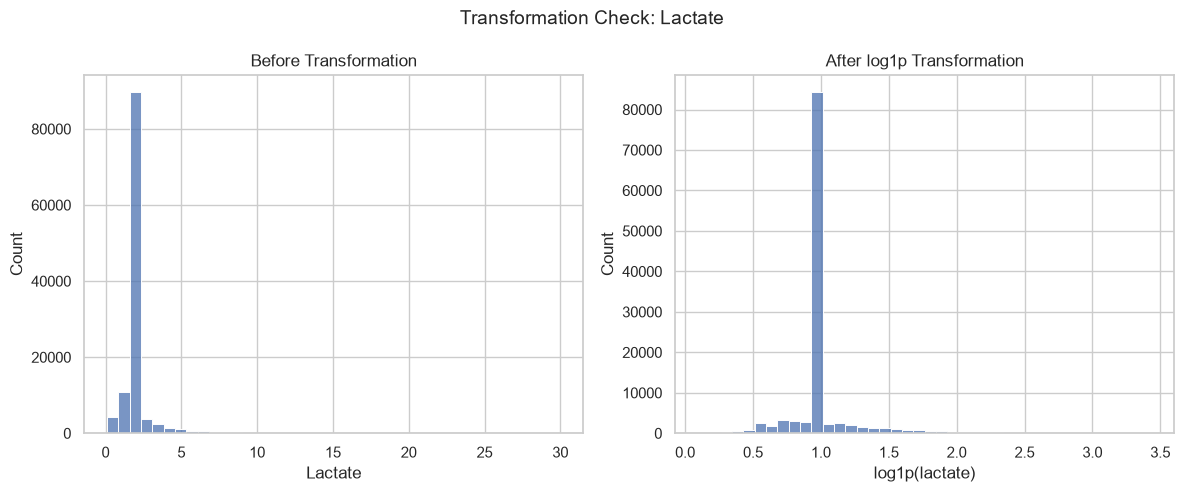

,variable,skewness_before,transformation,skewness_after,absolute_skewness_improvement
12,crp,36.357819,log1p,4.723611,31.634208
21,troponin,26.094809,log1p,5.591765,20.503044
14,alt,15.793933,log1p,2.689772,13.104161
13,ast,14.349530,log1p,2.660031,11.689499
15,total_bilirubin,12.138796,log1p,4.154329,7.984467
11,esr,11.248185,log1p,-6.819154,4.429032
10,band_count,9.833644,log1p,-0.674298,9.159346
18,inr,7.943220,log1p,4.179272,3.763948
27,lactate,6.654553,log1p,2.750375,3.904178
9,wbc,4.799927,log1p,-0.239613,4.560314


In [47]:
transformed_dataset = (
    analytic_dataset.copy()
)


transformation_rows = []


for feature in FEATURES:

    original_values = (
        analytic_dataset[feature]
        .astype(float)
    )


    skewness_before = (
        original_values.skew()
    )


    selected_transformation = "none"

    skewness_after = (
        skewness_before
    )


    # A log1p transformation is considered only when:
    # 1. The variable is not binary.
    # 2. All values are non-negative.
    # 3. The variable is right-skewed.
    can_use_log1p = (
        feature != "sex_female"
        and original_values.min() >= 0
        and skewness_before > SKEWNESS_THRESHOLD
    )


    if can_use_log1p:

        log_transformed_values = np.log1p(
            original_values
        )


        transformed_skewness = (
            log_transformed_values.skew()
        )


        # Keep the transformation only when it improves skewness.
        if (
            abs(transformed_skewness)
            < abs(skewness_before)
        ):

            transformed_dataset[
                feature
            ] = log_transformed_values


            selected_transformation = "log1p"

            skewness_after = (
                transformed_skewness
            )


            # Plot the original and transformed distributions separately
            figure, axes = plt.subplots(
                1,
                2,
                figsize=(
                    12,
                    5,
                ),
            )


            sns.histplot(
                original_values,
                bins=40,
                ax=axes[0],
            )

            axes[0].set_title(
                "Before Transformation"
            )

            axes[0].set_xlabel(
                feature.replace(
                    "_",
                    " ",
                ).title()
            )


            sns.histplot(
                log_transformed_values,
                bins=40,
                ax=axes[1],
            )

            axes[1].set_title(
                "After log1p Transformation"
            )

            axes[1].set_xlabel(
                f"log1p({feature})"
            )


            figure.suptitle(
                (
                    "Transformation Check: "
                    f"{feature.replace('_', ' ').title()}"
                ),
                fontsize=14,
            )


            figure.tight_layout()


            figure.savefig(
                TRANSFORMATION_DIR
                / f"{feature}_transformation.png",
                dpi=300,
                bbox_inches="tight",
            )


            plt.show()


    transformation_rows.append(
        {
            "variable": feature,
            "skewness_before": skewness_before,
            "transformation": selected_transformation,
            "skewness_after": skewness_after,
            "absolute_skewness_improvement": (
                abs(skewness_before)
                - abs(skewness_after)
            ),
        }
    )


transformation_summary = pd.DataFrame(
    transformation_rows
)


transformation_summary.to_csv(
    RESULTS_DIR / "transformation_summary.csv",
    index=False,
)


transformation_summary.sort_values(
    "skewness_before",
    ascending=False,
)

#### Explanation :
The notebook does not automatically transform every skewed variable.

A `log1p` transformation is retained only when it reduces the absolute skewness. This prevents transformations that make a distribution worse.

### Save the Transformed Analytic Dataset

In [48]:
transformed_dataset = transformed_dataset[
    [
        ID_COLUMN,
        *FEATURES,
    ]
]


transformed_dataset.to_csv(
    TRANSFORMED_DATASET_PATH,
    index=False,
)


descriptive_statistics_after_transformation = (
    create_descriptive_statistics(
        transformed_dataset,
        FEATURES,
    )
)


descriptive_statistics_after_transformation.to_csv(
    RESULTS_DIR
    / "descriptive_statistics_after_transformation.csv"
)


print(
    f"Transformed analytic dataset saved to:\n"
    f"{TRANSFORMED_DATASET_PATH}"
)

transformed_dataset.head()

Transformed analytic dataset saved to:
C:\Users\samsa\Documents\Capstone Project\Project\data\analytic_dataset_transformed.csv


,patientunitstayid,age,sex_female,elixhauser_count,heart_rate,respiratory_rate,systolic_blood_pressure,temperature,oxygen_saturation,gcs,wbc,band_count,esr,crp,ast,alt,total_bilirubin,bun,creatinine,inr,pao2,platelets,troponin,glucose,sodium,hemoglobin,chloride,bicarbonate,lactate,albumin
0,141168,70.0,1.0,1.609438,125.052830,2.996152,108.500000,37.119459,86.741935,14.0,2.379546,2.174752,3.465736,2.312535,4.094345,3.713572,1.280934,3.295837,1.081805,0.993252,4.644391,5.347108,0.173953,4.882802,139.0,13.0,102.0,26.0,0.993252,3.1
1,141194,68.0,0.0,0.693147,86.860627,3.186091,88.896552,37.119459,98.589474,15.0,2.714695,2.174752,3.465736,2.312535,3.218876,3.044522,0.336472,3.465736,1.255616,0.832909,4.644391,5.455321,0.173953,5.111988,135.0,8.9,105.0,19.0,0.832909,2.3
2,141196,71.0,0.0,0.693147,82.305147,3.223458,131.285714,37.119459,95.509434,15.0,3.303217,2.174752,3.465736,2.312535,2.772589,2.944439,0.262364,2.833213,0.587787,0.832909,4.262680,6.118097,0.173953,4.976734,135.0,10.3,97.0,30.0,0.993252,2.5
3,141203,77.0,1.0,1.098612,91.538194,2.981289,103.530769,37.119459,98.102473,14.0,2.617396,2.174752,3.465736,2.312535,3.135494,2.772589,0.405465,2.302585,0.444686,0.832909,3.951244,6.324359,0.019803,4.983607,145.0,11.3,107.0,25.0,1.504077,1.6
4,141227,82.0,0.0,0.000000,108.975610,3.565155,114.753846,37.119459,94.737037,10.0,3.777348,2.397895,3.465736,2.312535,3.496508,3.332205,0.494696,3.433987,0.955511,0.832909,4.189655,5.293305,0.405465,4.983607,133.0,8.2,101.0,16.0,0.875469,2.9


#### Expalantion :
This dataset contains the accepted transformed values but has not yet been standardized. 

It allows you to inspect exactly what values enter `StandardScaler`.

### Standardize the $29$ Clustering Variables

In [49]:
scaler = StandardScaler()


standardized_values = scaler.fit_transform(
    transformed_dataset[FEATURES]
)


clustering_matrix_standardized = pd.DataFrame(
    standardized_values,
    columns=FEATURES,
    index=transformed_dataset.index,
)


print(
    f"Standardized matrix shape: "
    f"{clustering_matrix_standardized.shape}"
)

clustering_matrix_standardized.head()

Standardized matrix shape: (116573, 29)


,age,sex_female,elixhauser_count,heart_rate,respiratory_rate,systolic_blood_pressure,temperature,oxygen_saturation,gcs,wbc,band_count,esr,crp,ast,alt,total_bilirubin,bun,creatinine,inr,pao2,platelets,troponin,glucose,sodium,hemoglobin,chloride,bicarbonate,lactate,albumin
0,0.368812,1.097166,1.936710,2.409401,-0.057298,-0.591398,0.050328,-4.643280,0.431245,-0.181052,0.017823,0.017606,-0.000881,0.580762,0.378509,2.218605,0.294782,0.615982,0.734664,-0.123302,0.270812,-0.206270,-0.080084,0.124655,0.897599,-0.344348,0.339436,-0.120889,0.450996
1,0.247393,-0.911439,0.132699,0.077830,0.842715,-1.627261,0.050328,0.786594,0.720775,0.506748,0.017823,0.017606,-0.000881,-0.529803,-0.532930,-0.683523,0.550692,1.033472,-0.186884,-0.123302,0.480637,-0.206270,0.505272,-0.622517,-0.899290,0.100058,-0.905237,-0.712126,-1.178083
2,0.429522,-0.911439,0.132699,-0.200275,1.019778,0.612619,0.050328,-0.625027,0.720775,1.714527,0.017823,0.017606,-0.000881,-1.095936,-0.669273,-0.911241,-0.402046,-0.570639,-0.186884,-1.185516,1.765750,-0.206270,0.159825,-0.622517,-0.285718,-1.085023,1.050678,-0.120889,-0.770814
3,0.793779,1.097166,0.930986,0.363388,-0.127728,-0.853977,0.050328,0.563396,0.431245,0.307069,0.017823,0.017606,-0.000881,-0.635576,-0.903382,-0.471523,-1.201306,-0.914364,-0.186884,-2.052172,2.165688,-0.487723,0.177378,1.245412,0.152547,0.396328,0.161625,1.762697,-2.603528
4,1.097327,-0.911439,-1.231982,1.427913,2.638893,-0.260939,0.050328,-0.979026,-0.726872,2.687550,0.803390,0.017606,-0.000881,-0.177617,-0.141024,-0.197335,0.502871,0.312627,-0.186884,-1.388729,0.166489,0.216432,0.177378,-0.996102,-1.206076,-0.492483,-1.438668,-0.555195,0.043726


#### Explanation :
`StandardScaler` gives every feature an approximate mean of $0$ and standard deviation of $1$.

This prevents variables with large numerical ranges from dominating the Euclidean distance used by KMeans.

### Check the Standardization Results

In [50]:
standardization_check = pd.DataFrame(
    {
        "variable": FEATURES,

        "mean_after_scaling": (
            clustering_matrix_standardized
            .mean()
            .values
        ),

        "standard_deviation_after_scaling": (
            clustering_matrix_standardized
            .std(ddof=0)
            .values
        ),

        "minimum_after_scaling": (
            clustering_matrix_standardized
            .min()
            .values
        ),

        "maximum_after_scaling": (
            clustering_matrix_standardized
            .max()
            .values
        ),
    }
)


standardization_check.to_csv(
    RESULTS_DIR / "standardization_check.csv",
    index=False,
)


standardization_check

,variable,mean_after_scaling,standard_deviation_after_scaling,minimum_after_scaling,maximum_after_scaling
0,age,7.801933e-17,1.0,-2.788085,1.583003
1,sex_female,2.291818e-17,1.0,-0.911439,1.097166
2,elixhauser_count,0.000000e+00,1.0,-1.231982,3.660349
3,heart_rate,-1.638406e-16,1.0,-3.759708,5.316147
4,respiratory_rate,1.267814e-15,1.0,-6.628170,6.568457
5,systolic_blood_pressure,-2.282065e-16,1.0,-4.422362,6.779904
6,temperature,1.026588e-14,1.0,-28.612535,17.399783
7,oxygen_saturation,-1.563312e-15,1.0,-19.191004,1.433056
8,gcs,-2.262560e-16,1.0,-2.753577,0.720775
9,wbc,7.304559e-16,1.0,-4.868813,5.799662


#### Explanation :

The mean of each standardized variable should be very close to $0$ and the population standard deviation should be very close to $1$.

### Save the StandardScaler Parameters

In [51]:
standard_scaler_parameters = pd.DataFrame(
    {
        "variable": FEATURES,
        "scaler_mean": scaler.mean_,
        "scaler_scale": scaler.scale_,
    }
)


standard_scaler_parameters.to_csv(
    RESULTS_DIR / "standard_scaler_parameters.csv",
    index=False,
)


standard_scaler_parameters

,variable,scaler_mean,scaler_scale
0,age,63.924974,16.471870
1,sex_female,0.453767,0.497858
2,elixhauser_count,0.625747,0.507919
3,heart_rate,85.585738,16.380458
4,respiratory_rate,3.008244,0.211040
5,systolic_blood_pressure,119.692056,18.924743
6,temperature,37.099935,0.387940
7,oxygen_saturation,96.873190,2.181918
8,gcs,12.510530,3.453882
9,wbc,2.467768,0.487276


### Explanation :
These parameters make the preprocessing reproducible. They can also be used to apply the same scaling to an external validation dataset.

### Save the Standardized Clustering Matrix

In [52]:
clustering_matrix_standardized.to_csv(
    STANDARDIZED_MATRIX_PATH,
    index=False,
)


print(
    f"Standardized clustering matrix saved to:\n"
    f"{STANDARDIZED_MATRIX_PATH}"
)

Standardized clustering matrix saved to:
C:\Users\samsa\Documents\Capstone Project\Project\data\clustering_matrix_standardized.csv


#### Explanation :
It contains exactly $29$ standardized variables and does not contain the ICU identifier or any outcome variables.

### Save the Matching ICU Stay Identifiers

In [53]:
clustering_row_ids = analytic_dataset[
    [
        ID_COLUMN,
    ]
].copy()


clustering_row_ids.to_csv(
    ROW_IDS_PATH,
    index=False,
)


print(
    f"Matching ICU stay identifiers saved to:\n"
    f"{ROW_IDS_PATH}"
)

clustering_row_ids.head()

Matching ICU stay identifiers saved to:
C:\Users\samsa\Documents\Capstone Project\Project\results\analytic_dataset\clustering_row_ids.csv


,patientunitstayid
0,141168
1,141194
2,141196
3,141203
4,141227


#### Explanation :
The standardized matrix does not contain identifiers. This separate file preserves the row-to-ICU-stay relationship.
For example :
```
clustering_matrix_standardized.csv row 1
matches
clustering_row_ids.csv row 1
```

### Calculate Laboratory Availability

In [54]:
laboratory_availability = pd.DataFrame(
    {
        "variable": LAB_VARIABLES,

        "available_icu_stays": [
            laboratory_features[
                feature
            ].notna().sum()
            for feature in LAB_VARIABLES
        ],
    }
)


laboratory_availability[
    "available_percent_of_initial_cohort"
] = (
    laboratory_availability[
        "available_icu_stays"
    ]
    / len(cohort)
    * 100
)


laboratory_availability = (
    laboratory_availability
    .sort_values(
        "available_percent_of_initial_cohort",
        ascending=False,
    )
)


laboratory_availability.to_csv(
    RESULTS_DIR / "laboratory_availability.csv",
    index=False,
)


laboratory_availability

,variable,available_icu_stays,available_percent_of_initial_cohort
17,bicarbonate,121445,91.579884
14,sodium,121263,91.442641
8,creatinine,121207,91.400412
7,bun,120795,91.089729
16,chloride,120600,90.942682
13,glucose,120520,90.882355
15,hemoglobin,118164,89.105730
0,wbc,117040,88.258138
11,platelets,115933,87.423366
19,albumin,60822,45.864973


#### Explanation :
This table shows how frequently each laboratory variable was available before merging and imputation.

### Run Final Intergrity Checks

In [55]:
# ---------------------------------------------------------
# Identifier checks
# ---------------------------------------------------------
assert analytic_dataset[
    ID_COLUMN
].notna().all(), (
    "The analytic dataset contains missing ICU identifiers."
)


assert analytic_dataset[
    ID_COLUMN
].is_unique, (
    "The analytic dataset contains duplicate ICU identifiers."
)


# ---------------------------------------------------------
# Feature checks
# ---------------------------------------------------------
assert len(FEATURES) == 29, (
    "The feature list must contain exactly 29 variables."
)


assert list(
    clustering_matrix_standardized.columns
) == FEATURES, (
    "The standardized matrix columns do not match the feature list."
)


# ---------------------------------------------------------
# Row-alignment checks
# ---------------------------------------------------------
assert len(analytic_dataset) == len(
    transformed_dataset
), (
    "The analytic and transformed datasets have different row counts."
)


assert len(analytic_dataset) == len(
    clustering_matrix_standardized
), (
    "The analytic and standardized datasets have different row counts."
)


assert len(analytic_dataset) == len(
    clustering_row_ids
), (
    "The ICU identifier file has a different row count."
)


assert analytic_dataset[
    ID_COLUMN
].reset_index(
    drop=True
).equals(
    clustering_row_ids[
        ID_COLUMN
    ].reset_index(
        drop=True
    )
), (
    "The ICU identifier order does not match the clustering matrix."
)


# ---------------------------------------------------------
# Missing and infinite-value checks
# ---------------------------------------------------------
assert not analytic_dataset[
    FEATURES
].isna().any().any(), (
    "The analytic dataset contains missing feature values."
)


assert not transformed_dataset[
    FEATURES
].isna().any().any(), (
    "The transformed dataset contains missing values."
)


assert not clustering_matrix_standardized.isna().any().any(), (
    "The standardized matrix contains missing values."
)


assert np.isfinite(
    clustering_matrix_standardized.to_numpy()
).all(), (
    "The standardized matrix contains infinite values."
)


print(
    "All final integrity checks passed successfully."
)

All final integrity checks passed successfully.


#### Explanation :
These checks confirm :
- One row per ICU stay
- Exactly $29$ clustering variables
- No missing values
- No infinite values
- Correct row alignment between the standardized matrix and ICU identifiers.

### Display the Summary

In [56]:
print("=" * 100)
print("ANALYTIC DATASET COMPLETED")
print("=" * 100)

print(
    f"Final number of ICU stays       : "
    f"{len(analytic_dataset):,}"
)

print(
    f"Number of clustering variables  : "
    f"{len(FEATURES)}"
)

print(
    f"Analytic dataset shape           : "
    f"{analytic_dataset.shape}"
)

print(
    f"Standardized matrix shape        : "
    f"{clustering_matrix_standardized.shape}"
)

print("-" * 90)

print("FINAL DATASETS FOR UPCOMING TASKS")

print(
    f"1. Analytic dataset:\n"
    f"   {ANALYTIC_DATASET_PATH}"
)

print(
    f"2. Transformed dataset:\n"
    f"   {TRANSFORMED_DATASET_PATH}"
)

print(
    f"3. Standardized clustering matrix:\n"
    f"   {STANDARDIZED_MATRIX_PATH}"
)

print("-" * 90)

print(
    f"Supporting CSV results:\n"
    f"{RESULTS_DIR}"
)

print(
    f"Task 5 plots:\n"
    f"{PLOTS_DIR}"
)

print("=" * 90)

ANALYTIC DATASET COMPLETED
Final number of ICU stays       : 116,573
Number of clustering variables  : 29
Analytic dataset shape           : (116573, 30)
Standardized matrix shape        : (116573, 29)
------------------------------------------------------------------------------------------
FINAL DATASETS FOR UPCOMING TASKS
1. Analytic dataset:
   C:\Users\samsa\Documents\Capstone Project\Project\data\analytic_dataset.csv
2. Transformed dataset:
   C:\Users\samsa\Documents\Capstone Project\Project\data\analytic_dataset_transformed.csv
3. Standardized clustering matrix:
   C:\Users\samsa\Documents\Capstone Project\Project\data\clustering_matrix_standardized.csv
------------------------------------------------------------------------------------------
Supporting CSV results:
C:\Users\samsa\Documents\Capstone Project\Project\results\analytic_dataset
Task 5 plots:
C:\Users\samsa\Documents\Capstone Project\Project\plots\analytic_dataset


#### Explanation :
This cell confirms where all outputs are saved.

### Display Samples from the Final Datasets

In [57]:
print("ANALYTIC DATASET")
display(
    analytic_dataset.head()
)


print("\nTRANSFORMED ANALYTIC DATASET")
display(
    transformed_dataset.head()
)


print("\nSTANDARDIZED CLUSTERING MATRIX")
display(
    clustering_matrix_standardized.head()
)


print("\nCOHORT EXCLUSION SUMMARY")
display(
    cohort_exclusion_summary
)


print("\nMISSINGNESS SUMMARY")
display(
    missingness_summary
)

ANALYTIC DATASET


,patientunitstayid,age,sex_female,elixhauser_count,heart_rate,respiratory_rate,systolic_blood_pressure,temperature,oxygen_saturation,gcs,wbc,band_count,esr,crp,ast,alt,total_bilirubin,bun,creatinine,inr,pao2,platelets,troponin,glucose,sodium,hemoglobin,chloride,bicarbonate,lactate,albumin
0,141168,70.0,1.0,4.0,125.052830,19.008403,108.500000,37.119459,86.741935,14.0,9.8,7.8,31.0,9.1,59.0,40.0,2.60,26.0,1.95,1.7,103.0,209.0,0.19,131.0,139.0,13.0,102.0,26.0,1.7,3.1
1,141194,68.0,0.0,1.0,86.860627,23.193662,88.896552,37.119459,98.589474,15.0,14.1,7.8,31.0,9.1,24.0,20.0,0.40,31.0,2.51,1.3,103.0,233.0,0.19,165.0,135.0,8.9,105.0,19.0,1.3,2.3
2,141196,71.0,0.0,1.0,82.305147,24.114815,131.285714,37.119459,95.509434,15.0,26.2,7.8,31.0,9.1,15.0,18.0,0.30,16.0,0.80,1.3,70.0,453.0,0.19,144.0,135.0,10.3,97.0,30.0,1.7,2.5
3,141203,77.0,1.0,2.0,91.538194,18.713208,103.530769,37.119459,98.102473,14.0,12.7,7.8,31.0,9.1,22.0,15.0,0.50,9.0,0.56,1.3,51.0,557.0,0.02,145.0,145.0,11.3,107.0,25.0,3.5,1.6
4,141227,82.0,0.0,0.0,108.975610,34.344948,114.753846,37.119459,94.737037,10.0,42.7,10.0,31.0,9.1,32.0,27.0,0.64,30.0,1.60,1.3,65.0,198.0,0.50,145.0,133.0,8.2,101.0,16.0,1.4,2.9



TRANSFORMED ANALYTIC DATASET


,patientunitstayid,age,sex_female,elixhauser_count,heart_rate,respiratory_rate,systolic_blood_pressure,temperature,oxygen_saturation,gcs,wbc,band_count,esr,crp,ast,alt,total_bilirubin,bun,creatinine,inr,pao2,platelets,troponin,glucose,sodium,hemoglobin,chloride,bicarbonate,lactate,albumin
0,141168,70.0,1.0,1.609438,125.052830,2.996152,108.500000,37.119459,86.741935,14.0,2.379546,2.174752,3.465736,2.312535,4.094345,3.713572,1.280934,3.295837,1.081805,0.993252,4.644391,5.347108,0.173953,4.882802,139.0,13.0,102.0,26.0,0.993252,3.1
1,141194,68.0,0.0,0.693147,86.860627,3.186091,88.896552,37.119459,98.589474,15.0,2.714695,2.174752,3.465736,2.312535,3.218876,3.044522,0.336472,3.465736,1.255616,0.832909,4.644391,5.455321,0.173953,5.111988,135.0,8.9,105.0,19.0,0.832909,2.3
2,141196,71.0,0.0,0.693147,82.305147,3.223458,131.285714,37.119459,95.509434,15.0,3.303217,2.174752,3.465736,2.312535,2.772589,2.944439,0.262364,2.833213,0.587787,0.832909,4.262680,6.118097,0.173953,4.976734,135.0,10.3,97.0,30.0,0.993252,2.5
3,141203,77.0,1.0,1.098612,91.538194,2.981289,103.530769,37.119459,98.102473,14.0,2.617396,2.174752,3.465736,2.312535,3.135494,2.772589,0.405465,2.302585,0.444686,0.832909,3.951244,6.324359,0.019803,4.983607,145.0,11.3,107.0,25.0,1.504077,1.6
4,141227,82.0,0.0,0.000000,108.975610,3.565155,114.753846,37.119459,94.737037,10.0,3.777348,2.397895,3.465736,2.312535,3.496508,3.332205,0.494696,3.433987,0.955511,0.832909,4.189655,5.293305,0.405465,4.983607,133.0,8.2,101.0,16.0,0.875469,2.9



STANDARDIZED CLUSTERING MATRIX


,age,sex_female,elixhauser_count,heart_rate,respiratory_rate,systolic_blood_pressure,temperature,oxygen_saturation,gcs,wbc,band_count,esr,crp,ast,alt,total_bilirubin,bun,creatinine,inr,pao2,platelets,troponin,glucose,sodium,hemoglobin,chloride,bicarbonate,lactate,albumin
0,0.368812,1.097166,1.936710,2.409401,-0.057298,-0.591398,0.050328,-4.643280,0.431245,-0.181052,0.017823,0.017606,-0.000881,0.580762,0.378509,2.218605,0.294782,0.615982,0.734664,-0.123302,0.270812,-0.206270,-0.080084,0.124655,0.897599,-0.344348,0.339436,-0.120889,0.450996
1,0.247393,-0.911439,0.132699,0.077830,0.842715,-1.627261,0.050328,0.786594,0.720775,0.506748,0.017823,0.017606,-0.000881,-0.529803,-0.532930,-0.683523,0.550692,1.033472,-0.186884,-0.123302,0.480637,-0.206270,0.505272,-0.622517,-0.899290,0.100058,-0.905237,-0.712126,-1.178083
2,0.429522,-0.911439,0.132699,-0.200275,1.019778,0.612619,0.050328,-0.625027,0.720775,1.714527,0.017823,0.017606,-0.000881,-1.095936,-0.669273,-0.911241,-0.402046,-0.570639,-0.186884,-1.185516,1.765750,-0.206270,0.159825,-0.622517,-0.285718,-1.085023,1.050678,-0.120889,-0.770814
3,0.793779,1.097166,0.930986,0.363388,-0.127728,-0.853977,0.050328,0.563396,0.431245,0.307069,0.017823,0.017606,-0.000881,-0.635576,-0.903382,-0.471523,-1.201306,-0.914364,-0.186884,-2.052172,2.165688,-0.487723,0.177378,1.245412,0.152547,0.396328,0.161625,1.762697,-2.603528
4,1.097327,-0.911439,-1.231982,1.427913,2.638893,-0.260939,0.050328,-0.979026,-0.726872,2.687550,0.803390,0.017606,-0.000881,-0.177617,-0.141024,-0.197335,0.502871,0.312627,-0.186884,-1.388729,0.166489,0.216432,0.177378,-0.996102,-1.206076,-0.492483,-1.438668,-0.555195,0.043726



COHORT EXCLUSION SUMMARY


,criterion,before_exclusion,excluded,after_exclusion
0,All ICU stay records in the patient table,200859,0,200859
1,Valid ICU stay identifier,200859,0,200859
2,Remove duplicate ICU stay identifiers,200859,0,200859
3,Known patient age,200859,95,200764
4,Adults aged 18 years or older,200764,530,200234
5,ICU stay lasting at least 24 hours,200234,67623,132611
6,At least 15 of 29 variables observed,132611,16038,116573



MISSINGNESS SUMMARY


,variable,available_count,missing_count,missing_percent,high_missingness_warning
0,crp,1799,114774,98.456761,True
1,esr,2310,114263,98.018409,True
2,band_count,9386,107187,91.948393,True
3,temperature,13543,103030,88.382387,True
4,troponin,24668,91905,78.839011,True
5,lactate,34625,81948,70.297582,True
6,pao2,46956,69617,59.719661,True
7,inr,47793,68780,59.001656,True
8,total_bilirubin,54662,61911,53.109211,True
9,alt,55506,61067,52.385201,True


#### Explanation :
This provides a final visual review of the datasets and summary tables